# Benchmark: Network Sweep -- TwINFER (with fan-out removal) vs. BEELINE methods

Consolidates and replaces `network_sweep_analysis.ipynb`, `evaluate_networksweep_beeline.ipynb`,
and `evaluate_networksweep_final_beeline.ipynb` into a single benchmark of the
`network_sweep_final` synthetic sweep (density / sign_ratio / center axes).

- **TwINFER** is rerun end-to-end here with the new `separate_fan_outs_from_mutual_regulation_flag`
  (added to `infer_with_twinfer`), which detects gene pairs sharing a common regulator where
  both directions are significant, and drops both edges when the pair's undirected twin-vs-random
  z-score exceeds a threshold (fan-out artifact) rather than genuine mutual regulation.
- The other 7 methods already run through BEELINE (GRNBOOST2, PIDC, PPCOR, GENIE3, SCODE,
  PEARSON, SCSGL) are loaded from their existing cached `rankedEdges.csv` outputs -- nothing
  changed for them, so no rerun is needed.
- Every method is scored three ways -- **signed + directed**, **directed + unsigned**, and
  **undirected ("neither")** -- at three metric families: threshold-free **AUPRC**, **top-k**
  (tie-aware, k = number of true edges), and **natural threshold** (each method's own hard
  include/exclude decision -- TwINFER's is whatever `infer_with_twinfer` itself decides in
  `direction_matrix`/`final_directed_edges`; for the other 7 methods a 2-component GMM fit on
  their raw edge-weight distribution stands in for a natural, data-driven cutoff).
- TwINFER's top-k additionally gets **4 nested variants**, loosest to strictest candidate pool:
  `all_edges` -> `pass_first_test` (the shuffled-null significance test) -> `not_heterogeneous`
  (z < 10, i.e. single-state-regulation pairs only) -> `fan_out_removed` (the actual new
  pipeline behavior being validated).
- Every score is rendered **only as a heatmap** (rows = method, columns = dataset) -- no other
  plot types are ported over from the source notebooks.


## Part 0 -- Imports and paths

In [1]:
import os
import re
import glob
import json
import warnings
from pathlib import Path
from itertools import permutations, combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from scipy.stats import norm
from scipy.optimize import brentq
from sklearn.mixture import GaussianMixture
from sklearn.metrics import auc, precision_recall_curve

In [2]:
# Path to TwINFER code repository
path_to_simulation_data = "/home/gzu5140/Keerthana_b1042/TwINFER/simulation_data/network_sweep_final/"
path_to_ground_truth_dir = "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep_final/"

# results (analysis_data/network_sweep_final/network_inference/) so existing
# notebooks/CSVs depending on the old cache are left untouched.
path_to_twinfer_fanout_output = "/home/gzu5140/TwINFER_KA/analysis_data/synthetic_network_benchmark_13082026/twinfer_inference_final/"
os.makedirs(path_to_twinfer_fanout_output, exist_ok=True)

# BEELINE (7 methods) cached outputs -- no rerun needed, nothing changed for these.
BEELINE_INPUT_ROOT = Path("/home/gzu5140/Keerthana_b1042/TwINFER/code/Beeline/inputs/network_sweep_final")
BEELINE_OUTPUT_ROOT = Path("/home/gzu5140/TwINFER_KA/analysis_data/synthetic_network_benchmark_06082026/beeline_inference")

import twinfer
from twinfer.utils.paths import get_repo_root
from twinfer.inference.infer import infer_with_twinfer

path_to_code_repo  = get_repo_root()

## Part 1 -- Rerun TwINFER with fan-out removal

**This cell is compute-heavy**: `infer_with_twinfer` runs a 10,000-shuffle permutation
null per gene pair, across all 250 datasets in the sweep (topology x network replicate x
technical replicate). It is safe to re-run this notebook -- each dataset's result is
skipped if its output JSON already exists in `path_to_twinfer_fanout_output`.

`z_score_threshold_two_states` is set to **8** here (rather than the `12` used by the
original `infer_network_simulation_network_sweep.py` script that produced the old cache),
to match the "not heterogeneous (z < 10)" top-k variant requested below --
`gene_lists.single_state_regulation` in each result JSON then directly reflects that cutoff.
`fan_out_z_score_threshold` is left at the function's own default (8).

Set `LIMIT_TASKS_FOR_TESTING` to a small int (e.g. 5) for a quick smoke test; `None` runs
the full 250-dataset sweep.


In [3]:
class NumpyEncoder(json.JSONEncoder):
    """JSON encoder for numpy scalar/array types infer_with_twinfer's result dict contains."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


def make_json_safe(obj):
    """Recursively converts infer_with_twinfer's result dict (DataFrames, sets, tuple-keyed
    dicts) into a JSON-serializable structure."""
    if isinstance(obj, pd.DataFrame):
        return {
            "__type__": "DataFrame",
            "index": [str(i) for i in obj.index.tolist()],
            "columns": [str(c) for c in obj.columns.tolist()],
            "data": obj.values.tolist(),
        }
    if isinstance(obj, pd.Series):
        return {"__type__": "Series", "index": [str(i) for i in obj.index.tolist()], "data": obj.values.tolist()}
    if isinstance(obj, dict):
        return {
            ("__".join(map(str, k)) if isinstance(k, tuple) else str(k)): make_json_safe(v)
            for k, v in obj.items()
        }
    if isinstance(obj, (set, frozenset)):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def extract_run_id(filename):
    """Extracts '{config_index}_{replicate}' from '..._{config_index}_{replicate}_{8hex}.csv'."""
    fname = os.path.basename(filename)
    match = re.search(r'_(\d+_\d+)_[0-9a-fA-F]{8}\.csv$', fname)
    return match.group(1) if match else None


def run_twinfer_with_fanout(path_to_simulation_file, sim_type, rep_id, base_config, t1, t2, output_path):
    """
    Runs infer_with_twinfer with separate_fan_outs_from_mutual_regulation_flag=True and
    saves the full result dict to JSON, same convention as the original
    infer_network_simulation_network_sweep.py's build_simulation_record, plus the two new
    fan-out kwargs.
    """
    analysis_key = f"{sim_type}_rep_{rep_id}"
    f_result_path = os.path.join(output_path, f"{analysis_key}_all_results.json")
    if os.path.exists(f_result_path):
        return f_result_path  # skip -- already computed

    results = infer_with_twinfer(
        path_to_simulation_file,
        merge_to_multiple_states=False,
        base_config=base_config,
        t1=t1,
        t2=t2,
        check_for_steady_state=False,
        show_scrambled_distribution_gene_correlation=False,
        plot_correlation_matrices_as_heatmap=False,
        return_gene_corr_thresholds=False,
        match_sim_details=False,
        seed=101010,
        n_cores=15,
        use_scramble = False,
        merge_time_points=False,
        z_score_threshold_two_states=4.501,
        infer_direction_for_which_edges="all-edges",
        ranked_list=True,
        separate_fan_outs_from_mutual_regulation_flag=True,
        fan_out_z_score_threshold=3.2,
        use_scramble_cross_correlation=False
    )

    n_genes = None
    for v in results.values():
        if isinstance(v, pd.DataFrame):
            n_genes = v.shape[0]
            break
    gene_names = [f"g{i+1}" for i in range(n_genes)] if n_genes is not None else None

    record = {
        "sim_type": sim_type, "rep_id": rep_id, "analysis_key": analysis_key,
        "gene_names": gene_names, "n_genes": n_genes,
        **make_json_safe(results),
    }
    os.makedirs(output_path, exist_ok=True)
    with open(f_result_path, "w") as f:
        json.dump(record, f, cls=NumpyEncoder, indent=2)
    return f_result_path

In [4]:
%%capture
# Same base_config as infer_network_simulation_network_sweep.py -- the connectivity
# matrix here is only used to read off n_genes (all sweep networks are 6-gene), so it
# doesn't need to match each variant's true topology; match_sim_details=False below
# skips the assertions that would otherwise require it to.
base_configs = {
    'n_cells': 6000,
    'simulation_time_before_division': 6000,
    'twin_simulation_time_after_division': 48,
    'twin_measurement_resolution': 1,
    "path_to_connectivity_matrix": "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep/grn_n6_e5_pos50_density_rep0.txt",
    "param_csv": "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep/parameters.csv",
    "rows_to_use": [[0] * 6],
    "output_folder": f"{path_to_code_repo}/simulation_example_output_data/",
    "log_file": f"{path_to_code_repo}/simulation_example_output_data/logs/HSC.jsonl",
    "type": "HSC_balanced",
    "combinatorial_interaction_type": "additive",
    "number_of_parallel_parameters": 1,
    "number_of_cores_per_parameter": 56,
    "log_pi_on": False,
    "ranked_list": True,
}
t1, t2 = 1, 20

pattern = os.path.join(path_to_simulation_data, "df_grn_n6_*_ncells_6000_grn_n6_*.csv")
files = sorted(glob.glob(pattern), reverse=True)
variant_re = re.compile(r"df_grn_n6_(.+?)_ncells_6000_grn_n6_")

tasks = []
for f in files:
    fname = os.path.basename(f)
    match = variant_re.search(fname)
    if not match:
        continue
    variant_full = match.group(1)
    rep_id = extract_run_id(fname)
    tasks.append((f, variant_full, rep_id))

print(f"Collected {len(tasks)} TwINFER rerun tasks.")

LIMIT_TASKS_FOR_TESTING = None  # set to a small int for a quick smoke test
if LIMIT_TASKS_FOR_TESTING is not None:
    tasks = tasks[:LIMIT_TASKS_FOR_TESTING]
    print(f"LIMIT_TASKS_FOR_TESTING set -- only running {len(tasks)} task(s).")

from tqdm.notebook import tqdm
from joblib import Parallel

class TqdmParallel(Parallel):
    def __init__(self, *args, total=None, **kwargs):
        self._total = total
        super().__init__(*args, **kwargs)

    def __call__(self, iterable):
        with tqdm(total=self._total) as self._pbar:
            return super().__call__(iterable)

    def print_progress(self):
        self._pbar.n = self.n_completed_tasks
        self._pbar.refresh()

result_paths = TqdmParallel(n_jobs=1, backend="loky", total=len(tasks))(
    delayed(run_twinfer_with_fanout)(path, sim_type, rep_id, base_configs, t1, t2, path_to_twinfer_fanout_output)
    for path, sim_type, rep_id in tasks
)
print(f"Done. {len(result_paths)} result file(s) available in {path_to_twinfer_fanout_output}")

In [5]:
print(f"Done. {len(result_paths)} result file(s) available in {path_to_twinfer_fanout_output}")

Done. 250 result file(s) available in /home/gzu5140/TwINFER_KA/analysis_data/synthetic_network_benchmark_13082026/twinfer_inference_final/


## Part 2 -- Load and score TwINFER's fan-out-rerun results

Ports the scoring machinery from `network_sweep_analysis.ipynb` (ground-truth matching,
hard-decision `score_directed_edges`, AUPRC, tie-aware top-k), extended with:

- `build_master_ranked_table`: the true "all_edges" universe, built directly from
  `unfiltered_direction_matrix` (raw correlation magnitude, always available and never
  mutated by fan-out removal) -- unlike the JSON's own `ranked_edge_list`, which (with
  the fan-out flag on) is missing rows for any pair the fan-out step removed.
- `reconstruct_pre_fanout_edges`: recovers TwINFER's pre-fan-out `final_directed_edges`
  (the "all-edges" significance-test result *before* fan-out separation ran) from
  `fan_out_log`, since `final_directed_edges` in the rerun JSON is already the
  *post*-fan-out set.
- `build_potential_regulation_bidirectional_pairs`: TwINFER's "first test" is
  specifically the *"all-potential-regulation"* result -- directionally significant
  **and** part of `potential_regulation` (Step 2's own gene-gene correlation threshold)
  -- not merely "significant under all-edges mode" (which tests every possible pair
  regardless of Step 2's threshold, and would silently admit pairs that were never even
  evaluated for heterogeneity). `pass_first_test = pre_fanout_edges & potential_regulation_pairs`.
- The 4 nested top-k candidate pools, each a **strict subset** of the previous:
  `all_edges` -> `pass_first_test` -> `not_heterogeneous` (`gene_lists.single_state_regulation`,
  z < 10) -> `fan_out_removed` (`not_heterogeneous` minus any pair `fan_out_log` flagged
  `"fan_out"`). Separately, the **natural-threshold** family scores TwINFER's own actual
  hard decision at two fan-out stages -- `before_fan_out` (`pre_fanout_edges`, i.e. what
  the pipeline would decide with the fan-out flag off) vs `after_fan_out`
  (`final_directed_edges` as saved, i.e. what it actually decided with the flag on) --
  giving a direct "with vs without fan-out removal" comparison independent of the top-k
  pools' extra potential_regulation/heterogeneity restriction.


## Part 2 -- Load and score TwINFER's fan-out-rerun results

Ports the scoring machinery from `network_sweep_analysis.ipynb` (ground-truth matching,
hard-decision `score_directed_edges`, AUPRC, tie-aware top-k), extended with:

- `build_master_ranked_table`: the true "all_edges" universe, built directly from
  `unfiltered_direction_matrix` (raw correlation magnitude, always available and never
  mutated by fan-out removal) -- unlike the JSON's own `ranked_edge_list`, which (with
  the fan-out flag on) is missing rows for any pair the fan-out step removed.
- `reconstruct_pre_fanout_edges`: recovers TwINFER's pre-fan-out `final_directed_edges`
  (the "all-edges" significance-test result *before* fan-out separation ran) from
  `fan_out_log`, since `final_directed_edges` in the rerun JSON is already the
  *post*-fan-out set.
- `build_potential_regulation_bidirectional_pairs`: TwINFER's "first test" is
  specifically the *"all-potential-regulation"* result -- directionally significant
  **and** part of `potential_regulation` (Step 2's own gene-gene correlation threshold)
  -- not merely "significant under all-edges mode" (which tests every possible pair
  regardless of Step 2's threshold, and would silently admit pairs that were never even
  evaluated for heterogeneity). `pass_first_test = pre_fanout_edges & potential_regulation_pairs`.
- The 4 nested top-k candidate pools, each a **strict subset** of the previous:
  `all_edges` -> `pass_first_test` -> `not_heterogeneous` (`gene_lists.single_state_regulation`,
  z < 10) -> `fan_out_removed` (`not_heterogeneous` minus any pair `fan_out_log` flagged
  `"fan_out"`). Separately, the **natural-threshold** family scores TwINFER's own actual
  hard decision at two fan-out stages -- `before_fan_out` (`pre_fanout_edges`, i.e. what
  the pipeline would decide with the fan-out flag off) vs `after_fan_out`
  (`final_directed_edges` as saved, i.e. what it actually decided with the flag on) --
  giving a direct "with vs without fan-out removal" comparison independent of the top-k
  pools' extra potential_regulation/heterogeneity restriction.


In [6]:
def reconstruct_ranked_edge_list(raw):
    """Reconstructs a gene_1/gene_2/directional_correlation table from the
    {'__type__': 'DataFrame', 'index': ..., 'columns': ..., 'data': ...} wrapper format
    used in these result JSONs.
    """
    if isinstance(raw, dict) and raw.get("__type__") == "DataFrame":
        return pd.DataFrame(raw["data"], columns=raw["columns"])
    return None


def reconstruct_matrix(raw):
    """Reconstructs a labeled DataFrame from the same wrapper format for square matrices."""
    return pd.DataFrame(raw["data"], index=raw["index"], columns=raw["columns"])


def load_ground_truth_matrix(path_to_matrix, gene_names=None):
    """Loads a connectivity matrix and labels it with gene names for lookup."""
    matrix = np.loadtxt(path_to_matrix, dtype=int, delimiter=',')
    n = matrix.shape[0]
    if gene_names is None:
        gene_names = [f"gene_{i+1}" for i in range(n)]
    return pd.DataFrame(matrix, index=gene_names, columns=gene_names)


def build_network_stem_lookup(network_dir, prefix="grn_n", suffix=".txt"):
    """Builds {topology_stem: full_ground_truth_path} by stripping prefix/suffix from
    each .txt filename in network_dir, e.g. 'grn_n6_e5_pos50_density_rep0.txt' ->
    stem 'e5_pos50_density_rep0'."""
    lookup = {}
    for f in glob.glob(os.path.join(network_dir, f"*{suffix}")):
        stem = os.path.basename(f)
        stem = re.sub(rf"^{prefix}\d+_", "", stem)
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
        lookup[stem] = f
    return lookup


def match_topology_file(json_filename, stem_lookup):
    """Finds which topology stem appears as a substring within a result JSON's filename.
    Returns (matched_file_path or None, list_of_all_matching_stems); the longest
    (most specific) match wins if more than one stem matches."""
    matches = [stem for stem in stem_lookup if stem in json_filename]
    if not matches:
        return None, []
    best = max(matches, key=len)
    return stem_lookup[best], matches


def get_correct_gene_names(results):
    """Reconstructs gene names using TwINFER's actual internal naming convention
    ('gene_1', 'gene_2', ...), ignoring results['gene_names'] if it used the old
    'g1', 'g2', ... convention that doesn't match infer_with_twinfer's internal naming.
    """
    stored = results.get("gene_names")
    if stored and all(g.startswith("gene_") for g in stored):
        return stored
    n_genes = results["n_genes"]
    return [f"gene_{i+1}" for i in range(n_genes)]


In [7]:
def precision_recall_f1(selected_edges, true_edges):
    """Precision/recall/F1 of a selected edge set against a true edge set (both as sets
    of directed tuples, signed triples, or undirected frozensets -- generic over all
    three variant representations)."""
    if not selected_edges:
        return 0.0, 0.0, 0.0
    tp = len(selected_edges & true_edges)
    precision = tp / len(selected_edges)
    recall = tp / len(true_edges) if true_edges else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

def build_directed_true_edges(ground_truth_matrix, gene_names):
    """Set of directed (gi, gj) pairs with a nonzero (sign-blind) ground-truth edge."""
    return {
        (gi, gj)
        for gi in gene_names for gj in gene_names
        if gi != gj and ground_truth_matrix.loc[gi, gj] != 0
    }


def build_directed_true_edges_signed(ground_truth_matrix, gene_names):
    """Set of directed (gi, gj, sign) triples for every real ground-truth edge."""
    true_edges = set()
    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue
            val = ground_truth_matrix.loc[gi, gj]
            if val != 0:
                true_edges.add((gi, gj, int(np.sign(val))))
    return true_edges


def build_true_pairs_undirected(ground_truth_matrix, gene_names):
    """Set of undirected (frozenset) gene pairs with a real edge in either direction --
    the true-edge side of the undirected/unsigned ('neither') variant."""
    true_pairs = set()
    for gi, gj in combinations(gene_names, 2):
        if ground_truth_matrix.loc[gi, gj] != 0 or ground_truth_matrix.loc[gj, gi] != 0:
            true_pairs.add(frozenset((gi, gj)))
    return true_pairs


In [8]:
def find_confounded_pairs(ground_truth_matrix, gene_names):
    """
    Identifies gene pairs with no direct edge between them but sharing at least one
    common regulator (fan-out / feed-forward fork: gk->gi and gk->gj). Such pairs are
    expected to show correlation from shared upstream regulation even though they are
    not truly regulatory edges, so they are scored as an expected multi-state case
    rather than a straightforward false positive/negative.

    Pairs with a real direct edge between them -- including true mutual (bidirectional)
    regulation -- are excluded, since genuine regulation should be scored normally, not
    treated as a confound.
    """
    confounded_pairs = set()
    n = len(gene_names)
    for idx_i in range(n):
        for idx_j in range(idx_i + 1, n):
            gi, gj = gene_names[idx_i], gene_names[idx_j]
            if ground_truth_matrix.loc[gi, gj] != 0 and ground_truth_matrix.loc[gj, gi] != 0:
                continue  # real direct edge (incl. mutual) -- not a confound case
            shared_regulator = any(
                ground_truth_matrix.loc[gk, gi] != 0 and ground_truth_matrix.loc[gk, gj] != 0
                for gk in gene_names if gk not in (gi, gj)
            )
            if shared_regulator:
                confounded_pairs.add(frozenset([gi, gj]))
    return confounded_pairs


def score_directed_edges(ground_truth_matrix, gene_names, final_directed_edges,
                          multiple_states, direction_matrix, wrong_sign_counts_as=("FP", "FN")):
    """
    TwINFER's natural-threshold precision/recall/F1 against the ground truth, at two
    strictness levels computed side by side: sign-blind (directed+unsigned) and directed
    AND signed (strictest). Confounded (fan-out-in-the-ground-truth) pairs are scored
    leniently as TN if flagged multi-state, matching find_confounded_pairs.
    """
    predicted_edges = set(tuple(e) for e in final_directed_edges)
    confounded_pairs = find_confounded_pairs(ground_truth_matrix, gene_names)
    scored_confounded = set()

    TP = FP = FN = TN = 0
    TP_signed = FP_signed = FN_signed = WRONG_SIGN = 0
    confounded_correct = 0

    def _sign_match(a, b):
        gt_sign = int(np.sign(ground_truth_matrix.loc[a, b]))
        pred_sign_val = direction_matrix.loc[a, b]
        pred_sign = int(np.sign(pred_sign_val)) if pred_sign_val != 0 else 0
        return pred_sign == gt_sign

    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue

            pair_fs = frozenset([gi, gj])

            # if pair_fs in confounded_pairs:
            #     continue
                # if pair_fs in scored_confounded:
                #     continue
                # scored_confounded.add(pair_fs)

                # is_flagged_multistate = ([gi, gj] in multiple_states or [gj, gi] in multiple_states)
                # if is_flagged_multistate:
                #     TN += 2
                #     confounded_correct += 1
                #     continue

                # has_gi_gj = (gi, gj) in predicted_edges
                # has_gj_gi = (gj, gi) in predicted_edges
                # gt_gi_gj = ground_truth_matrix.loc[gi, gj] != 0
                # gt_gj_gi = ground_truth_matrix.loc[gj, gi] != 0

                # if not gt_gi_gj and not gt_gj_gi:
                #     if has_gi_gj and has_gj_gi:
                #         FP += 2
                #         FP_signed += 2
                #     elif has_gi_gj or has_gj_gi:
                #         FP += 1
                #         FP_signed += 1
                #         TN += 1
                #     else:
                #         TN += 2
                # else:
                #     real_a, real_b = (gi, gj) if gt_gi_gj else (gj, gi)
                #     real_pred = (real_a, real_b) in predicted_edges
                #     fake_pred = (real_b, real_a) in predicted_edges

                #     if real_pred:
                #         TP += 1
                #     else:
                #         FN += 1

                #     if real_pred and _sign_match(real_a, real_b):
                #         TP_signed += 1
                #     elif real_pred:
                #         WRONG_SIGN += 1
                #         if "FP" in wrong_sign_counts_as:
                #             FP_signed += 1
                #         if "FN" in wrong_sign_counts_as:
                #             FN_signed += 1
                #     else:
                #         FN_signed += 1

                #     if fake_pred:
                #         FP += 1
                #         FP_signed += 1
                #     else:
                #         TN += 1
                # continue

            gt_sign_val = ground_truth_matrix.loc[gi, gj]
            gt_edge = gt_sign_val != 0
            gt_sign = int(np.sign(gt_sign_val))
            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                TP += 1
                pred_sign_val = direction_matrix.loc[gi, gj]
                pred_sign = int(np.sign(pred_sign_val)) if pred_sign_val != 0 else 0
                if pred_sign == gt_sign:
                    TP_signed += 1
                else:
                    WRONG_SIGN += 1
                    if "FP" in wrong_sign_counts_as:
                        FP_signed += 1
                    if "FN" in wrong_sign_counts_as:
                        FN_signed += 1
            elif gt_edge and not pred_edge:
                FN += 1
                FN_signed += 1
            elif not gt_edge and pred_edge:
                FP += 1
                FP_signed += 1
            else:
                TN += 1

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall = TP / (TP + FN) if (TP + FN) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    precision_signed = TP_signed / (TP_signed + FP_signed) if (TP_signed + FP_signed) else 0.0
    recall_signed = TP_signed / (TP_signed + FN_signed) if (TP_signed + FN_signed) else 0.0
    f1_signed = (
        2 * precision_signed * recall_signed / (precision_signed + recall_signed)
        if (precision_signed + recall_signed) else 0.0
    )

    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "precision": precision, "recall": recall, "f1": f1,
        "TP_signed": TP_signed, "FP_signed": FP_signed, "FN_signed": FN_signed,
        "WRONG_SIGN": WRONG_SIGN,
        "precision_signed": precision_signed, "recall_signed": recall_signed, "f1_signed": f1_signed,
        "confounded_pairs": confounded_pairs,
        "confounded_pairs_correctly_found": confounded_correct,
    }


def compute_twinfer_natural_undirected(ground_truth_matrix, gene_names, final_directed_edges):
    """
    Hard-decision precision/recall/F1 for TwINFER's natural threshold, undirected/unsigned
    ('neither') variant -- the natural-threshold counterpart to compute_twinfer_auprc_undirected.
    Collapses (gi, gj)/(gj, gi) into one frozenset position: predicted present if EITHER
    direction is in final_directed_edges, true if EITHER direction is nonzero in
    ground_truth_matrix.
    """
    predicted_edges = set(tuple(e) for e in final_directed_edges)
    true_pairs = build_true_pairs_undirected(ground_truth_matrix, gene_names)
    pred_pairs = set()
    for gi, gj in combinations(gene_names, 2):
        if (gi, gj) in predicted_edges or (gj, gi) in predicted_edges:
            pred_pairs.add(frozenset((gi, gj)))
    return precision_recall_f1(pred_pairs, true_pairs)


In [9]:
def build_master_ranked_table(unfiltered_direction_matrix, gene_names):
    """
    Full n*(n-1) directed-pair table built directly from unfiltered_direction_matrix (raw
    correlation magnitude, always available for every pair, never mutated by fan-out
    removal). This table is the "all_edges" universe -- the loosest of TwINFER's 4 nested
    top-k candidate pools -- and is also what AUPRC is computed against, for a fair,
    threshold-free comparison against the other methods.
    """
    rows = []
    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue
            corr = unfiltered_direction_matrix.loc[gi, gj]
            rows.append({"gene_1": gi, "gene_2": gj, "directional_correlation": corr})
    return pd.DataFrame(rows)


def reconstruct_pre_fanout_edges(final_directed_edges_post, fan_out_log):
    """
    Reconstructs the pre-fan-out final_directed_edges set (i.e. TwINFER's "pass first
    test" pool -- the shuffled-null significance test result, before fan-out separation
    ran) by adding back both directions for every gene pair fan_out_log recorded as a
    "fan_out" decision. separate_fan_outs_from_mutual_regulation only ever discards
    edges (never adds any), so pre-fan-out is exactly post-fan-out plus these.
    """
    pre = set(tuple(e) for e in final_directed_edges_post)
    for entry in (fan_out_log or []):
        if entry.get("decision") == "fan_out":
            a, b = entry["gene_a"], entry["gene_b"]
            pre.add((a, b))
            pre.add((b, a))
    return pre


def restrict_ranked_list(ranked_edge_list, edge_set):
    """Restricts a gene_1/gene_2/directional_correlation table to rows whose
    (gene_1, gene_2) is in edge_set."""
    if ranked_edge_list is None or ranked_edge_list.empty:
        return ranked_edge_list
    mask = [(g1, g2) in edge_set for g1, g2 in zip(ranked_edge_list["gene_1"], ranked_edge_list["gene_2"])]
    return ranked_edge_list[mask].reset_index(drop=True)


def restrict_to_single_state_pairs(ranked_edge_list, single_state_regulation_pairs):
    """Further restricts to rows whose unordered gene pair is in single_state_regulation_pairs
    (gene_lists.single_state_regulation, i.e. NOT flagged heterogeneous/multi-state,
    z < 10 -- see differentiate_single_state_reg_and_multiple_states)."""
    if ranked_edge_list is None or ranked_edge_list.empty:
        return ranked_edge_list
    single_state_fs = {frozenset(p) for p in single_state_regulation_pairs}
    mask = [
        frozenset((g1, g2)) in single_state_fs
        for g1, g2 in zip(ranked_edge_list["gene_1"], ranked_edge_list["gene_2"])
    ]
    return ranked_edge_list[mask].reset_index(drop=True)


def build_potential_regulation_bidirectional_pairs(potential_regulation):
    """
    Reconstructs TwINFER's "all-potential-regulation" mode candidate-pair set
    (bidirectional_pairs | self_pairs, see infer_with_twinfer.py lines 432-442) from the
    JSON's potential_regulation list. Needed because the rerun used "all-edges" mode
    (testing every possible pair for directed significance, unconditional on Step 2's
    own gene-gene correlation threshold), which is a strictly looser test than
    "all-potential-regulation" mode. TwINFER's actual "first test" (per clarification)
    means: directionally significant AND part of potential_regulation -- so
    pass_first_test = pre_fanout_edges & this set, not pre_fanout_edges alone.
    """
    pairs = [tuple(p) for p in potential_regulation]
    bidirectional = {(a, b) for a, b in pairs} | {(b, a) for a, b in pairs}
    genes = {g for pair in pairs for g in pair}
    self_pairs = {(g, g) for g in genes}
    return bidirectional | self_pairs


In [10]:
def compute_twinfer_auprc(ranked_edge_list, ground_truth_matrix, gene_names):
    """
    AUPRC for TwINFER's ranked table against a ground-truth connectivity matrix. Score =
    |directional_correlation|: cross-correlation magnitude is the
    primary ranking criterion. Always called with the full
    "all_edges" master table (build_master_ranked_table) here, so every possible pair has
    a row -- no fallback-to-zero scoring needed for absent pairs.
    """
    possible_edges = list(permutations(gene_names, 2))
    true_labels = [1 if ground_truth_matrix.loc[gi, gj] != 0 else 0 for gi, gj in possible_edges]
    if sum(true_labels) == 0:
        return float("nan")
    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {
        (row.gene_1, row.gene_2): abs(row.directional_correlation)
        for row in ranked_edge_list.itertuples()
    }
    pred_scores = [score_lookup.get(e, 0.0) for e in possible_edges]
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def compute_twinfer_auprc_signed(ranked_edge_list, ground_truth_matrix, gene_names):
    """AUPRC over directed AND signed edges -- ground_truth_matrix is signed (+1/-1/0);
    directional_correlation's sign is the predicted sign. A wrong-signed prediction
    scores as an explicit false positive at that sign-position; the true signed position
    gets zero credit."""
    possible_edges = list(permutations(gene_names, 2))
    possible_signed_positions = [(gi, gj, s) for gi, gj in possible_edges for s in (1, -1)]
    true_labels = [
        1 if int(np.sign(ground_truth_matrix.loc[gi, gj])) == s else 0
        for gi, gj, s in possible_signed_positions
    ]
    if sum(true_labels) == 0:
        return float("nan")
    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {
        (row.gene_1, row.gene_2): (
            abs(row.directional_correlation),
            int(np.sign(row.directional_correlation)),
        )
        for row in ranked_edge_list.itertuples()
    }
    pred_scores = []
    for gi, gj, s in possible_signed_positions:
        entry = score_lookup.get((gi, gj))
        pred_scores.append(entry[0] if entry is not None and entry[1] == s else 0.0)

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def compute_twinfer_auprc_undirected(ranked_edge_list, ground_truth_matrix, gene_names):
    """AUPRC over undirected, unsigned edges: (gi, gj)/(gj, gi) collapse into one
    frozenset position, true if EITHER direction is nonzero in ground truth, credited
    with whichever of the two predicted directions scored higher."""
    unordered_pairs = list(combinations(gene_names, 2))
    true_labels = [
        1 if (ground_truth_matrix.loc[gi, gj] != 0 or ground_truth_matrix.loc[gj, gi] != 0) else 0
        for gi, gj in unordered_pairs
    ]
    if sum(true_labels) == 0:
        return float("nan")
    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {}
    for row in ranked_edge_list.itertuples():
        score = abs(row.directional_correlation)
        pair = frozenset((row.gene_1, row.gene_2))
        if pair not in score_lookup or score > score_lookup[pair]:
            score_lookup[pair] = score

    pred_scores = [score_lookup.get(frozenset(p), 0.0) for p in unordered_pairs]
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


In [11]:
def top_k_tie_aware_selection_twinfer(ranked_edge_list, num_true_edges):
    """
    Selects the top-k predicted directed edges (k = num_true_edges) from a
    gene_1/gene_2/directional_correlation, expanded to include all ties at
    the boundary score. Works on any of the 4 nested candidate pools (all_edges,
    pass_first_test, not_heterogeneous, fan_out_removed) -- the pool restriction happens
    before this is called, not inside it.
    """
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_edges == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs()
    scored = scored.sort_values("_score", ascending=False).reset_index(drop=True)

    maxk = min(len(scored), num_true_edges)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])
    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(zip(selected["gene_1"], selected["gene_2"])), best_val


def top_k_tie_aware_selection_twinfer_signed(ranked_edge_list, num_true_edges_signed):
    """Signed counterpart: same magnitude-only ranking/threshold, but returns
    (gene_1, gene_2, predicted_sign) triples."""
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_edges_signed == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs()
    scored["_sign"] = np.sign(scored["directional_correlation"]).astype(int)
    scored = scored.sort_values("_score", ascending=False).reset_index(drop=True)

    maxk = min(len(scored), num_true_edges_signed)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])
    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(zip(selected["gene_1"], selected["gene_2"], selected["_sign"])), best_val


def top_k_tie_aware_selection_twinfer_undirected(ranked_edge_list, num_true_pairs_undirected):
    """
    Undirected counterpart (NEW -- no equivalent existed on the TwINFER side before):
    collapses (gi, gj)/(gj, gi) into one frozenset position, keeping the higher-scoring
    direction, then applies the same tie-aware top-k boundary logic.
    """
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_pairs_undirected == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs()
    scored["_pair"] = [frozenset(p) for p in zip(scored["gene_1"], scored["gene_2"])]
    scored = (
        scored.sort_values("_score", ascending=False)
        .drop_duplicates(subset=["_pair"])
        .reset_index(drop=True)
    )

    maxk = min(len(scored), num_true_pairs_undirected)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])
    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(selected["_pair"]), best_val

In [12]:
TOPK_POOL_NAMES = ["all_edges", "pass_first_test", "not_heterogeneous", "fan_out_removed"]
NATURAL_FANOUT_STAGES = ["before_fan_out", "after_fan_out"]


def score_twinfer_dataset(results, gene_names, ground_truth_matrix):
    """
    Scores one TwINFER fan-out-rerun result dict against its matching ground-truth
    matrix: AUPRC (3 variants, all_edges pool), natural threshold (3 variants x 2
    fan-out stages -- before_fan_out/after_fan_out, TwINFER's own hard decision with
    the fan-out flag off vs on), and top-k (3 variants x 4 nested candidate pools,
    strictly nested: all_edges superset pass_first_test superset not_heterogeneous
    superset fan_out_removed). Returns a single flat dict (one row).
    """
    unfiltered_direction_matrix = reconstruct_matrix(results["unfiltered_direction_matrix"])
    direction_matrix = reconstruct_matrix(results["direction_matrix"])
    final_directed_edges_post = set(tuple(e) for e in results["final_directed_edges"])
    fan_out_log = results.get("fan_out_log")
    single_state_pairs = [tuple(p) for p in results["gene_lists"]["single_state_regulation"]]
    mult_list = results["gene_lists"]["multiple_states_and_reg"] + results["gene_lists"]["multiple_states_no_reg"]

    master_table = build_master_ranked_table(unfiltered_direction_matrix, gene_names)
    pre_fanout_edges = reconstruct_pre_fanout_edges(final_directed_edges_post, fan_out_log)

    # --- Top-k's 4 nested candidate pools (each a strict subset of the previous) ---
    # "pass_first_test" is TwINFER's "all-potential-regulation" mode result: directionally
    # significant AND part of potential_regulation (Step 2's own gene-gene correlation
    # threshold) -- NOT simply "significant under all-edges mode" (which tests every
    # possible pair regardless of Step 2's threshold, and is a looser criterion that
    # can include pairs never evaluated for heterogeneity at all).
    potential_regulation_pairs = build_potential_regulation_bidirectional_pairs(results["potential_regulation"])
    pass_first_test_edges = pre_fanout_edges & potential_regulation_pairs
    pass_first_test_df = restrict_ranked_list(master_table, pass_first_test_edges)

    not_heterogeneous_df = restrict_to_single_state_pairs(pass_first_test_df, single_state_pairs)
    if not_heterogeneous_df is None or not_heterogeneous_df.empty:
        not_heterogeneous_edges = set()
    else:
        not_heterogeneous_edges = set(zip(not_heterogeneous_df["gene_1"], not_heterogeneous_df["gene_2"]))

    fan_out_pairs_fs = {
        frozenset((entry["gene_a"], entry["gene_b"]))
        for entry in (fan_out_log or []) if entry.get("decision") == "fan_out"
    }
    fan_out_removed_edges_nested = {e for e in not_heterogeneous_edges if frozenset(e) not in fan_out_pairs_fs}

    pools = {
        "all_edges": master_table,
        "pass_first_test": pass_first_test_df,
        "not_heterogeneous": not_heterogeneous_df,
        "fan_out_removed": restrict_ranked_list(master_table, fan_out_removed_edges_nested),
    }

    true_edges = build_directed_true_edges(ground_truth_matrix, gene_names)
    true_edges_signed = build_directed_true_edges_signed(ground_truth_matrix, gene_names)
    true_pairs_undirected = build_true_pairs_undirected(ground_truth_matrix, gene_names)
    n_true, n_true_signed, n_true_undirected = len(true_edges), len(true_edges_signed), len(true_pairs_undirected)

    row = {
        "sim_type": results.get("sim_type"),
        "rep_id": results.get("rep_id"),
        "n_genes": results.get("n_genes"),
        "n_fan_out_pairs": sum(1 for e in (fan_out_log or []) if e.get("decision") == "fan_out"),
        "n_mutual_regulation_pairs": sum(1 for e in (fan_out_log or []) if e.get("decision") == "mutual_regulation"),
    }

    # --- AUPRC (rank-based, all_edges pool only) ---
    row["auprc"] = compute_twinfer_auprc(master_table, ground_truth_matrix, gene_names)
    row["auprc_signed"] = compute_twinfer_auprc_signed(master_table, ground_truth_matrix, gene_names)
    row["auprc_undirected"] = compute_twinfer_auprc_undirected(master_table, ground_truth_matrix, gene_names)

    # --- Natural threshold: TwINFER's own hard decision, before vs after fan-out removal.
    # "before_fan_out" = pre_fanout_edges (what TwINFER decides with the fan-out flag off);
    # "after_fan_out" = final_directed_edges_post (what it actually decided with the flag
    # on -- the JSON's own final answer). This directly answers "how does TwINFER do with
    # vs without fan-out removal" at the level of its actual hard decision, independent of
    # the top-k pools' extra potential_regulation/heterogeneity restriction above.
    natural_edge_sets = {"before_fan_out": pre_fanout_edges, "after_fan_out": final_directed_edges_post}
    for stage_name, edges in natural_edge_sets.items():
        natural_metrics = score_directed_edges(ground_truth_matrix, gene_names, edges, mult_list, direction_matrix)
        row[f"precision_natural_{stage_name}"] = natural_metrics["precision"]
        row[f"recall_natural_{stage_name}"] = natural_metrics["recall"]
        row[f"f1_natural_{stage_name}"] = natural_metrics["f1"]
        row[f"precision_natural_{stage_name}_signed"] = natural_metrics["precision_signed"]
        row[f"recall_natural_{stage_name}_signed"] = natural_metrics["recall_signed"]
        row[f"f1_natural_{stage_name}_signed"] = natural_metrics["f1_signed"]
        p_u, r_u, f1_u = compute_twinfer_natural_undirected(ground_truth_matrix, gene_names, edges)
        row[f"precision_natural_{stage_name}_undirected"] = p_u
        row[f"recall_natural_{stage_name}_undirected"] = r_u
        row[f"f1_natural_{stage_name}_undirected"] = f1_u

    # --- Top-k, 4 nested pools x 3 variants ---
    for pool_name in TOPK_POOL_NAMES:
        pool_df = pools[pool_name]

        selected, _ = top_k_tie_aware_selection_twinfer(pool_df, n_true)
        p, r, f1 = precision_recall_f1(selected, true_edges)
        row[f"precision_topk_{pool_name}"] = p
        row[f"recall_topk_{pool_name}"] = r
        row[f"f1_topk_{pool_name}"] = f1

        selected_s, _ = top_k_tie_aware_selection_twinfer_signed(pool_df, n_true_signed)
        p_s, r_s, f1_s = precision_recall_f1(selected_s, true_edges_signed)
        row[f"precision_topk_{pool_name}_signed"] = p_s
        row[f"recall_topk_{pool_name}_signed"] = r_s
        row[f"f1_topk_{pool_name}_signed"] = f1_s

        selected_u, _ = top_k_tie_aware_selection_twinfer_undirected(pool_df, n_true_undirected)
        p_u2, r_u2, f1_u2 = precision_recall_f1(selected_u, true_pairs_undirected)
        row[f"precision_topk_{pool_name}_undirected"] = p_u2
        row[f"recall_topk_{pool_name}_undirected"] = r_u2
        row[f"f1_topk_{pool_name}_undirected"] = f1_u2

    return row


In [13]:
_RETRY_RE = re.compile(r"^(?P<stem>.+?)_rep(?P<techrep>\d+)_(?P<ts>\d{8}_\d{6})_rep_None_all_results\.json$")


def _dedupe_reruns(files):
    """Collapses repeated inference reruns of the same (topology, technical-replicate)
    slot down to one file each -- the most recent by timestamp.

    Result filenames encode a technical-replicate index and a generation timestamp
    (e.g. "e17_pos100_density_rep1_rep3_19072026_034125_..."), and some slots were
    re-inferred multiple times across several days without the earlier attempt's
    output ever being removed. The "skip if output JSON already exists" resume logic
    never caught this, because each rerun's filename embeds a fresh timestamp rather
    than reusing the same name. Left undeduplicated, a handful of retried slots
    silently dominate the mean -- grn_n6_e17_pos100_density_rep1 alone had 46 files
    behind 10 true technical replicates, 44% of the full 250-file sweep in one topology.
    Files that don't match the expected naming are passed through unchanged (kept, not
    deduplicated) rather than silently dropped.
    """
    latest = {}
    passthrough = []
    for jf in files:
        m = _RETRY_RE.match(os.path.basename(jf))
        if not m:
            passthrough.append(jf)
            continue
        slot = (m["stem"], m["techrep"])
        if slot not in latest or m["ts"] > _RETRY_RE.match(os.path.basename(latest[slot]))["ts"]:
            latest[slot] = jf
    return sorted(latest.values()) + passthrough


def score_twinfer_sweep_folder(json_dir, network_dir, json_pattern="*_all_results.json", verbose=False):
    """Scores every fan-out-rerun result JSON in json_dir against its matching
    ground-truth topology file in network_dir, after de-duplicating reruns (see
    _dedupe_reruns) so every dataset_id gets equal weight -- up to 10 technical
    replicates each, the sweep's intended design. One dataset_id
    (grn_n6_e17_pos100_density_rep2) tops out at 8 regardless: techreps 5 and 6 have
    no result file at all under any timestamp, not just a retry-vs-original question.
    """
    stem_lookup = build_network_stem_lookup(network_dir)
    if verbose:
        print(f"Found {len(stem_lookup)} ground-truth topology file(s) in {network_dir}")

    all_files = sorted(glob.glob(os.path.join(json_dir, json_pattern)))
    files_to_score = _dedupe_reruns(all_files)
    n_dropped = len(all_files) - len(files_to_score)
    if n_dropped:
        print(f"De-duplicated {len(all_files)} result file(s) down to {len(files_to_score)} "
              f"(dropped {n_dropped} older rerun(s) of an already-inferred (topology, technical-replicate) slot).")

    records = []
    unmatched, ambiguous = [], []
    for jf in files_to_score:
        json_name = os.path.basename(jf)
        matrix_path, matches = match_topology_file(json_name, stem_lookup)
        if matrix_path is None:
            unmatched.append(json_name)
            continue
        if len(matches) > 1:
            ambiguous.append((json_name, matches))

        with open(jf) as f:
            results = json.load(f)
        gene_names = get_correct_gene_names(results)
        gt = load_ground_truth_matrix(matrix_path, gene_names=gene_names)

        row = score_twinfer_dataset(results, gene_names, gt)
        row["json_file"] = json_name
        row["matched_topology_file"] = os.path.basename(matrix_path)
        row["dataset_id"] = os.path.basename(matrix_path).replace(".txt", "")
        records.append(row)

        if verbose:
            print(f"  {json_name}  ->  {os.path.basename(matrix_path)}")

    if ambiguous:
        print(f"WARNING: {len(ambiguous)} file(s) matched MORE THAN ONE topology (used longest match -- verify):")
        for name, matches in ambiguous:
            print(f"   {name}: {matches}")
    if unmatched:
        print(f"WARNING: {len(unmatched)} file(s) had NO matching topology file (skipped):")
        for name in unmatched:
            print(f"   {name}")

    result_df = pd.DataFrame(records)
    if not result_df.empty:
        rep_counts = result_df["dataset_id"].value_counts()
        short = rep_counts[rep_counts < rep_counts.max()]
        if not short.empty:
            print(f"NOTE: not every dataset_id reaches {rep_counts.max()} technical replicates even "
                  f"after de-duplication -- these are missing result files, not just retries:")
            print(short.to_string())

    return result_df


In [ ]:
TWINFER_SCORES_CSV = "/home/gzu5140/TwINFER_KA/analysis_data/synthetic_network_benchmark_20260824/twinfer_analysis_output.csv"
FORCE_RECOMPUTE_TWINFER_SCORES = False  # cheap to redo (no permutation nulls, just re-scores cached JSONs) -- default True so scoring-logic edits are always reflected

if not FORCE_RECOMPUTE_TWINFER_SCORES and os.path.exists(TWINFER_SCORES_CSV):
    twinfer_results_df = pd.read_csv(TWINFER_SCORES_CSV)
    print(f"Loaded cached TwINFER scores: {len(twinfer_results_df)} dataset(s) from {TWINFER_SCORES_CSV}")
else:
    twinfer_results_df = score_twinfer_sweep_folder(
        json_dir=path_to_twinfer_fanout_output,
        network_dir=path_to_ground_truth_dir,
        verbose=False,
    )
    twinfer_results_df.to_csv(TWINFER_SCORES_CSV, index=False)
    print(f"Scored {len(twinfer_results_df)} TwINFER dataset(s).")
twinfer_results_df.head()


In [15]:
twinfer_results_df

,sim_type,rep_id,n_genes,n_fan_out_pairs,n_mutual_regulation_pairs,auprc,auprc_signed,auprc_undirected,precision_natural_before_fan_out,recall_natural_before_fan_out,...,f1_topk_fan_out_removed,precision_topk_fan_out_removed_signed,recall_topk_fan_out_removed_signed,f1_topk_fan_out_removed_signed,precision_topk_fan_out_removed_undirected,recall_topk_fan_out_removed_undirected,f1_topk_fan_out_removed_undirected,json_file,matched_topology_file,dataset_id
0,e17_pos100_density_rep0_rep0_17072026_204000,NaN,6,0,0,0.563211,0.438518,0.858470,0.333333,0.058824,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.166667,0.285714,e17_pos100_density_rep0_rep0_17072026_204000_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
1,e17_pos100_density_rep0_rep0_18072026_214758,NaN,6,0,0,0.722947,0.617612,0.889781,1.000000,0.058824,...,0.111111,1.000000,0.058824,0.111111,1.000000,0.083333,0.153846,e17_pos100_density_rep0_rep0_18072026_214758_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
2,e17_pos100_density_rep0_rep1_17072026_204111,NaN,6,0,0,0.734216,0.625581,0.901470,1.000000,0.058824,...,0.111111,1.000000,0.058824,0.111111,1.000000,0.083333,0.153846,e17_pos100_density_rep0_rep1_17072026_204111_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
3,e17_pos100_density_rep0_rep1_18072026_214725,NaN,6,0,0,0.684085,0.684085,0.828764,1.000000,0.058824,...,0.111111,1.000000,0.058824,0.111111,1.000000,0.083333,0.153846,e17_pos100_density_rep0_rep1_18072026_214725_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
4,e17_pos100_density_rep0_rep1_18072026_231625,NaN,6,0,0,0.789394,0.665822,0.959474,0.666667,0.117647,...,0.200000,0.666667,0.117647,0.200000,1.000000,0.250000,0.400000,e17_pos100_density_rep0_rep1_18072026_231625_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,e9_pos50_sign_ratio_rep2_rep5_17072026_220615,NaN,6,0,0,0.891389,0.891389,0.973611,0.875000,0.777778,...,0.800000,1.000000,0.666667,0.800000,1.000000,0.750000,0.857143,e9_pos50_sign_ratio_rep2_rep5_17072026_220615_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,grn_n6_e9_pos50_sign_ratio_rep2
246,e9_pos50_sign_ratio_rep2_rep6_17072026_221102,NaN,6,0,0,0.943078,0.943078,0.949157,0.900000,1.000000,...,0.888889,0.888889,0.888889,0.888889,0.875000,0.875000,0.875000,e9_pos50_sign_ratio_rep2_rep6_17072026_221102_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,grn_n6_e9_pos50_sign_ratio_rep2
247,e9_pos50_sign_ratio_rep2_rep7_17072026_220447,NaN,6,0,1,0.929097,0.929097,0.968502,0.777778,0.777778,...,0.705882,0.750000,0.666667,0.705882,0.857143,0.750000,0.800000,e9_pos50_sign_ratio_rep2_rep7_17072026_220447_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,grn_n6_e9_pos50_sign_ratio_rep2
248,e9_pos50_sign_ratio_rep2_rep8_17072026_220413,NaN,6,1,1,0.825023,0.825023,0.898115,0.727273,0.888889,...,0.777778,0.777778,0.777778,0.777778,0.875000,0.875000,0.875000,e9_pos50_sign_ratio_rep2_rep8_17072026_220413_...,grn_n6_e9_pos50_sign_ratio_rep2.txt,grn_n6_e9_pos50_sign_ratio_rep2


## Part 3 -- Load and score the 7 BEELINE methods

GRNBOOST2, PIDC, PPCOR, GENIE3, SCODE, PEARSON, SCSGL are all already run through BEELINE
against the same `network_sweep_final` datasets, each producing a `rankedEdges.csv`
(`Gene1, Gene2, EdgeWeight`) per (dataset, sampling scheme, algorithm) combination in
`BEELINE_OUTPUT_ROOT`. Nothing about these methods changed, so they're loaded as-is --
ported from `evaluate_networksweep_final_beeline.ipynb`'s `build_edge_universe`,
`top_k_tie_aware_selection`, `compute_auprc` family.

The natural-threshold family originally used a crude "any edge the algorithm gave nonzero
weight" cutoff, then a 2-component Gaussian Mixture Model fit on each (dataset,
algorithm)'s raw `EdgeWeight` distribution (ported from `figure_4_f_score copy.ipynb`,
previously only applied to GRNBoost2) as a data-driven stand-in, applied uniformly across
all 7 methods for pipeline consistency -- even though `rankedEdges.csv` (the only file
that was being read) strips away whatever real significance test each method's own
literature actually pairs with.

**Update**: three of those seven methods turn out to have (or, after two small pipeline
fixes, now have) a genuine significance test sitting on disk, unused --
`native_threshold_for_algorithm` (below) reads it directly instead of fitting a GMM:
- **PPCOR** -- a real Spearman partial-correlation p-value (`ppcor::pcor`), written to
  `working_dir/outFile.txt`. `ppcorRunner.py` used to pre-filter `EdgeWeight` by this at
  generation time (silently corrupting AUPRC/top-k too, not just the natural-threshold
  metric); that pre-filtering has been removed, so `rankedEdges.csv` now carries the raw,
  continuous `corVal` for every pair like every other method, and this p-value file is the
  sole place PPCOR's significance decision lives.
- **PEARSON** -- previously had no p-value at all (`pandas.DataFrame.corr()` only);
  `pearsonRunner.py` now also computes one via `scipy.stats.pearsonr`
  (`working_dir/pvalues.txt`).
- **SCSGL** -- the vendored `scSGL` package ships a permutation-null-threshold function
  (column-shuffle the expression matrix, percentile of the null correlation distribution)
  that `run_scSGL.py`/`learn_signed_graph` never calls; recomputed here directly on the
  raw correlation matrix (not SCSGL's ADMM-reweighted `EdgeWeight` -- see the code comment
  for why that's a slightly different quantity, analogous to how PIDC's own `EdgeWeight`
  is already a Gamma-null-CDF-derived score rather than a raw MI value).

**SCODE was also tried and reverted**: `averageA.R` collapses `nRep` independent restart
fits into one mean matrix, discarding the restart-to-restart spread; the individual
`out_i/A.txt` matrices are never deleted, so a one-sample t-test per edge across restarts
(`_scode_restart_ttest_selection`, kept in the code but not dispatched to) can be
reconstructed from them, using a separate `nRep=6` rerun (`run_scode_rep6.sh` -- the
sweep's own `nRep=2` gives only 1 degree of freedom). Unlike the three methods above,
this isn't recovering something the method's own authors intended as a significance
test -- SCODE's restart ensemble is purely a variance-reduction heuristic against the
random latent-variable initialization, not something the paper or package frames as
hypothesis-testable. At 5 degrees of freedom it's also a weak test in practice: it cut
SCODE's mean natural-threshold F1 from 0.26 (GMM) to 0.07. SCODE stays on the GMM
fallback.

The remaining four -- **PIDC, GENIE3, GRNBoost2, SINCERITIES** -- have no native
significance concept in how they're actually invoked in this pipeline: confirmed both by
reading the BLRun wrapper *and* the underlying package/library source one level deeper
(arboreto, NetworkInference.jl, SINCERITIES.R), and by checking completed runs'
`working_dir` contents directly on disk -- nothing beyond a bare weight is ever computed
or saved for any of them. Those stay on the GMM fallback, alongside SCODE.

In [16]:
import re
RUN_ID_RE = re.compile(r"^simrep([0-9a-f]+)_(spread|twin_paired)$")


def load_beeline_ground_truth(dataset_id: str) -> pd.DataFrame:
    gt_path = BEELINE_INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
    if not gt_path.exists():
        gt_path = BEELINE_INPUT_ROOT / "GroundTruthNetwork.csv"
    return pd.read_csv(gt_path, header=0)


def build_edge_universe(gt_df: pd.DataFrame):
    """All directed non-self-loop gene pairs among GT genes, and the true-edge subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = set(permutations(unique_nodes, 2))
    true_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"])) & possible_edges
    return possible_edges, true_edges


def dedupe_predictions(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; keep the highest |EdgeWeight| per (Gene1, Gene2)."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["Gene1", "Gene2"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection(predicted: pd.DataFrame, num_true_edges: int):
    """Select the top-k predictions (k = num_true_edges), expanded to include all ties
    at the boundary weight -- same logic as BLEval.EarlyPrecision._compute_early_precision."""
    if predicted.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted), num_true_edges)
    edge_weight_topk = float(predicted.iloc[maxk - 1]["_abs"])
    nonzero = predicted.loc[predicted["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted[predicted["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"])), best_val


def compute_auprc(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """Fully threshold-free complementary metric -- mirrors BLEval.AUPRC._compute_auprc."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    true_edge_set = set(zip(gt_df["Gene1"], gt_df["Gene2"]))

    pred = dedupe_predictions(ranked_edges)
    pred_lookup = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))

    true_labels = [1 if e in true_edge_set else 0 for e in possible_edges]
    pred_scores = [pred_lookup.get(e, 0.0) for e in possible_edges]
    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


In [17]:
def build_signed_edge_universe(gt_df: pd.DataFrame):
    """Directed non-self-loop (Gene1, Gene2, Type) true-edge triples."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    return set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"], gt_no_self["Type"]))


def build_undirected_edge_universe(gt_df: pd.DataFrame):
    """All undirected non-self-loop gene pairs among GT genes (as frozensets), and the
    true subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = {frozenset(p) for p in combinations(unique_nodes, 2)}
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_no_self["Gene1"], gt_no_self["Gene2"])}
    return possible_pairs, true_pairs


def add_predicted_sign(predicted: pd.DataFrame) -> pd.DataFrame:
    """Attach a '+'/'-' predicted sign column derived from EdgeWeight's sign."""
    pred = predicted.copy()
    pred["_sign"] = np.where(pred["EdgeWeight"] >= 0, "+", "-")
    return pred


def top_k_tie_aware_selection_signed(predicted_signed: pd.DataFrame, num_true_edges: int):
    """Same top-k tie-aware boundary logic as top_k_tie_aware_selection, but selects and
    returns (Gene1, Gene2, predicted_sign) triples instead of (Gene1, Gene2) pairs."""
    if predicted_signed.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_signed), num_true_edges)
    edge_weight_topk = float(predicted_signed.iloc[maxk - 1]["_abs"])
    nonzero = predicted_signed.loc[predicted_signed["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_signed[predicted_signed["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"])), best_val


def compute_auprc_signed(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """AUPRC over directed AND signed edges. A wrong-signed prediction is scored as an
    explicit false positive (full magnitude credited to the wrong sign-position)."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    possible_signed_positions = [(g1, g2, s) for (g1, g2) in possible_edges for s in ("+", "-")]
    true_signed_edges = build_signed_edge_universe(gt_df)

    pred = dedupe_predictions(ranked_edges)
    pred = add_predicted_sign(pred)
    pred_score_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))
    pred_sign_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_sign"]))

    true_labels, pred_scores = [], []
    for (g1, g2, s) in possible_signed_positions:
        true_labels.append(1 if (g1, g2, s) in true_signed_edges else 0)
        predicted_sign_here = pred_sign_by_pair.get((g1, g2))
        score = pred_score_by_pair.get((g1, g2), 0.0) if predicted_sign_here == s else 0.0
        pred_scores.append(score)

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def dedupe_predictions_undirected(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; collapse (Gene1,Gene2) and (Gene2,Gene1) into one undirected edge
    (frozenset pair), keeping the highest |EdgeWeight| between the two directions."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    pred["_pair"] = [frozenset(p) for p in zip(pred["Gene1"], pred["Gene2"])]
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["_pair"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection_undirected(predicted_undirected: pd.DataFrame, num_true_edges: int):
    if predicted_undirected.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_undirected), num_true_edges)
    edge_weight_topk = float(predicted_undirected.iloc[maxk - 1]["_abs"])
    nonzero = predicted_undirected.loc[predicted_undirected["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_undirected[predicted_undirected["_abs"] >= best_val]
    return set(selected["_pair"]), best_val


def compute_auprc_undirected(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """AUPRC over undirected, unsigned edges -- only presence of a relationship is scored."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = [frozenset(p) for p in combinations(gt_genes, 2)]
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_df["Gene1"], gt_df["Gene2"])}

    pred = dedupe_predictions_undirected(ranked_edges)
    pred_lookup = dict(zip(pred["_pair"], pred["_abs"].astype(float)))

    true_labels = [1 if p in true_pairs else 0 for p in possible_pairs]
    pred_scores = [pred_lookup.get(p, 0.0) for p in possible_pairs]
    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


In [18]:
def fit_gmm_threshold(scores, min_points=2, random_state=0):
    """
    Fits a 2-component GaussianMixture on `scores` (1D array of raw edge weights/
    importances) and returns (gmm, threshold, threshold_type) -- ported from
    figure_4_f_score copy.ipynb, where this was previously only applied to GRNBoost2.
    threshold is the intersection of the two components' weighted PDFs (found via
    brentq between the two component means): the point where the "low" and "high"
    score populations cross over, i.e. a natural, data-driven cutoff rather than an
    externally chosen rank (top-k) or an arbitrary fixed value.

    Returns (None, np.inf, "GMM_too_few_points") if there aren't enough distinct
    values to fit two components; (gmm, np.inf, "GMM_no_intersection") if the fit
    succeeds but the two components don't cross within their means.

    Fallback path only -- used for methods with no native significance metric
    (PIDC, GENIE3, GRNBoost2, SINCERITIES). PPCOR, SCODE, SCSGL, PEARSON instead use
    a real method-native metric; see native_threshold_for_algorithm below.
    """
    x = np.asarray(scores).reshape(-1, 1)
    if len(x) < min_points or len(np.unique(x)) < 2:
        return None, np.inf, "GMM_too_few_points"

    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=random_state)
    gmm.fit(x)

    weights = gmm.weights_
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())

    order = np.argsort(means)
    w1, w2 = weights[order]
    m1, m2 = means[order]
    s1, s2 = stds[order]

    f = lambda z: w1 * norm.pdf(z, m1, s1) - w2 * norm.pdf(z, m2, s2)
    try:
        threshold = brentq(f, m1, m2)
        return gmm, threshold, "GMM_intersection"
    except ValueError:
        return gmm, np.inf, "GMM_no_intersection"


def gmm_natural_threshold_selection(predicted: pd.DataFrame, threshold: float):
    """GMM-thresholded natural-threshold edge set (directed, unsigned) -- the GMM-based
    counterpart to the crude nonzero-weight natural_threshold_selection."""
    if predicted.empty:
        return set()
    selected = predicted[predicted["_abs"] >= threshold]
    return set(zip(selected["Gene1"], selected["Gene2"]))


def gmm_natural_threshold_selection_signed(predicted_signed: pd.DataFrame, threshold: float):
    if predicted_signed.empty:
        return set()
    selected = predicted_signed[predicted_signed["_abs"] >= threshold]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"]))


def gmm_natural_threshold_selection_undirected(predicted_undirected: pd.DataFrame, threshold: float):
    if predicted_undirected.empty:
        return set()
    selected = predicted_undirected[predicted_undirected["_abs"] >= threshold]
    return set(selected["_pair"])


# --- Native significance metrics (replace GMM for PPCOR/SCSGL/PEARSON) ---
#
# GMM above is a generic, unsupervised density-crossover heuristic -- a stand-in used
# only because rankedEdges.csv strips every method down to a bare Gene1/Gene2/EdgeWeight
# triple. Three methods actually have (or, after two small pipeline fixes, now have) a
# real significance test sitting on disk, unused by that file:
#   - PPCOR:   a genuine Spearman partial-correlation p-value (ppcor::pcor), written to
#              working_dir/outFile.txt. ppcorRunner.py used to pre-filter EdgeWeight by
#              this at generation time (corrupting AUPRC/top-k too); that's been removed,
#              so this p-value is now the ONLY place PPCOR's significance decision lives.
#   - PEARSON: had no p-value at all (pandas.DataFrame.corr() only) -- pearsonRunner.py
#              now also computes one via scipy.stats.pearsonr, in working_dir/pvalues.txt.
#   - SCSGL:   the vendored scSGL package ships a real permutation-null-threshold
#              function (column-shuffle the expression matrix, percentile of the null
#              correlation distribution) that run_scSGL.py/learn_signed_graph never
#              calls. Recomputed here directly, on the same ExpressionData.csv that
#              run originally used, thresholding the RAW correlation matrix (not SCSGL's
#              ADMM-reweighted EdgeWeight) -- the closest available native analog.
#
# SCODE was also tried (_scode_restart_ttest_selection below, kept but unused): a
# one-sample t-test per edge across the nRep=6 rerun's independent restart matrices
# (out_i/A.txt, discarded by averageA.R's collapse-to-mean). Unlike the three above,
# this isn't a real "recover a discarded native metric" case -- the SCODE paper/package
# never designed the restart ensemble as a significance test, it's purely a variance-
# reduction heuristic against the random Z initialization. At 5 degrees of freedom the
# t-test is also weak, and it dropped SCODE's natural-threshold F1 by ~0.19 relative to
# GMM. Decision: SCODE stays on the GMM fallback below.
#
# Every other method (PIDC, GENIE3, GRNBoost2, SINCERITIES, SCODE) has no native
# significance concept actually used here (for PIDC/GENIE3/GRNBoost2/SINCERITIES,
# confirmed by reading both the BLRun wrapper AND the underlying package/library source,
# and by checking completed runs' working_dir contents directly -- nothing beyond a bare
# weight is ever computed or saved for any of them) -- those stay on the GMM fallback.

import sys
from scipy.stats import ttest_1samp

SCODE_NREP6_ROOT = Path("/home/gzu5140/TwINFER_KA/analysis_data/synthetic_network_benchmark_06082026/beeline_inference_scode_rep6")

_SCSGL_PYSRC_DIR = Path("/home/gzu5140/TwINFER_KA/code/Beeline/Algorithms/SCSGL/scSGL")
if str(_SCSGL_PYSRC_DIR) not in sys.path:
    sys.path.append(str(_SCSGL_PYSRC_DIR))
from pysrc.associations.correlation import permutations as scsgl_correlation_permutations


def _signed_undirected_from_pairs(selected_nat, predicted_signed):
    """Shared helper: given a set of (Gene1, Gene2) natural-threshold pairs, build the
    matching signed and undirected selections the same way the GMM path does, by
    looking up each pair's predicted sign / undirected-pair identity."""
    sign_lookup = dict(zip(zip(predicted_signed["Gene1"], predicted_signed["Gene2"]), predicted_signed["_sign"]))
    selected_nat_signed = {
        (g1, g2, sign_lookup[(g1, g2)]) for (g1, g2) in selected_nat if (g1, g2) in sign_lookup
    }
    selected_nat_undirected = {frozenset((g1, g2)) for (g1, g2) in selected_nat}
    return selected_nat_signed, selected_nat_undirected


def _pvalue_file_threshold_selection(algorithm, algo_dir, predicted_signed):
    """PPCOR/PEARSON: threshold on a genuine per-pair p-value file already on disk.
    PPCOR's outFile.txt (Gene1, Gene2, corVal, pValue) is the raw, unfiltered ppcor::pcor
    output; PEARSON's pvalues.txt (Gene1, Gene2, PValue) is the scipy.stats.pearsonr
    output added to pearsonRunner.py. alpha=0.01 for PPCOR matches its own existing
    config convention (params.pVal); alpha=0.01 for PEARSON is a standard cutoff, since
    PEARSON has no pre-existing convention of its own to match."""
    if algorithm == "PPCOR":
        pfile, alpha, pcol = algo_dir / "working_dir" / "outFile.txt", 0.01, "pValue"
    else:
        pfile, alpha, pcol = algo_dir / "working_dir" / "pvalues.txt", 0.01, "PValue"

    if not pfile.exists():
        return None

    pdf = pd.read_csv(pfile, sep="\t", header=0)
    pdf = pdf[pdf["Gene1"] != pdf["Gene2"]]
    selected_nat = set(zip(pdf.loc[pdf[pcol] < alpha, "Gene1"], pdf.loc[pdf[pcol] < alpha, "Gene2"]))

    selected_nat_signed, selected_nat_undirected = _signed_undirected_from_pairs(selected_nat, predicted_signed)
    mode = f"native_pvalue_{algorithm.lower()}"
    return selected_nat, selected_nat_signed, selected_nat_undirected, alpha, mode


def _scode_restart_ttest_selection(dataset_id, run_id, predicted_signed, alpha=0.01):
    """NOT dispatched to by native_threshold_for_algorithm (SCODE stays on GMM) -- kept
    for reference/reuse, not deleted, in case it's wanted again later. See the comment
    above native_threshold_for_algorithm for why: this isn't a significance test the
    SCODE paper/package itself designed (the restart ensemble is a variance-reduction
    heuristic, not built for hypothesis testing), and at 5 degrees of freedom it
    measurably underperforms the GMM fallback it would replace.

    One-sample t-test (vs 0) per edge across the nRep=6 rerun's independent restart
    matrices (out_1/A.txt, out_2/A.txt, ... under each pseudotime-trajectory
    subdirectory), reconstructing the restart-to-restart spread averageA.R discards.
    Gene order is recovered from the same ExpressionData.csv scodeRunner.py itself read,
    so (row, col) positions line up with (Gene1, Gene2) exactly as parseOutput() builds
    them. Returns None if the nRep=6 rerun hasn't reached this dataset/run."""
    algo_dir = SCODE_NREP6_ROOT / dataset_id / run_id / "SCODE"
    working_dir = algo_dir / "working_dir"
    if not working_dir.is_dir():
        return None
    traj_dirs = sorted(d for d in working_dir.iterdir() if d.is_dir())
    if not traj_dirs:
        return None

    expr_path = BEELINE_INPUT_ROOT / dataset_id / run_id / "ExpressionData.csv"
    if not expr_path.exists():
        return None
    gene_order = pd.read_csv(expr_path, header=0, index_col=0).index.tolist()

    pair_pvalues = {}
    for traj_dir in traj_dirs:
        matrices = [
            np.loadtxt(rd / "A.txt", delimiter="\t")
            for rd in sorted(traj_dir.glob("out_*"))
            if (rd / "A.txt").exists()
        ]
        if len(matrices) < 2:
            continue
        stacked = np.stack(matrices, axis=0)  # (nRep, n_genes, n_genes)
        n = stacked.shape[1]
        with np.errstate(all="ignore"):
            _, pvals = ttest_1samp(stacked, popmean=0.0, axis=0)
        for i in range(n):
            for j in range(n):
                if i == j or np.isnan(pvals[i, j]):
                    continue
                pair = (gene_order[i], gene_order[j])
                pair_pvalues[pair] = min(pvals[i, j], pair_pvalues.get(pair, np.inf))

    if not pair_pvalues:
        return None

    selected_nat = {pair for pair, p in pair_pvalues.items() if p < alpha}
    selected_nat_signed, selected_nat_undirected = _signed_undirected_from_pairs(selected_nat, predicted_signed)
    return selected_nat, selected_nat_signed, selected_nat_undirected, alpha, "native_restart_ttest_scode"


def _scsgl_permutation_selection(dataset_id, run_id, predicted_signed, alpha=0.05, k=100):
    """SCSGL: recomputes scSGL's own (never-invoked) permutation-null threshold on the
    raw correlation matrix from the same ExpressionData.csv that run's SCSGL invocation
    used, then thresholds the raw correlation (not SCSGL's ADMM-reweighted EdgeWeight)
    against the resulting null bounds. See the module-level comment above for why this
    measures something slightly different from SCSGL's actual graph output."""
    expr_path = BEELINE_INPUT_ROOT / dataset_id / run_id / "ExpressionData.csv"
    if not expr_path.exists():
        return None
    expr_df = pd.read_csv(expr_path, header=0, index_col=0)
    genes = expr_df.index.tolist()
    counts = expr_df.to_numpy()

    thresholds = scsgl_correlation_permutations(
        counts, k=k, tau_neg=[100 * alpha / 2], tau_pos=[100 * (1 - alpha / 2)]
    )
    lower, upper = thresholds[0]

    corr = np.corrcoef(counts)
    n = len(genes)
    selected_nat = {
        (genes[i], genes[j])
        for i in range(n) for j in range(n)
        if i != j and (corr[i, j] <= lower or corr[i, j] >= upper)
    }
    selected_nat_signed, selected_nat_undirected = _signed_undirected_from_pairs(selected_nat, predicted_signed)
    return selected_nat, selected_nat_signed, selected_nat_undirected, (float(lower), float(upper)), "native_permutation_scsgl"


def native_threshold_for_algorithm(algorithm, algo_dir, dataset_id, run_id, predicted_signed):
    """Dispatches to the method-native significance metric for PPCOR/PEARSON/SCSGL.
    Returns None for every other algorithm -- including SCODE (see the comment above
    _scode_restart_ttest_selection's definition for why it's kept but not dispatched to)
    -- so the caller falls back to the generic GMM path -- same (selected,
    selected_signed, selected_undirected, threshold, mode) contract as the GMM functions
    above either way."""
    if algorithm in ("PPCOR", "PEARSON"):
        return _pvalue_file_threshold_selection(algorithm, algo_dir, predicted_signed)
    if algorithm == "SCSGL":
        return _scsgl_permutation_selection(dataset_id, run_id, predicted_signed)
    return None

In [19]:
from tqdm.auto import tqdm
def score_beeline_sweep_folder(output_root: Path, verbose=False):
    """
    Scores every (dataset, run, algorithm) rankedEdges.csv under output_root: AUPRC (3
    variants, threshold-free), top-k (3 variants, tie-aware, k = true edge count), and
    natural threshold (3 variants) -- a real method-native significance metric for
    PPCOR/SCSGL/PEARSON (see native_threshold_for_algorithm), GMM for everything else.
    PIDC/GENIE3/GRNBoost2/SINCERITIES have no native significance concept in how they're
    actually invoked here (confirmed by reading both the BLRun wrapper and the
    underlying package source, and by checking completed runs' working_dir contents
    directly); SCODE has a candidate (_scode_restart_ttest_selection) but it's kept
    un-dispatched since it isn't a method the SCODE paper/package itself designed as a
    significance test and it measurably underperforms GMM -- see the comment above that
    function's definition.
    """
    rows = []
    skipped_gt = []

    for dataset_dir in tqdm(sorted(output_root.iterdir())):
        if not dataset_dir.is_dir():
            continue
        dataset_id = dataset_dir.name

        gt_path = BEELINE_INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
        if not gt_path.exists():
            skipped_gt.append(dataset_id)
            continue

        gt_df = load_beeline_ground_truth(dataset_id)
        possible_edges, true_edges = build_edge_universe(gt_df)
        num_true_edges = len(true_edges)

        true_signed_edges = build_signed_edge_universe(gt_df)
        num_true_edges_signed = len(true_signed_edges)

        possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
        num_true_edges_undirected = len(true_pairs_undirected)

        for run_dir in sorted(dataset_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            run_id = run_dir.name
            m = RUN_ID_RE.match(run_id)
            if not m:
                continue
            sim_rep, scheme = m.group(1), m.group(2)

            for algo_dir in sorted(run_dir.iterdir()):
                ranked_path = algo_dir / "rankedEdges.csv"
                if not ranked_path.exists():
                    continue
                algorithm = algo_dir.name

                ranked_edges = pd.read_csv(ranked_path, sep="\t", header=0)
                predicted = dedupe_predictions(ranked_edges)
                predicted_signed = add_predicted_sign(predicted)
                predicted_undirected = dedupe_predictions_undirected(ranked_edges)

                # --- AUPRC (threshold-free) ---
                auprc = compute_auprc(ranked_edges, gt_df)
                auprc_signed = compute_auprc_signed(ranked_edges, gt_df)
                auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)

                # --- top-k (tie-aware) ---
                selected_topk, _ = top_k_tie_aware_selection(predicted, num_true_edges)
                p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)

                selected_topk_signed, _ = top_k_tie_aware_selection_signed(predicted_signed, num_true_edges_signed)
                p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)

                selected_topk_und, _ = top_k_tie_aware_selection_undirected(predicted_undirected, num_true_edges_undirected)
                p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)

                # --- Natural threshold: method-native metric when available, else GMM ---
                native = native_threshold_for_algorithm(algorithm, algo_dir, dataset_id, run_id, predicted_signed)
                if native is not None:
                    selected_nat, selected_nat_signed, selected_nat_und, gmm_threshold, gmm_mode = native
                else:
                    gmm, gmm_threshold, gmm_mode = fit_gmm_threshold(predicted["_abs"].values)
                    selected_nat = gmm_natural_threshold_selection(predicted, gmm_threshold)
                    selected_nat_signed = gmm_natural_threshold_selection_signed(predicted_signed, gmm_threshold)
                    selected_nat_und = gmm_natural_threshold_selection_undirected(predicted_undirected, gmm_threshold)

                p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)
                p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)
                p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)

                rows.append({
                    "dataset_id": dataset_id, "run_id": run_id, "sim_rep": sim_rep, "scheme": scheme,
                    "algorithm": algorithm,
                    "n_true_edges": num_true_edges,
                    "auprc": auprc, "auprc_signed": auprc_signed, "auprc_undirected": auprc_undirected,
                    "precision_topk": p_topk, "recall_topk": r_topk, "f1_topk": f1_topk,
                    "precision_topk_signed": p_topk_s, "recall_topk_signed": r_topk_s, "f1_topk_signed": f1_topk_s,
                    "precision_topk_undirected": p_topk_u, "recall_topk_undirected": r_topk_u, "f1_topk_undirected": f1_topk_u,
                    "gmm_threshold": gmm_threshold, "gmm_mode": gmm_mode,
                    "precision_natural": p_nat, "recall_natural": r_nat, "f1_natural": f1_nat,
                    "precision_natural_signed": p_nat_s, "recall_natural_signed": r_nat_s, "f1_natural_signed": f1_nat_s,
                    "precision_natural_undirected": p_nat_u, "recall_natural_undirected": r_nat_u, "f1_natural_undirected": f1_nat_u,
                })

                if verbose:
                    print(f"  {dataset_id}/{run_id}/{algorithm}")

    if skipped_gt:
        print(f"Skipped {len(skipped_gt)} non-dataset director(y/ies) under {output_root} (no matching GroundTruthNetwork.csv).")

    return pd.DataFrame(rows)

In [ ]:
BEELINE_SCORES_CSV = "/home/gzu5140/TwINFER_KA/analysis_data/synthetic_network_benchmark_20260824/beeline_analysis_output.csv"
FORCE_RECOMPUTE_BEELINE_SCORES = False  # ~15 min over all datasets; nothing about the 7 BEELINE methods changes when TwINFER-side scoring logic is edited, so default to reusing the cache

if not FORCE_RECOMPUTE_BEELINE_SCORES and os.path.exists(BEELINE_SCORES_CSV):
    beeline_results_df = pd.read_csv(BEELINE_SCORES_CSV)
    print(f"Loaded cached BEELINE scores: {len(beeline_results_df)} row(s) across "
          f"{beeline_results_df['algorithm'].nunique()} algorithms from {BEELINE_SCORES_CSV}")
else:
    beeline_results_df = score_beeline_sweep_folder(BEELINE_OUTPUT_ROOT, verbose=False)
    beeline_results_df.to_csv(BEELINE_SCORES_CSV, index=False)
    print(f"Scored {len(beeline_results_df)} (dataset, run, algorithm) combinations across "
          f"{beeline_results_df['algorithm'].nunique()} algorithms.")
beeline_results_df.head()


## Part 4 -- GMM diagnostic validation (one representative network, all 7 methods)

Ported from `figure_4_f_score copy.ipynb`'s `plot_gmm_diagnostics`. For one representative
dataset/run, shows each method's raw edge-weight histogram with the fitted 2-component GMM
overlaid and the intersection threshold marked, so the GMM natural-threshold cutoff can be
visually sanity-checked before trusting it in the heatmaps below.


In [21]:
def plot_gmm_diagnostics(ax, scores, gmm, gmm_mode, title=None):
    """
    Diagnostic plot for GMM thresholding: histogram of nonzero edge-weight magnitudes,
    each fitted Gaussian component, the mixture curve, and (if found) the intersection
    threshold -- ported from figure_4_f_score copy.ipynb's plot_gmm_diagnostics.
    """
    x = np.asarray(scores)
    x = x[x > 0]

    ax.hist(x, bins=40, density=True, color="#bfbfbf", edgecolor="black", linewidth=0.5,
            label="edge weight histogram")

    if gmm is not None and x.size > 0:
        x_grid = np.linspace(x.min(), x.max(), 1000)
        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_.flatten())

        for w, mu, sigma in zip(weights, means, stds):
            ax.plot(x_grid, w * norm.pdf(x_grid, mu, sigma), lw=2, alpha=0.8)

        mixture_pdf = sum(w * norm.pdf(x_grid, mu, sigma) for w, mu, sigma in zip(weights, means, stds))
        ax.plot(x_grid, mixture_pdf, color="#4d4d4d", lw=1.5, ls="--", label="GMM mixture")

        if gmm_mode == "GMM_intersection":
            order = np.argsort(means)
            w1, w2 = weights[order]
            m1, m2 = means[order]
            s1, s2 = stds[order]
            f = lambda z: w1 * norm.pdf(z, m1, s1) - w2 * norm.pdf(z, m2, s2)
            try:
                thr = brentq(f, m1, m2)
                ax.axvline(thr, color="red", lw=2.2, ls=":", label="GMM intersection threshold")
            except ValueError:
                pass

    ax.set_xlabel("edge weight")
    ax.set_ylabel("density")
    ax.set_title(title or "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=7)


Using example dataset=grn_n6_e17_pos100_density_rep0, run=simrep0_spread, 7 method(s) available.


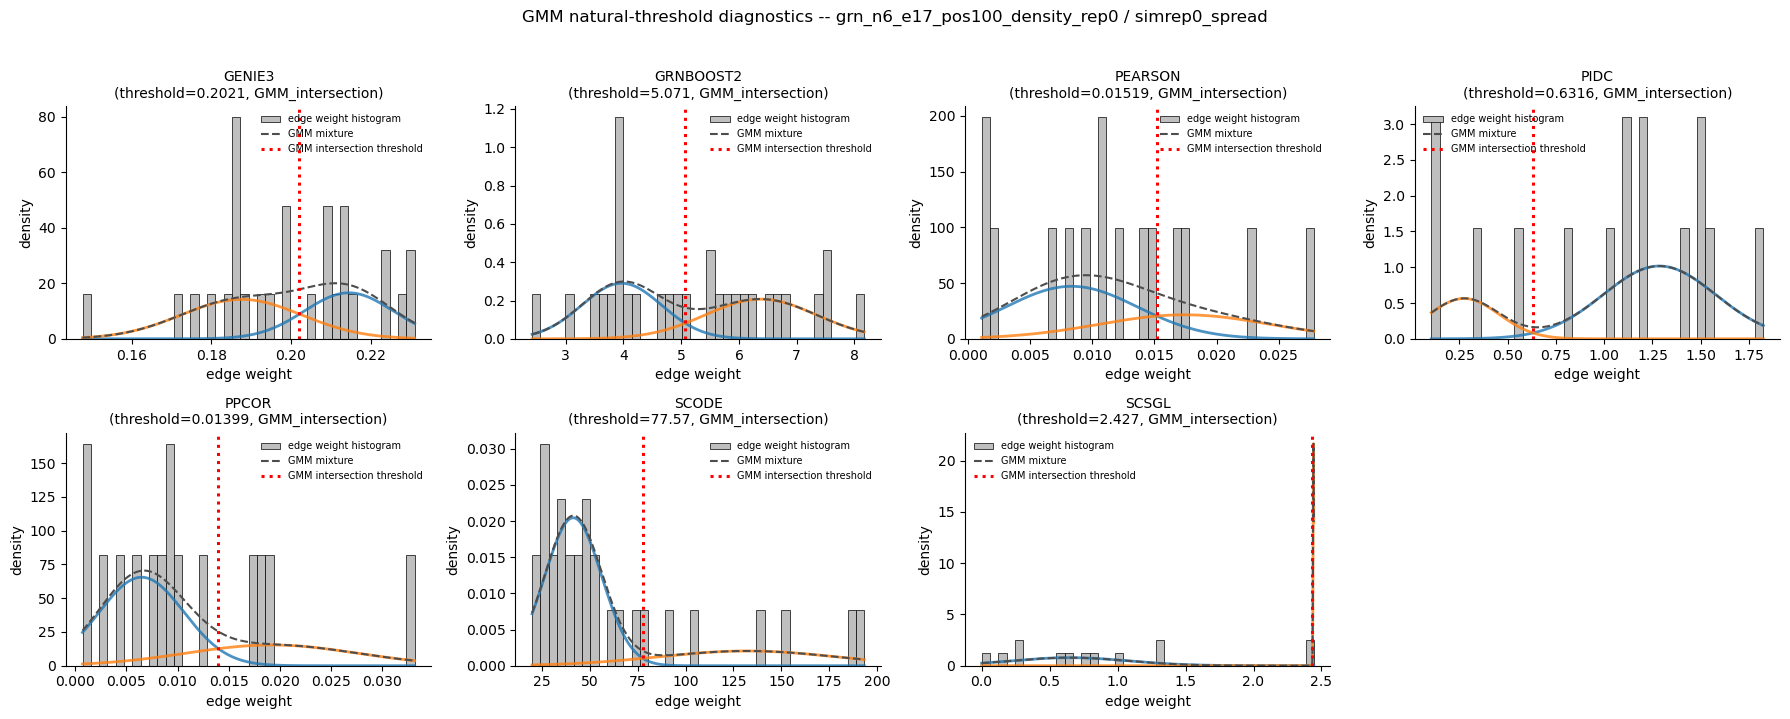

In [22]:
# Pick one representative (dataset, run) -- the one with the most algorithm subdirs
# available, so all 7 methods can be shown side by side.
_candidate_runs = []
for dataset_dir in sorted(BEELINE_OUTPUT_ROOT.iterdir()):
    if not dataset_dir.is_dir():
        continue
    for run_dir in sorted(dataset_dir.iterdir()):
        if not run_dir.is_dir() or not RUN_ID_RE.match(run_dir.name):
            continue
        algo_dirs = [d for d in run_dir.iterdir() if (d / "rankedEdges.csv").exists()]
        _candidate_runs.append((len(algo_dirs), dataset_dir.name, run_dir.name, algo_dirs))

_candidate_runs.sort(key=lambda t: t[0], reverse=True)
_, example_dataset, example_run, example_algo_dirs = _candidate_runs[0]
print(f"Using example dataset={example_dataset}, run={example_run}, "
      f"{len(example_algo_dirs)} method(s) available.")

n_methods = len(example_algo_dirs)
ncols = 4
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, algo_dir in enumerate(sorted(example_algo_dirs, key=lambda d: d.name)):
    ranked_edges = pd.read_csv(algo_dir / "rankedEdges.csv", sep="\t", header=0)
    predicted = dedupe_predictions(ranked_edges)
    gmm, gmm_threshold, gmm_mode = fit_gmm_threshold(predicted["_abs"].values)
    plot_gmm_diagnostics(
        axes_flat[i], predicted["_abs"].values, gmm, gmm_mode,
        title=f"{algo_dir.name}\n(threshold={gmm_threshold:.4g}, {gmm_mode})",
    )

for j in range(n_methods, len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle(f"GMM natural-threshold diagnostics -- {example_dataset} / {example_run}", y=1.02)
fig.tight_layout()
plt.show()


## Part 5 -- Combine into one long-form scores table

Reshapes both wide results tables into one common long-form schema
(`method`, `dataset_id`, `scheme`, `pool`, `metric_family`, `variant`, `score_name`, `value`)
so the heatmap code below has a single, uniform data source regardless of which method or
metric family it's rendering. For TwINFER, `pool` holds the 4 nested top-k candidate pools
within the `topk` family, and the 2 fan-out stages (`before_fan_out`/`after_fan_out`)
within the `natural` family; it's `"n/a"` everywhere else (BEELINE methods, and TwINFER's
own `auprc` family, which isn't pool-dependent). `scheme` is `"twinfer"` for TwINFER (it
isn't run through BEELINE's `spread`/`twin_paired` sampling schemes) and `spread`/
`twin_paired` for the other 7 methods.


In [23]:
VARIANT_SUFFIX = {"": "directed_unsigned", "_signed": "signed_directed", "_undirected": "undirected"}


def melt_beeline_wide(df):
    rows = []
    for _, r in df.iterrows():
        base = {"method": r["algorithm"], "dataset_id": r["dataset_id"], "scheme": r["scheme"], "pool": "n/a"}
        for suffix, variant in VARIANT_SUFFIX.items():
            rows.append({**base, "metric_family": "auprc", "variant": variant,
                         "score_name": "auprc", "value": r[f"auprc{suffix}"]})
            for score_name in ("precision", "recall", "f1"):
                rows.append({**base, "metric_family": "natural", "variant": variant,
                             "score_name": score_name, "value": r[f"{score_name}_natural{suffix}"]})
                rows.append({**base, "metric_family": "topk", "variant": variant,
                             "score_name": score_name, "value": r[f"{score_name}_topk{suffix}"]})
    return pd.DataFrame(rows)


def melt_twinfer_wide(df):
    """TwINFER contributes a single row per (metric_family, variant) here, not one per
    fan-out stage / top-k pool: natural uses "after_fan_out" (TwINFER's actual final
    decision, fan-out flag on) and topk uses "all_edges" (no extra potential_regulation/
    heterogeneity restriction). The other stages/pools are still computed and kept in
    twinfer_results_df (score_twinfer_dataset, cell above) -- just not plotted."""
    NATURAL_STAGE_PLOTTED = "after_fan_out"
    TOPK_POOL_PLOTTED = "all_edges"
    rows = []
    for _, r in df.iterrows():
        base = {"method": "TwINFER", "dataset_id": r["dataset_id"], "scheme": "twinfer", "pool": "n/a"}
        for suffix, variant in VARIANT_SUFFIX.items():
            rows.append({**base, "metric_family": "auprc", "variant": variant,
                         "score_name": "auprc", "value": r[f"auprc{suffix}"]})
            for score_name in ("precision", "recall", "f1"):
                rows.append({**base, "metric_family": "natural", "variant": variant,
                             "score_name": score_name,
                             "value": r[f"{score_name}_natural_{NATURAL_STAGE_PLOTTED}{suffix}"]})
                rows.append({**base, "metric_family": "topk", "variant": variant,
                             "score_name": score_name,
                             "value": r[f"{score_name}_topk_{TOPK_POOL_PLOTTED}{suffix}"]})
    return pd.DataFrame(rows)


scores_long = pd.concat(
    [melt_twinfer_wide(twinfer_results_df), melt_beeline_wide(beeline_results_df)],
    ignore_index=True,
)
print(f"scores_long: {len(scores_long)} rows, methods = {sorted(scores_long['method'].unique())}")
scores_long.head()


scores_long: 57363 rows, methods = ['GENIE3', 'GRNBOOST2', 'PEARSON', 'PIDC', 'PPCOR', 'SCODE', 'SCSGL', 'TwINFER']


,method,dataset_id,scheme,pool,metric_family,variant,score_name,value
0,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,n/a,auprc,directed_unsigned,auprc,0.563211
1,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,before_fan_out,natural,directed_unsigned,precision,0.333333
2,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,before_fan_out,natural,directed_unsigned,recall,0.058824
3,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,before_fan_out,natural,directed_unsigned,f1,0.100000
4,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,after_fan_out,natural,directed_unsigned,precision,0.333333


In [24]:
scores_long[(scores_long['scheme'] == "twinfer") & (scores_long['metric_family'] == "topk") & (scores_long['pool'] == "all_edges")]

,method,dataset_id,scheme,pool,metric_family,variant,score_name,value
7,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,all_edges,topk,directed_unsigned,precision,0.705882
8,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,all_edges,topk,directed_unsigned,recall,0.705882
9,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,all_edges,topk,directed_unsigned,f1,0.705882
26,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,all_edges,topk,signed_directed,precision,0.529412
27,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,all_edges,topk,signed_directed,recall,0.529412
...,...,...,...,...,...,...,...,...
14220,TwINFER,grn_n6_e9_pos50_sign_ratio_rep2,twinfer,all_edges,topk,signed_directed,recall,0.777778
14221,TwINFER,grn_n6_e9_pos50_sign_ratio_rep2,twinfer,all_edges,topk,signed_directed,f1,0.777778
14238,TwINFER,grn_n6_e9_pos50_sign_ratio_rep2,twinfer,all_edges,topk,undirected,precision,0.875000
14239,TwINFER,grn_n6_e9_pos50_sign_ratio_rep2,twinfer,all_edges,topk,undirected,recall,0.875000


### Summary metrics table -- all methods x all variants x all network types, F1 / precision (natural + top-k) / AUPRC

Long-form table with columns `variant`, `dataset_id`, `method`, and the 5 metrics. For
each variant (`directed_unsigned`, `signed_directed`, `undirected`), there is one block
per network topology (`dataset_id`, averaged over its 10 replicate runs) plus a pooled
`dataset_id == "ALL"` block averaged over every (dataset, run). Saved alongside the
20260824 rerun data.

In [ ]:
SUMMARY_METRICS = [
    ("f1_natural", "natural", "f1"),
    ("precision_natural", "natural", "precision"),
    ("f1_topk", "topk", "f1"),
    ("precision_topk", "topk", "precision"),
    ("auprc", "auprc", "auprc"),
]

def build_summary_table(sub_scores):
    """method x metric table for one (variant, dataset_id) slice."""
    rows = []
    for method in sorted(sub_scores["method"].unique()):
        sub = sub_scores[sub_scores["method"] == method]
        row = {"method": method}
        for col_name, metric_family, score_name in SUMMARY_METRICS:
            mask = (sub["metric_family"] == metric_family) & (sub["score_name"] == score_name)
            row[col_name] = sub.loc[mask, "value"].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("method")

_summary_blocks = []
for variant in scores_long["variant"].unique():
    v_scores = scores_long[scores_long["variant"] == variant]
    for dataset_id in sorted(v_scores["dataset_id"].unique()):
        block = build_summary_table(v_scores[v_scores["dataset_id"] == dataset_id]).round(4).reset_index()
        block.insert(0, "dataset_id", dataset_id)
        block.insert(0, "variant", variant)
        _summary_blocks.append(block)
    pooled = build_summary_table(v_scores).round(4).reset_index()
    pooled.insert(0, "dataset_id", "ALL")
    pooled.insert(0, "variant", variant)
    _summary_blocks.append(pooled)

summary_table_all = pd.concat(_summary_blocks, ignore_index=True)

SUMMARY_TABLE_CSV = "/home/gzu5140/TwINFER_KA/analysis_data/synthetic_network_benchmark_20260824/summary_metrics_table.csv"
summary_table_all.to_csv(SUMMARY_TABLE_CSV, index=False)
print(f"Saved summary metrics table ({len(summary_table_all)} rows, "
      f"variants = {sorted(scores_long['variant'].unique())}, "
      f"{summary_table_all['dataset_id'].nunique()} dataset_id group(s) incl. ALL) -> {SUMMARY_TABLE_CSV}")
summary_table_all[(summary_table_all["variant"] == "directed_unsigned") & (summary_table_all["dataset_id"] == "ALL")]


## Part 6 -- Heatmaps

The only plot type in this notebook, per request. Style ported from
`evaluate_networksweep_final_beeline.ipynb`'s `plot_heatmap_by_algorithm_dataset`: rows =
method. TwINFER expands into multiple rows -- 4 (one per top-k candidate pool) within the
`topk` metric family, 2 (`before_fan_out`/`after_fan_out`) within the `natural` family --
directly showing the effect of fan-out removal at both the ranking (top-k) and hard-decision
(natural) level; elsewhere (`auprc`) it's a single row, folded into every BEELINE scheme
panel since it isn't run through `spread`/`twin_paired` sampling. Columns = dataset
(topology), averaged across technical replicates, plus an `Average` and `Rank` summary
column. One heatmap per (`metric_family`, `variant`, `score_name`, BEELINE `scheme`)
combination.


In [25]:
def _method_row_label(row):
    # TwINFER now contributes exactly one row per metric_family (after_fan_out natural,
    # all_edges topk -- see melt_twinfer_wide), so no pool-qualifier is needed anymore.
    return row["method"]


scores_long["method_label"] = scores_long.apply(_method_row_label, axis=1)

HEATMAP_CMAP = sns.color_palette("mako_r", as_cmap=True)
HEATMAP_SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
GRIDLINE = "#e1e0d9"

DATASET_LABEL_RE = re.compile(
    r"^grn_n\d+_e(?P<e>\d+)(?:_pos(?P<pos>\d+))?_(?P<variant>density|sign_ratio|center)_rep(?P<rep>\d+)$"
)

# "center" (E9, pos100 -- 9 edges, 100% positive) is the shared baseline point for
# BOTH sweep axes: 9 edges is density's middle value (between 5 and 17), and pos100 is
# sign_ratio's all-positive endpoint (the sweep's own pos_levels only cover 0/50
# directly -- 100 exists only via "center"). Rather than picking one axis, it's shown
# in BOTH: dataset_column_slots maps it to two distinct column slots (a "9 edges" slot
# in the density group, an "All-positive" slot in the sign_ratio group), each carrying
# the same underlying per-replicate data. Every other dataset_id maps to exactly one
# slot. slot_key = (dataset_id, group) uniquely identifies each slot, since center's
# dataset_id repeats across its two slots.
DATASET_GROUP_LABELS = {
    ("density", "5"): "5 edges",
    ("density", "9"): "9 edges",
    ("density", "17"): "17 edges",
    ("sign_ratio", "0"): "All-negative",
    ("sign_ratio", "50"): "Balanced",
    ("sign_ratio", "100"): "All-positive",
}
DATASET_WITHIN_GROUP_ORDER = {
    ("density", "5 edges"): 0, ("density", "9 edges"): 1, ("density", "17 edges"): 2,
    ("sign_ratio", "All-negative"): 0, ("sign_ratio", "Balanced"): 1, ("sign_ratio", "All-positive"): 2,
}
DATASET_GROUP_ORDER = ["density", "sign_ratio"]
DATASET_GROUP_SUBTITLES = {
    "density": "Change in density of network",
    "sign_ratio": "Change in fraction of negative edges",
}


def dataset_column_slots(dataset_id):
    """Returns a list of (slot_key, group, label, rep) for this dataset_id. Every
    recognized id maps to exactly one slot, except "center" which maps to two (see
    module comment above). Returns [] for a non-matching id."""
    m = DATASET_LABEL_RE.match(dataset_id)
    if not m:
        return []
    rep = int(m["rep"])
    if m["variant"] == "center":
        return [
            ((dataset_id, "density"), "density", DATASET_GROUP_LABELS[("density", "9")], rep),
            ((dataset_id, "sign_ratio"), "sign_ratio", DATASET_GROUP_LABELS[("sign_ratio", "100")], rep),
        ]
    variant = m["variant"]
    key = (variant, m["e"] if variant == "density" else m["pos"])
    if key not in DATASET_GROUP_LABELS:
        return []
    return [((dataset_id, variant), variant, DATASET_GROUP_LABELS[key], rep)]


def slot_column_label(slot_key):
    """Per-column x-tick text for a slot_key: '<group label> · r<replicate>'."""
    if slot_key is None:
        return ""
    dataset_id, variant = slot_key
    for sk, _, label, rep in dataset_column_slots(dataset_id):
        if sk == slot_key:
            return f"{label} · r{rep}"
    return str(slot_key)


def ordered_dataset_columns(dataset_ids):
    """Sorts the column slots for dataset_ids into [density group ascending, gap,
    sign_ratio group ascending] (each further sorted by (swept value, replicate));
    "center" contributes a slot to both groups, everything else contributes one, and
    non-matching ids are dropped. Returns (ordered_slots, group_spans), where
    ordered_slots has a literal None entry marking the inserted gap column, and
    group_spans maps each present group name to its (start, end) column-index range
    (inclusive, gap-inclusive indexing) for drawing the group subtitle."""
    entries = []
    for did in dataset_ids:
        entries.extend(dataset_column_slots(did))

    ordered_slots, group_spans = [], {}
    for variant in DATASET_GROUP_ORDER:
        group_entries = sorted(
            (e for e in entries if e[1] == variant),
            key=lambda e: (DATASET_WITHIN_GROUP_ORDER[(e[1], e[2])], e[3]),
        )
        if not group_entries:
            continue
        if ordered_slots:
            ordered_slots.append(None)  # gap between groups
        start = len(ordered_slots)
        ordered_slots.extend(e[0] for e in group_entries)  # slot_key
        group_spans[variant] = (start, len(ordered_slots) - 1)
    return ordered_slots, group_spans


def _expand_subset_with_slots(subset):
    """Returns a copy of subset with a new 'dataset_slot' column: most rows map 1:1 to
    a single slot, but rows whose dataset_id is "center" are duplicated into two rows
    (the density slot and the sign_ratio slot), since it's the shared point for both
    sweeps. Rows with a non-matching dataset_id are dropped (mirrors ordered_dataset_columns)."""
    slot_col = subset["dataset_id"].map(dataset_column_slots)
    expanded = subset.loc[subset.index.repeat(slot_col.map(len))].copy()
    expanded["dataset_slot"] = [slot for slots in slot_col for slot, *_ in slots]
    return expanded


def _draw_group_subtitles(ax, group_spans):
    """Small italic subtitle centered over each group's column span, just above the
    heatmap (axes-fraction y, data-coord x -- stays aligned with the columns
    regardless of figure size)."""
    for variant, (start, end) in group_spans.items():
        x_mid = (start + end) / 2
        ax.text(x_mid, 1.02, DATASET_GROUP_SUBTITLES[variant], transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=9, style="italic", color=INK_PRIMARY)


def _label_color_for(val, norm, cmap):
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if luminance < 0.6 else INK_PRIMARY


def plot_heatmap_by_method_dataset(subset, value_col="value", ax=None, title=None):
    """
    Rows = method_label, columns = dataset column slot (mean across technical
    replicates/sim_reps within a slot), plus Average and Rank summary columns -- ported
    from evaluate_networksweep_final_beeline.ipynb's plot_heatmap_by_algorithm_dataset.
    Columns are grouped/ordered by ordered_dataset_columns (density sweep, gap, sign
    sweep, each ascending; "center" appears in both), with group subtitles drawn above.
    """
    ordered_slots, group_spans = ordered_dataset_columns(subset["dataset_id"].unique())
    if not ordered_slots:
        return None

    expanded = _expand_subset_with_slots(subset)
    pivot = expanded.groupby(["method_label", "dataset_slot"])[value_col].mean().unstack("dataset_slot")
    if pivot.empty:
        return None
    pivot = pivot.reindex(columns=ordered_slots)

    row_avg = pivot.mean(axis=1)
    row_rank = row_avg.rank(ascending=False, method="min").astype(int)
    pivot = pivot.loc[row_avg.sort_values(ascending=False).index]
    row_avg = row_avg.loc[pivot.index]
    row_rank = row_rank.loc[pivot.index]

    n_dataset_cols = pivot.shape[1]
    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(0.6 * (n_dataset_cols + 2) + 3, 0.4 * len(pivot.index) + 4))

    finite_vals = pivot.values[~pd.isna(pivot.values)]
    vmax = float(finite_vals.max()) if finite_vals.size else 1.0
    norm = Normalize(vmin=0.0, vmax=max(vmax, 1e-9))

    grid = np.hstack([
        pivot.values,
        row_avg.values.reshape(-1, 1),
        np.full((len(pivot), 1), np.nan),
    ])

    display_cmap = HEATMAP_CMAP.copy()
    display_cmap.set_bad(HEATMAP_SURFACE)
    im = ax.imshow(grid, cmap=display_cmap, aspect="auto", norm=norm)

    for i in range(grid.shape[0]):
        for j in range(n_dataset_cols + 1):
            val = grid[i, j]
            if pd.isna(val):
                continue
            label_color = _label_color_for(val, norm, HEATMAP_CMAP)
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=label_color)
        ax.text(n_dataset_cols + 1, i, f"#{row_rank.iloc[i]}", ha="center", va="center",
                fontsize=10, color=INK_PRIMARY)

    ax.axvline(n_dataset_cols - 0.5, color=GRIDLINE, linewidth=1.5)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels(
        [slot_column_label(c) for c in pivot.columns] + ["Average", "Rank"],
        rotation=45, ha="right", color=INK_PRIMARY, fontsize=9,
    )
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=INK_PRIMARY, fontsize=10)
    ax.set_title(title or "", color=INK_PRIMARY, fontsize=13, pad=28)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    _draw_group_subtitles(ax, group_spans)

    if own_ax:
        fig.colorbar(im, ax=ax, shrink=0.8, label=value_col)
        fig.tight_layout()
        return fig
    return im

### Fan-out pairs detected per network

Before comparing performance, a quick look at how many shared-regulator confound pairs
`separate_fan_outs_from_mutual_regulation` actually found: `n_fan_out_pairs` (both
directions discarded as a fan-out artifact) vs `n_mutual_regulation_pairs` (both
directions kept -- confirmed as genuine reciprocal regulation) per network, mean across
technical replicates.


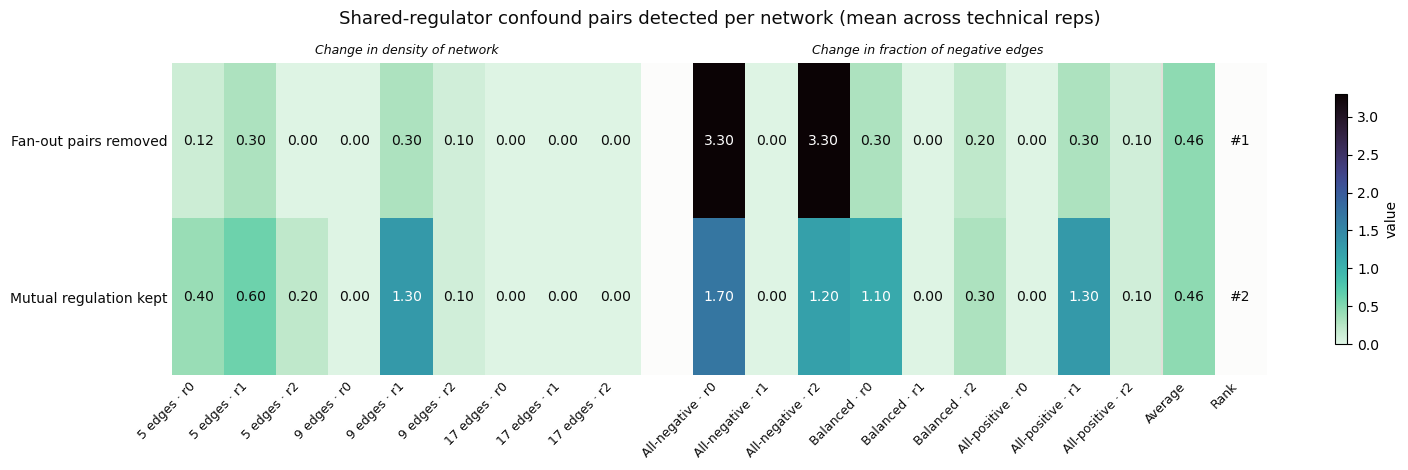

In [26]:
fan_out_counts_long = twinfer_results_df.melt(
    id_vars=["dataset_id"],
    value_vars=["n_fan_out_pairs", "n_mutual_regulation_pairs"],
    var_name="method_label", value_name="value",
)
fan_out_counts_long["method_label"] = fan_out_counts_long["method_label"].map({
    "n_fan_out_pairs": "Fan-out pairs removed",
    "n_mutual_regulation_pairs": "Mutual regulation kept",
})

fig = plot_heatmap_by_method_dataset(
    fan_out_counts_long,
    title="Shared-regulator confound pairs detected per network (mean across technical reps)",
)
if fig is not None:
    plt.show()


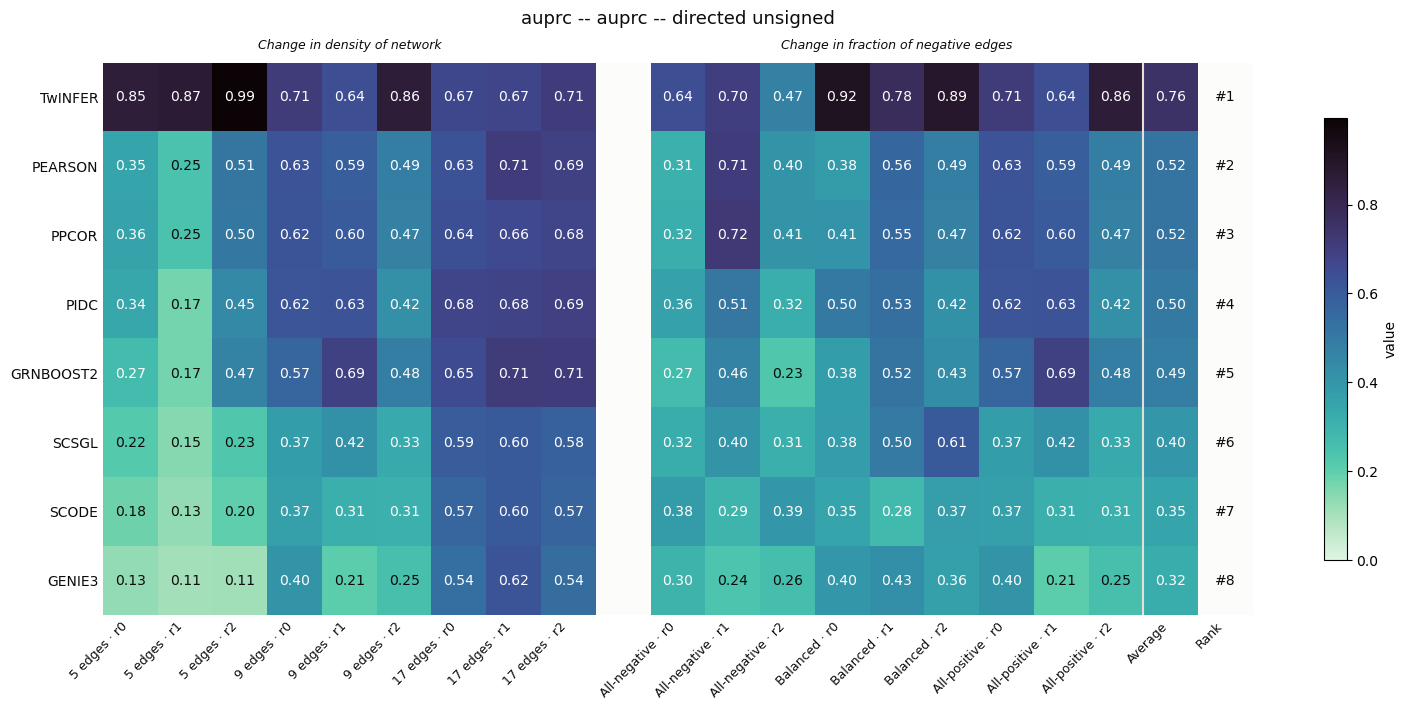

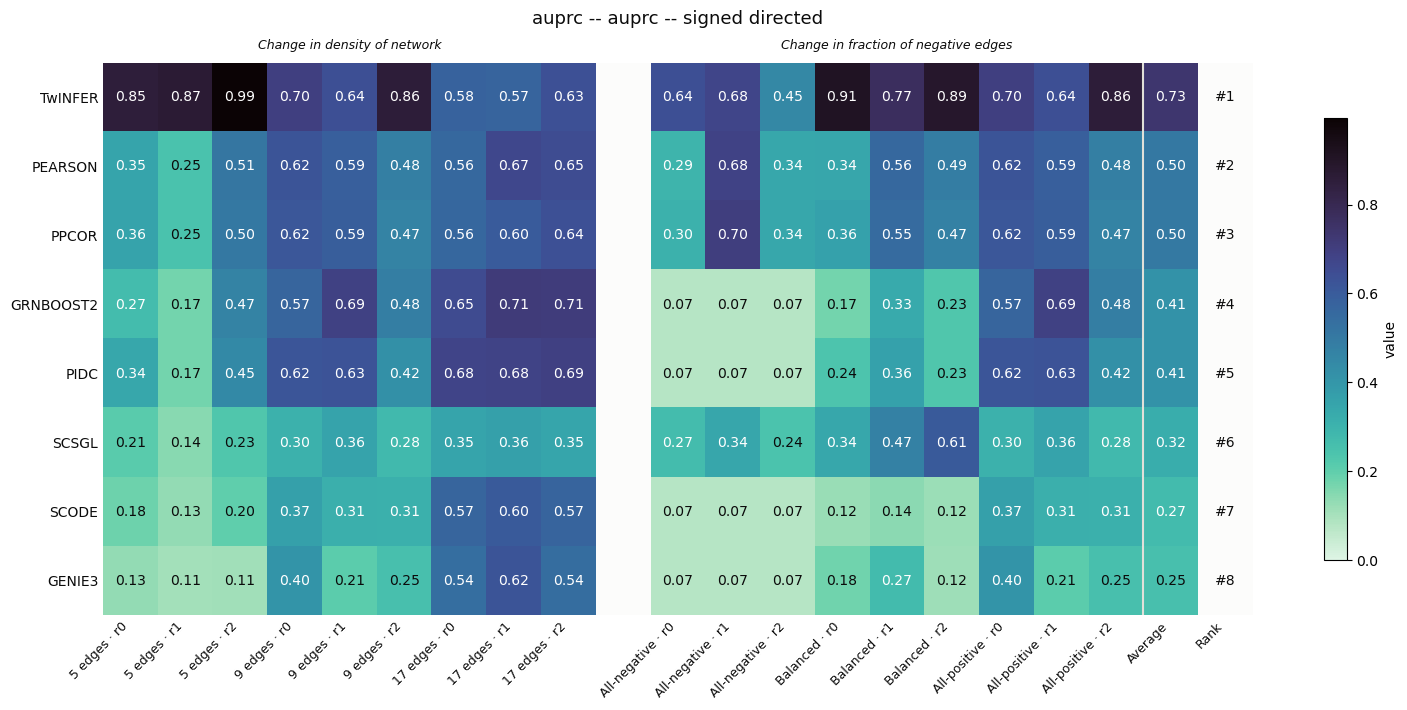

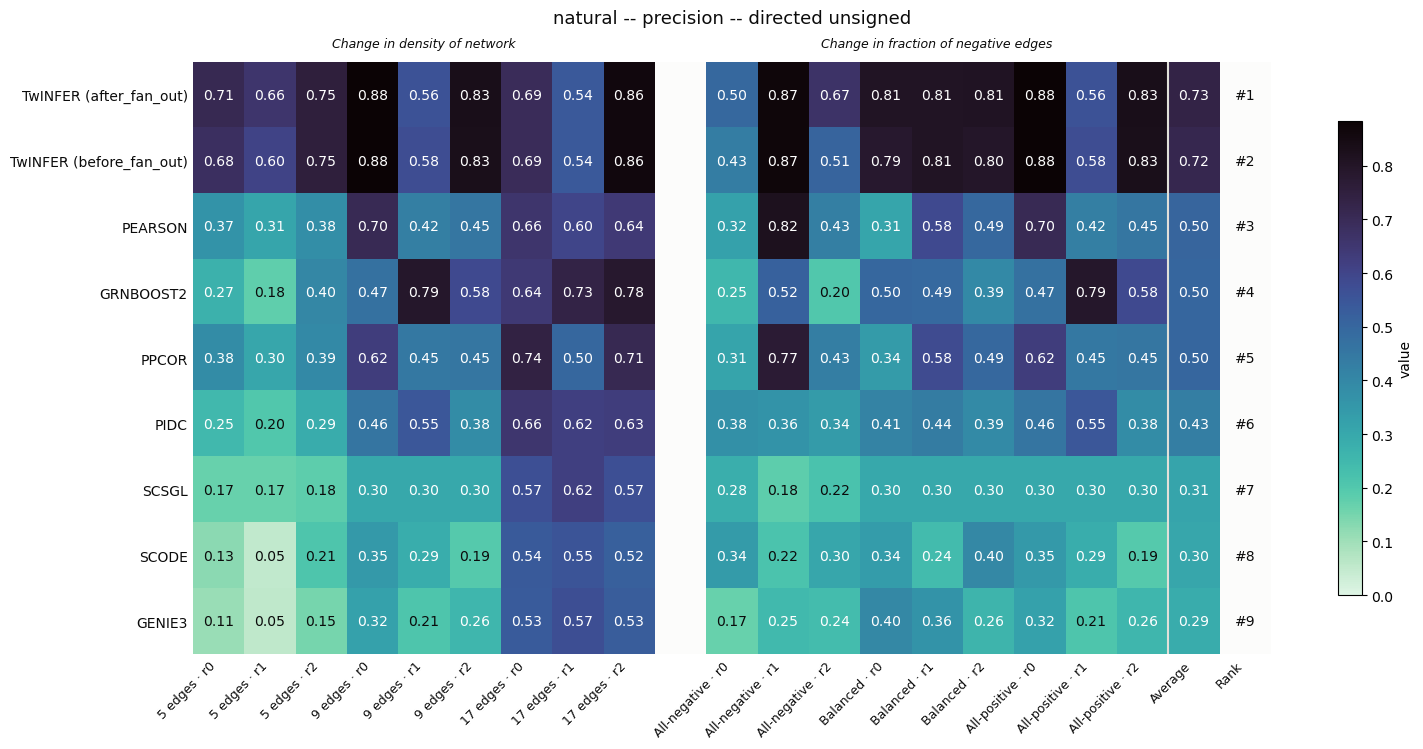

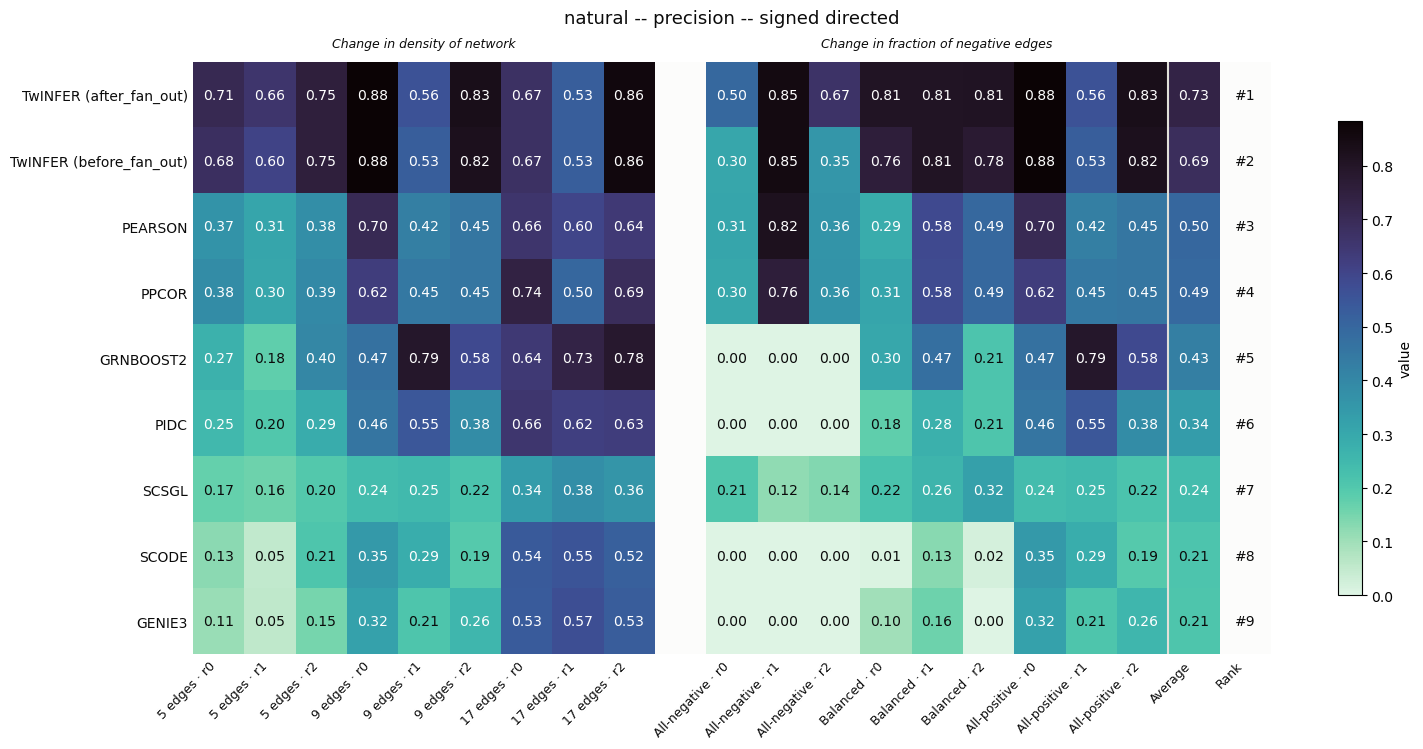

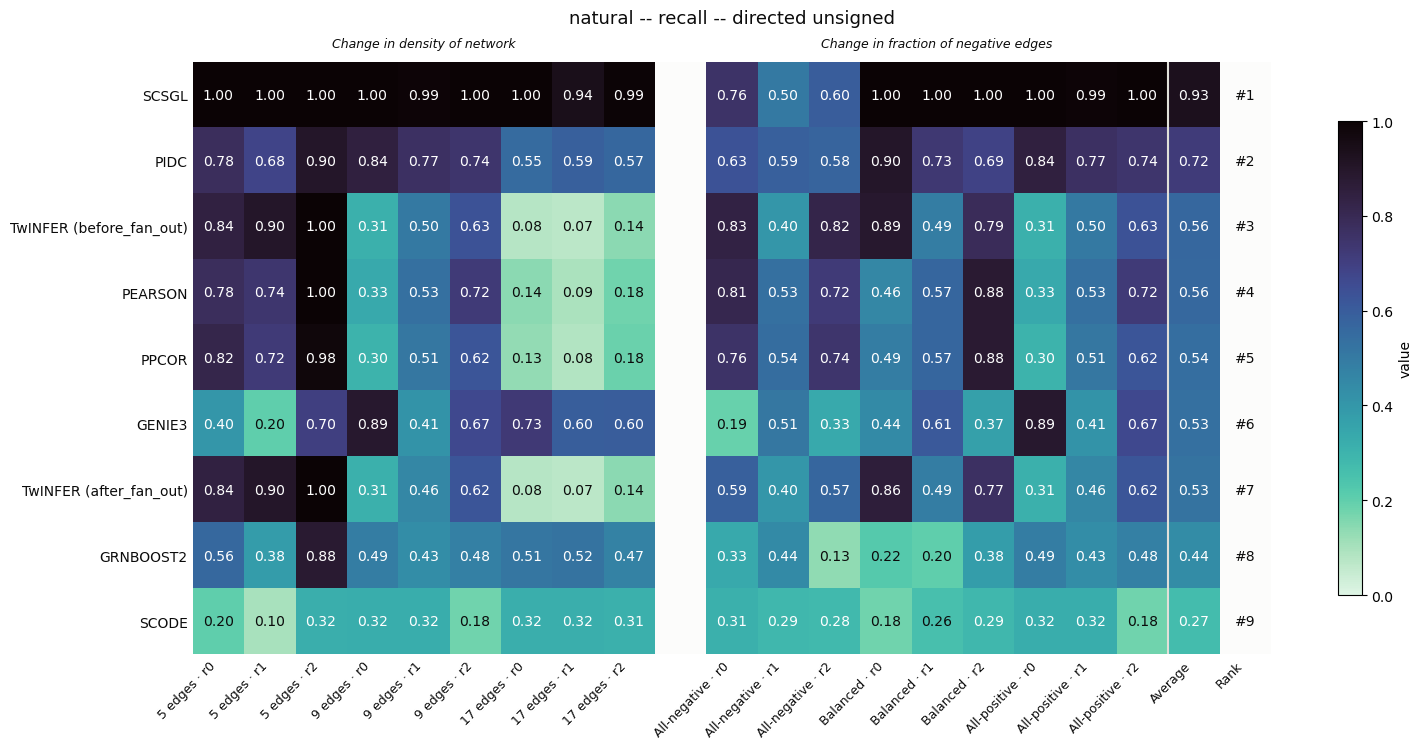

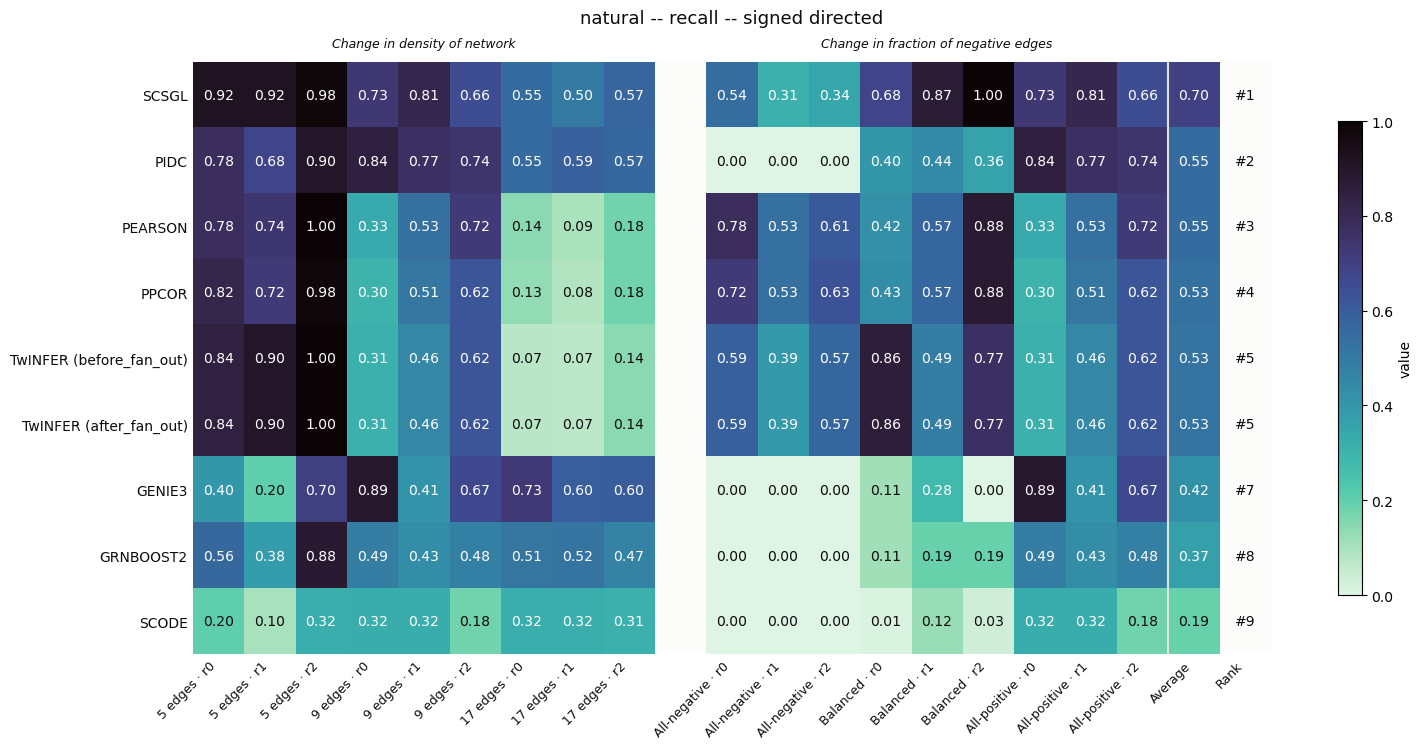

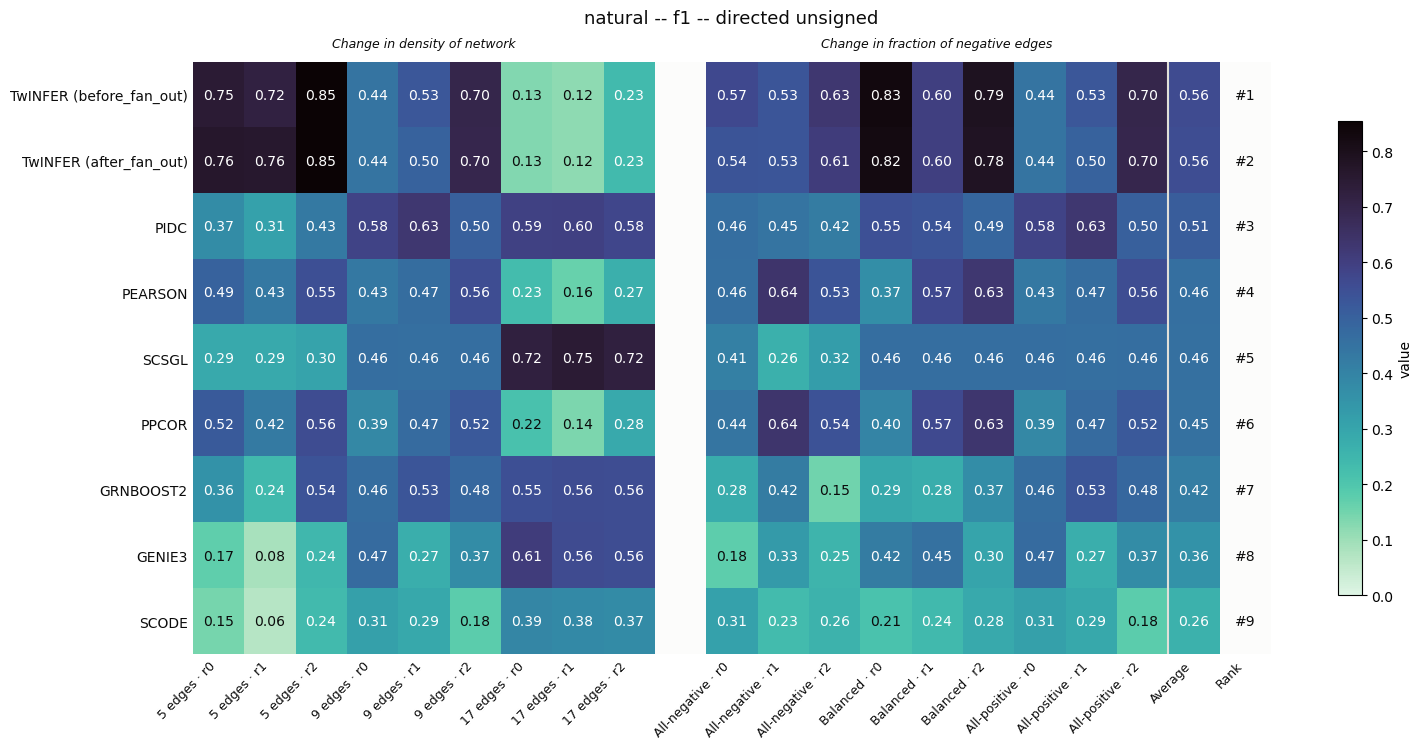

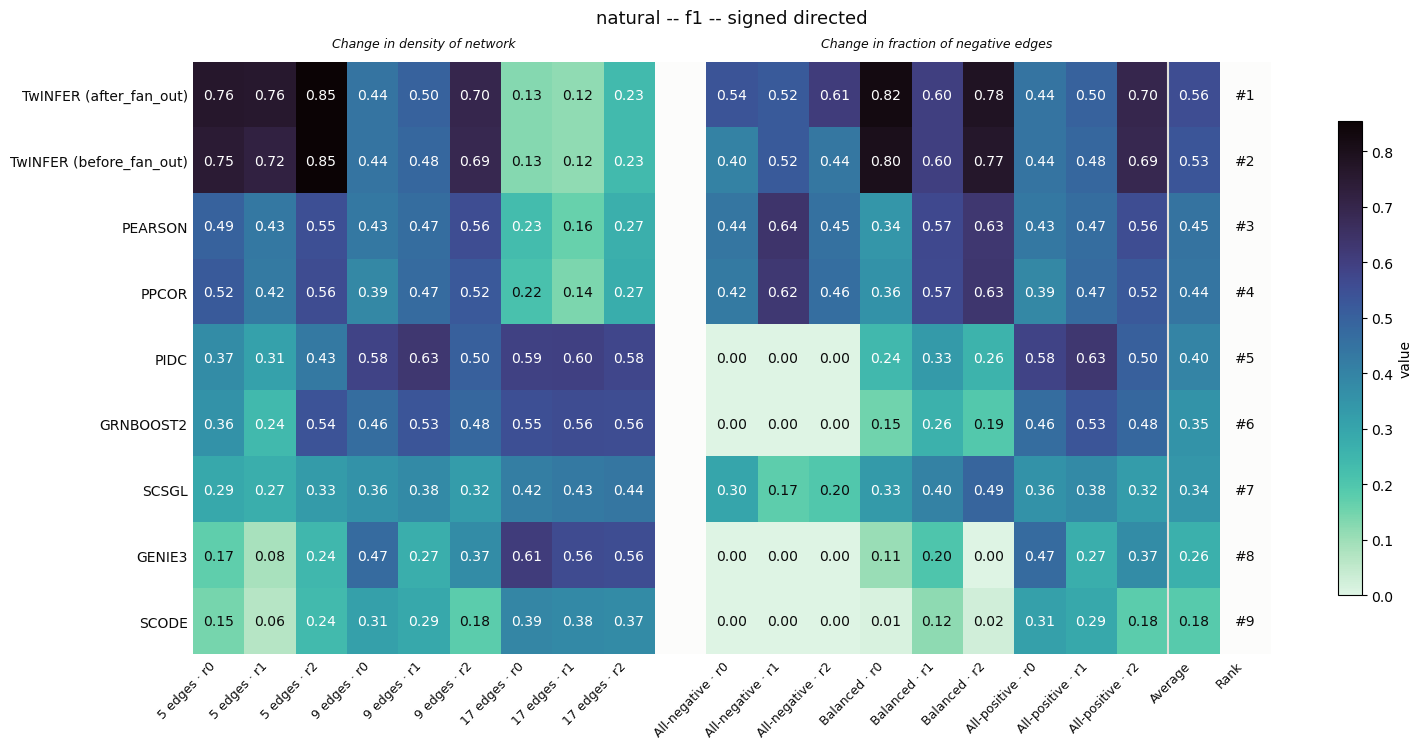

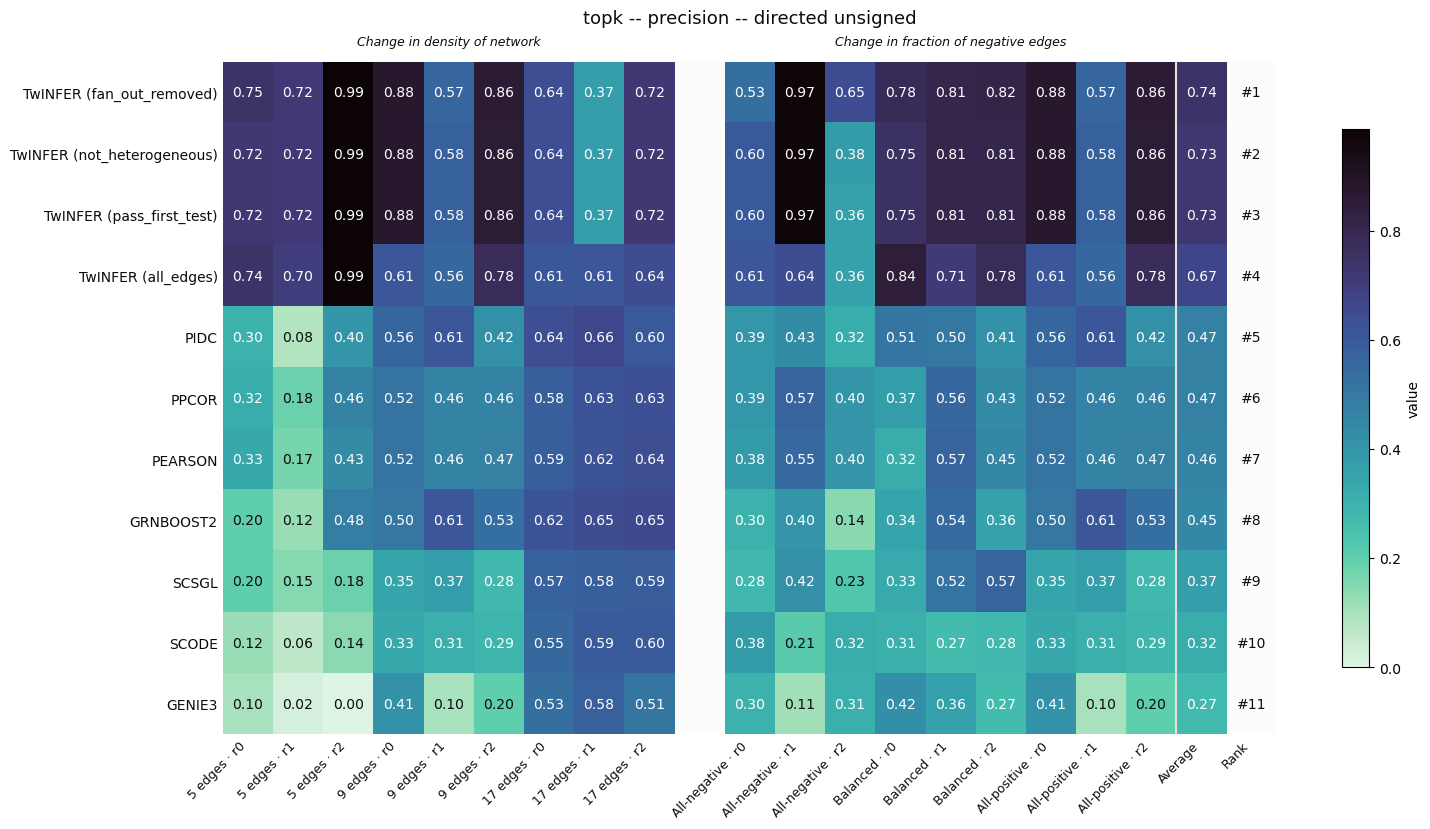

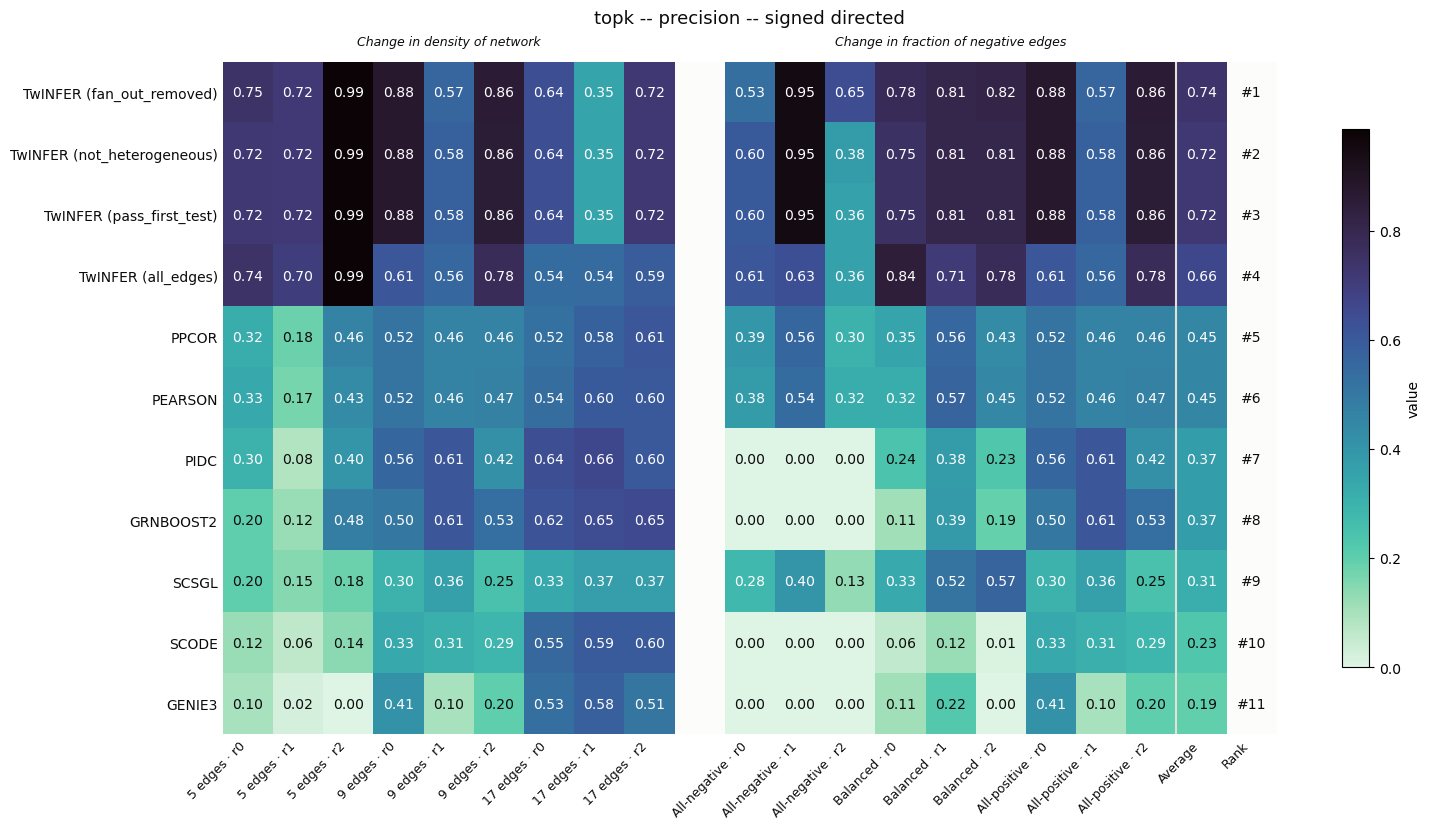

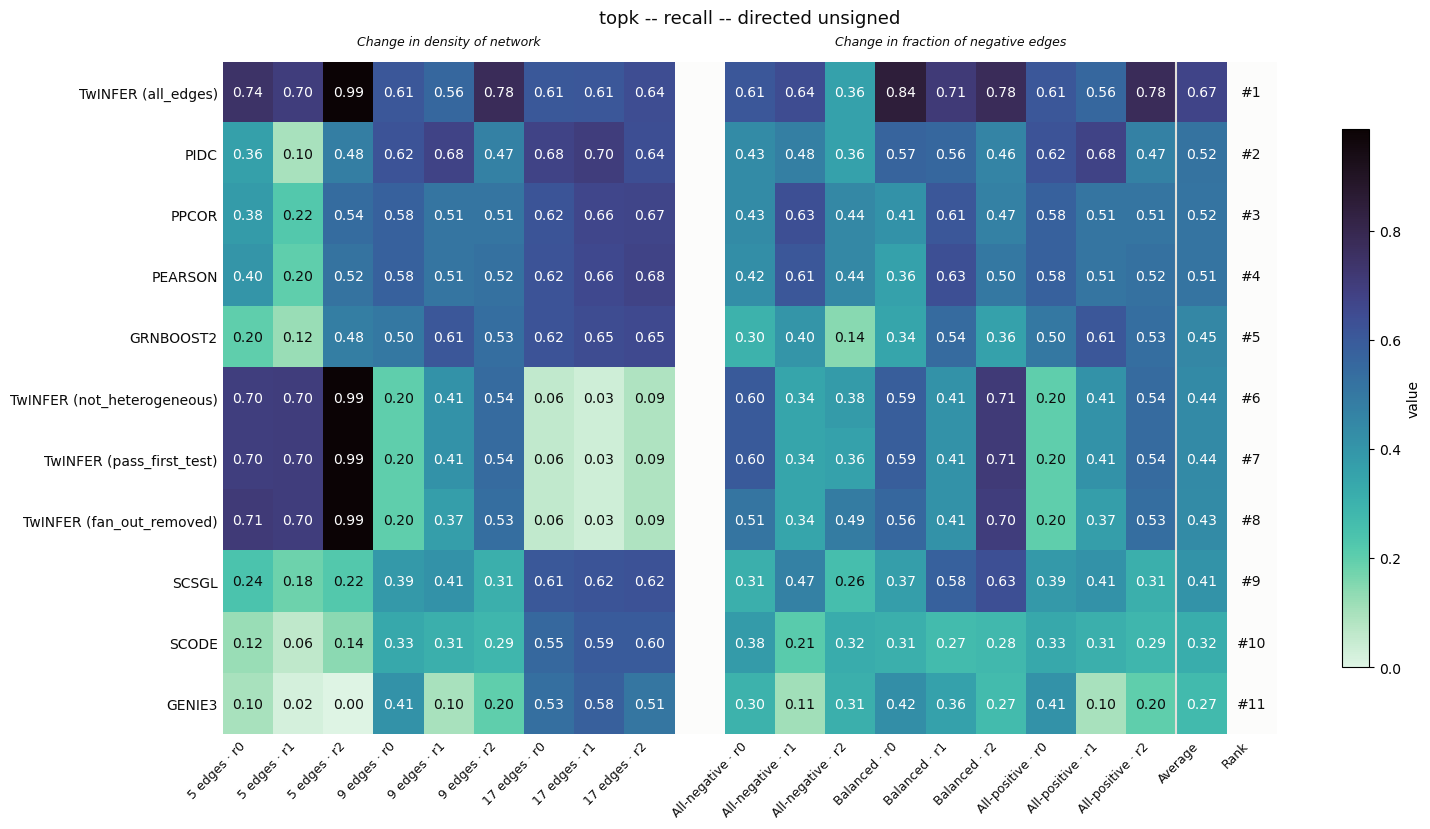

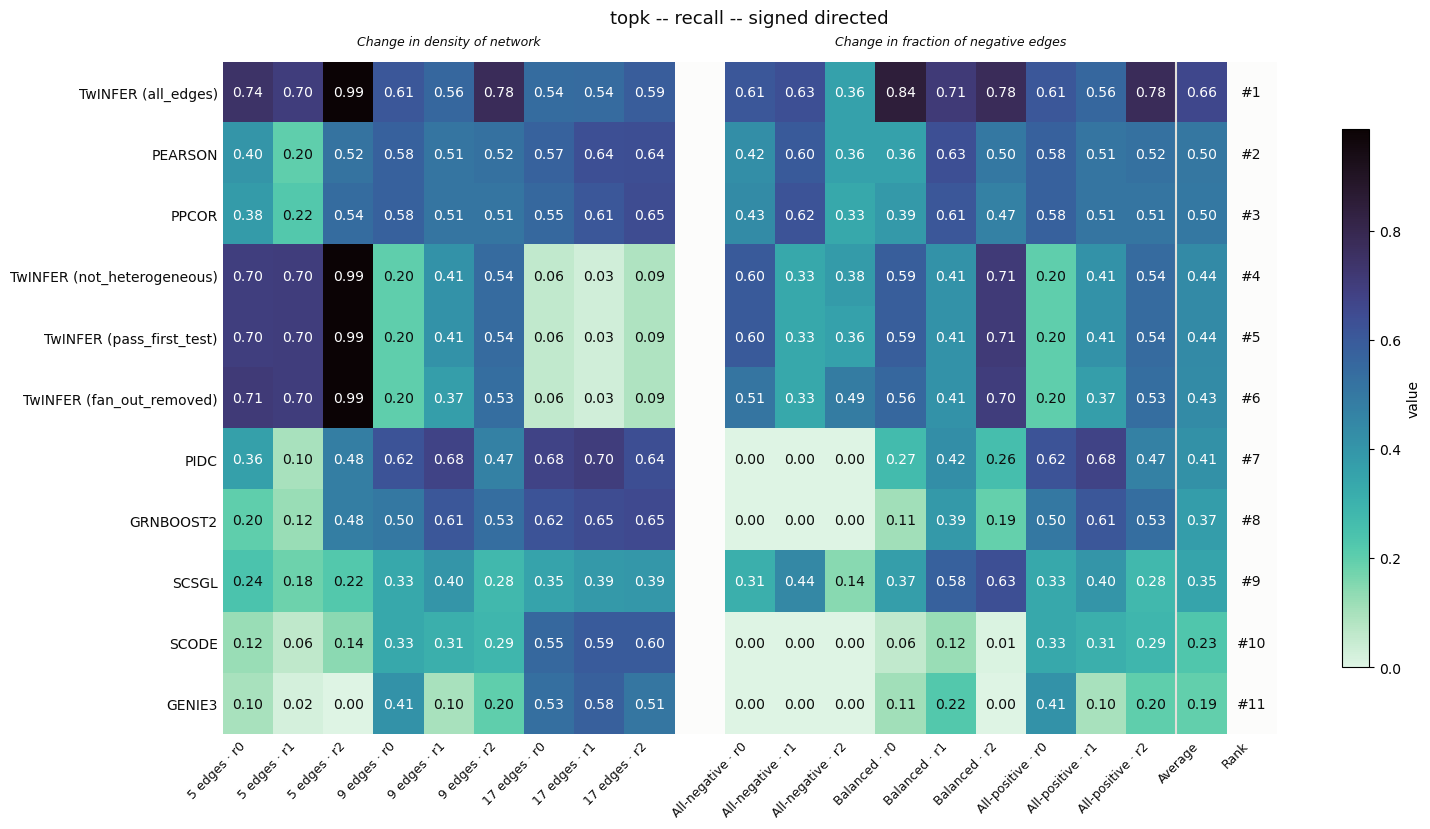

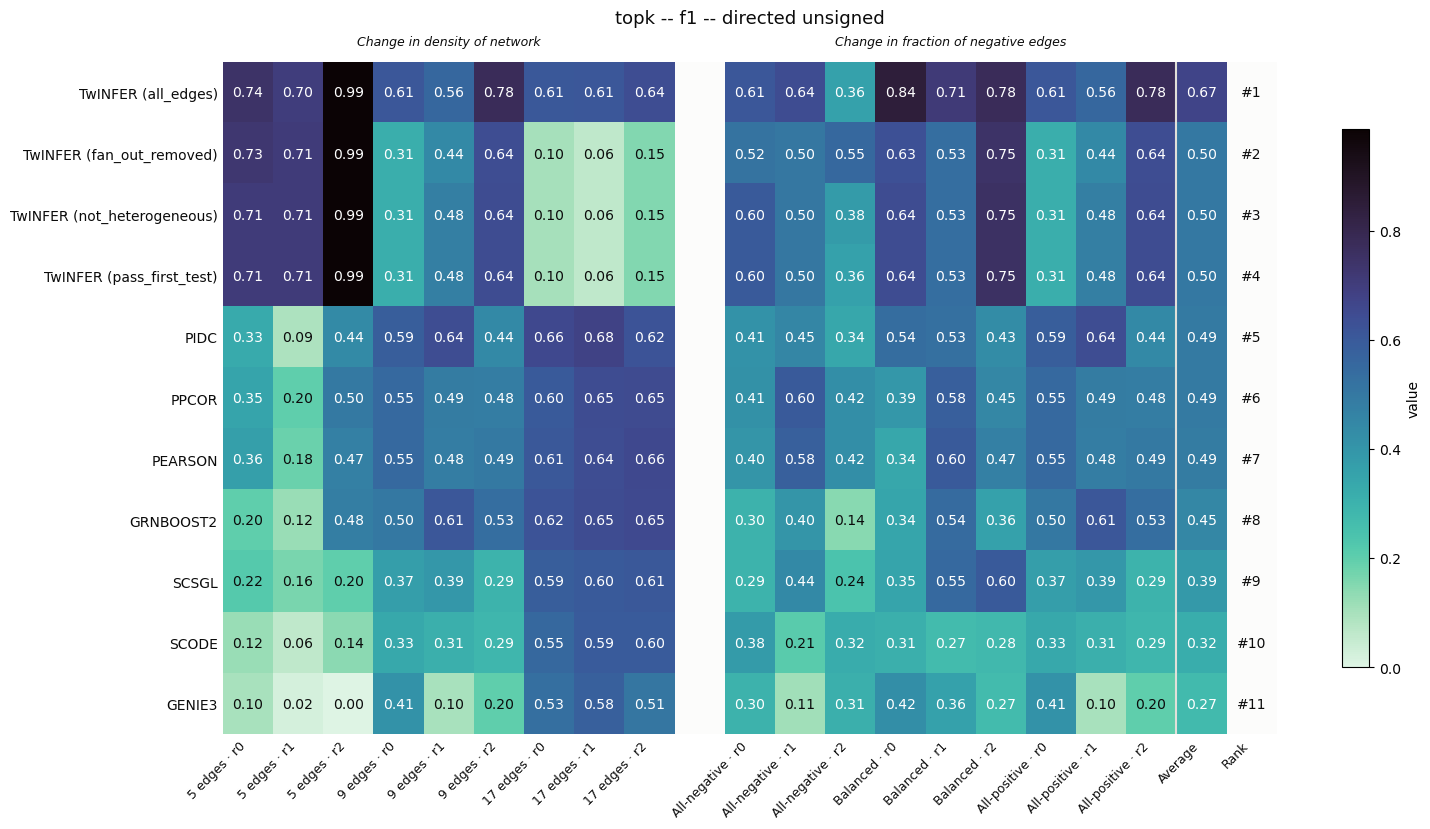

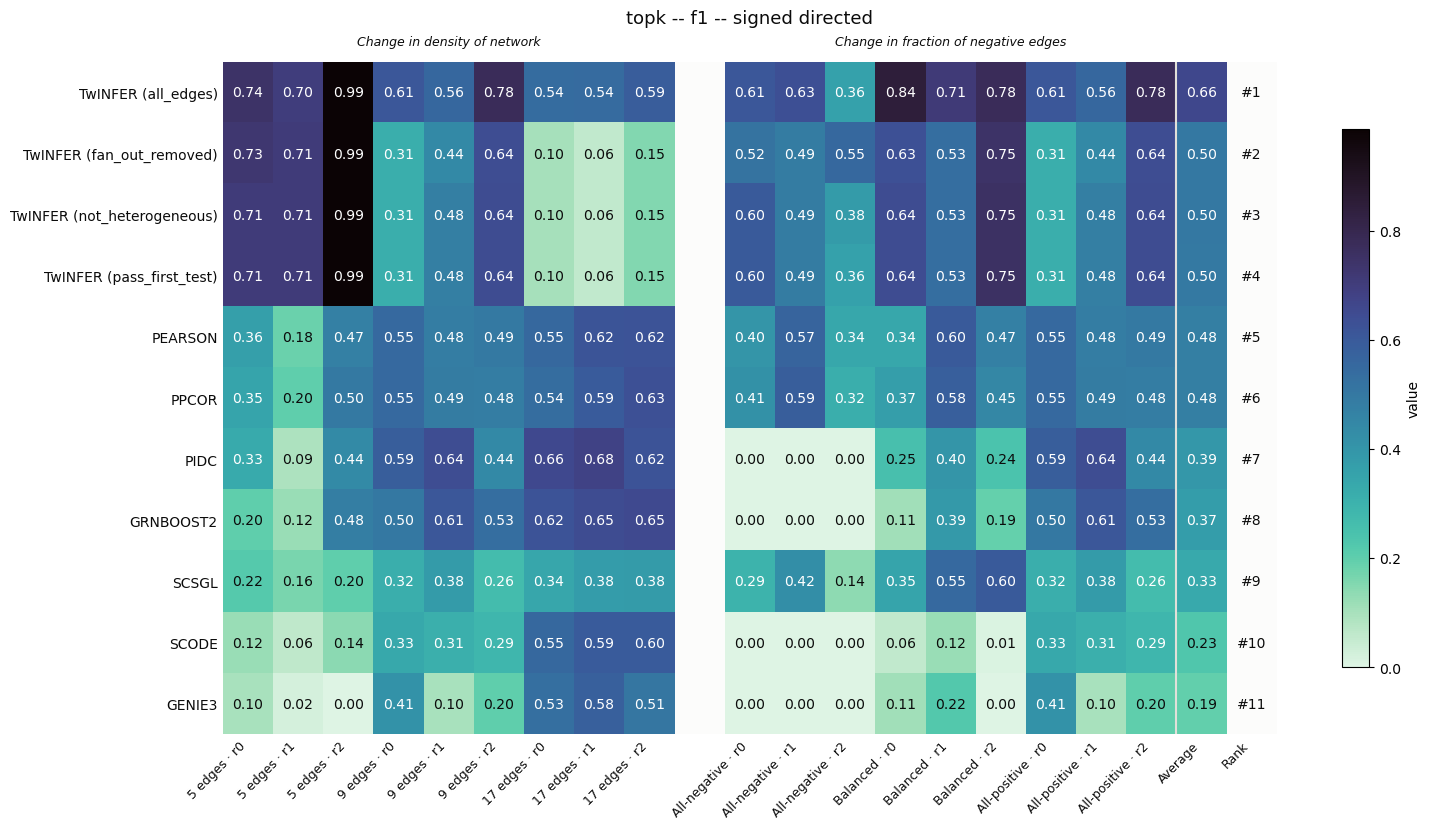

In [27]:
METRIC_FAMILIES = {
    "auprc": ["auprc"],
    "natural": ["precision", "recall", "f1"],
    "topk": ["precision", "recall", "f1"],
}
VARIANTS = ["directed_unsigned", "signed_directed"]
SCHEMES = ["twin_paired"]

for metric_family, score_names in METRIC_FAMILIES.items():
    for score_name in score_names:
        for variant in VARIANTS:
            for scheme in SCHEMES:
                subset = scores_long[
                    (scores_long["metric_family"] == metric_family)
                    & (scores_long["score_name"] == score_name)
                    & (scores_long["variant"] == variant)
                    & ((scores_long["scheme"] == scheme) | (scores_long["method"] == "TwINFER"))
                ]
                if subset.empty:
                    print("empty")
                    continue
                fig = plot_heatmap_by_method_dataset(
                    subset,
                    title=f"{metric_family} -- {score_name} -- {variant.replace('_', ' ')}",
                )
                if fig is not None:
                    plt.show()


In [28]:
def count_ground_truth_fanouts_sweep(network_dir, suffix=".txt"):
    """Ground-truth fan-out pair count per topology (find_confounded_pairs), keyed by
    the same dataset_id convention as twinfer_results_df/beeline_results_df."""
    records = []
    for path in glob.glob(os.path.join(network_dir, f"*{suffix}")):
        dataset_id = os.path.basename(path).replace(suffix, "")
        gt = load_ground_truth_matrix(path)
        fanout_pairs = find_confounded_pairs(gt, list(gt.index))
        records.append({"dataset_id": dataset_id, "n_ground_truth_fanout_pairs": len(fanout_pairs)})
    return pd.DataFrame(records)


gt_fanout_df = count_ground_truth_fanouts_sweep(path_to_ground_truth_dir)

# Same (metric_family, score_name) pairs and variant/scheme values the Part 6 loop below
# iterates over -- keep these in sync with METRIC_FAMILIES/VARIANTS/SCHEMES in that cell.
_METRIC_FAMILY_SCORE_NAMES = {
    "auprc": ["auprc"],
    "natural": ["precision", "recall", "f1"],
    "topk": ["precision", "recall", "f1"],
}
_VARIANTS = ["directed_unsigned", "signed_directed"]
_SCHEMES = ["twin_paired"]

panel_combos = pd.DataFrame([
    {"metric_family": mf, "score_name": sn, "variant": v, "scheme": s}
    for mf, score_names in _METRIC_FAMILY_SCORE_NAMES.items()
    for sn in score_names
    for v in _VARIANTS
    for s in _SCHEMES
])

gt_rows = panel_combos.merge(gt_fanout_df, how="cross")
gt_rows["method"] = "Ground truth"
gt_rows["pool"] = "n/a"
gt_rows["method_label"] = "Ground truth fan-out pairs"
gt_rows = gt_rows.rename(columns={"n_ground_truth_fanout_pairs": "value"})

scores_long = pd.concat([scores_long, gt_rows], ignore_index=True)
print(f"Added {len(gt_rows)} ground-truth fan-out rows across {panel_combos.shape[0]} panel(s).")

Added 210 ground-truth fan-out rows across 14 panel(s).


In [29]:
def _plot_fanout_strip(ax, fanout_pivot, dataset_order, cmap_name="Greys"):
    """Single/few-row strip for raw-count rows (e.g. ground-truth fan-out pairs),
    rendered on its own grayscale color scale -- independent of the main heatmap's
    colormap/normalization, since counts and 0-1 scores aren't comparable.
    fanout_pivot is already keyed by dataset_slot (see plot_heatmap_with_fanout_row);
    dataset_order is the gap-inclusive slot-key ordering from the main panel."""
    fanout_pivot = fanout_pivot.reindex(columns=dataset_order)
    row_avg = fanout_pivot.mean(axis=1)
    n_cols = fanout_pivot.shape[1]

    # Extra trailing NaN column mirrors the main heatmap's "Rank" column so the two
    # panels' dataset columns stay pixel-aligned, even though this strip has no rank.
    grid = np.hstack([
        fanout_pivot.values,
        row_avg.values.reshape(-1, 1),
        np.full((len(fanout_pivot), 1), np.nan),
    ])

    finite_vals = grid[~pd.isna(grid)]
    vmax = float(finite_vals.max()) if finite_vals.size else 1.0
    norm = Normalize(vmin=0.0, vmax=max(vmax, 1e-9))

    cmap = plt.get_cmap(cmap_name)
    display_cmap = cmap.copy()
    display_cmap.set_bad(HEATMAP_SURFACE)
    im = ax.imshow(grid, cmap=display_cmap, aspect="auto", norm=norm)

    for i in range(grid.shape[0]):
        for j in range(n_cols + 1):  # data cols + Average, skip the blank alignment col
            val = grid[i, j]
            if pd.isna(val):
                continue
            r, g, b, _ = cmap(norm(val))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            color = "#ffffff" if luminance < 0.6 else INK_PRIMARY
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=10, color=color)

    ax.axvline(n_cols - 0.5, color=GRIDLINE, linewidth=1.5)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels(
        [slot_column_label(c) for c in fanout_pivot.columns] + ["Average", ""],
        rotation=45, ha="right", color=INK_PRIMARY, fontsize=9,
    )
    ax.set_yticks(range(len(fanout_pivot.index)))
    ax.set_yticklabels(fanout_pivot.index, color=INK_PRIMARY, fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    return im


def plot_heatmap_with_fanout_row(subset, fanout_label="Ground truth fan-out pairs",
                                  value_col="value", title=None):
    """
    Same layout/rows as plot_heatmap_by_method_dataset for the actual methods, plus a
    second, independently-colored strip underneath for the ground-truth fan-out row (if
    present in `subset`) -- separate colorbar/scale since it's a raw count, not a 0-1 score.
    """
    is_fanout = subset["method_label"] == fanout_label
    main_subset = subset[~is_fanout]
    fanout_subset = subset[is_fanout]
    if main_subset.empty:
        return None

    if fanout_subset.empty:
        fig = plot_heatmap_by_method_dataset(main_subset, value_col=value_col, title=title)
        return fig

    ordered_slots, _ = ordered_dataset_columns(main_subset["dataset_id"].unique())
    main_expanded = _expand_subset_with_slots(main_subset)
    main_pivot = main_expanded.groupby(["method_label", "dataset_slot"])[value_col].mean().unstack("dataset_slot")
    main_pivot = main_pivot.reindex(columns=ordered_slots)
    row_avg = main_pivot.mean(axis=1)
    main_pivot = main_pivot.loc[row_avg.sort_values(ascending=False).index]
    dataset_order = main_pivot.columns.tolist()

    n_main_rows = len(main_pivot)
    fanout_expanded = _expand_subset_with_slots(fanout_subset)
    fanout_pivot = fanout_expanded.groupby(["method_label", "dataset_slot"])[value_col].mean().unstack("dataset_slot")
    n_fanout_rows = len(fanout_pivot)

    fig = plt.figure(figsize=(0.6 * (len(dataset_order) + 2) + 3,
                               0.4 * (n_main_rows + n_fanout_rows) + 5))
    gs = fig.add_gridspec(2, 1, height_ratios=[n_main_rows, n_fanout_rows], hspace=0.35)

    ax_main = fig.add_subplot(gs[0])
    im_main = plot_heatmap_by_method_dataset(main_subset, value_col=value_col, ax=ax_main)
    fig.colorbar(im_main, ax=ax_main, shrink=0.8, label=value_col)
    ax_main.set_title(title or "", color=INK_PRIMARY, pad=20)
    ax_main.set_xticklabels([])  # dataset labels shown once, on the bottom strip only

    ax_fanout = fig.add_subplot(gs[1])
    im_fanout = _plot_fanout_strip(ax_fanout, fanout_pivot, dataset_order)
    fig.colorbar(im_fanout, ax=ax_fanout, shrink=0.8, label="fan-out pair count")

    return fig

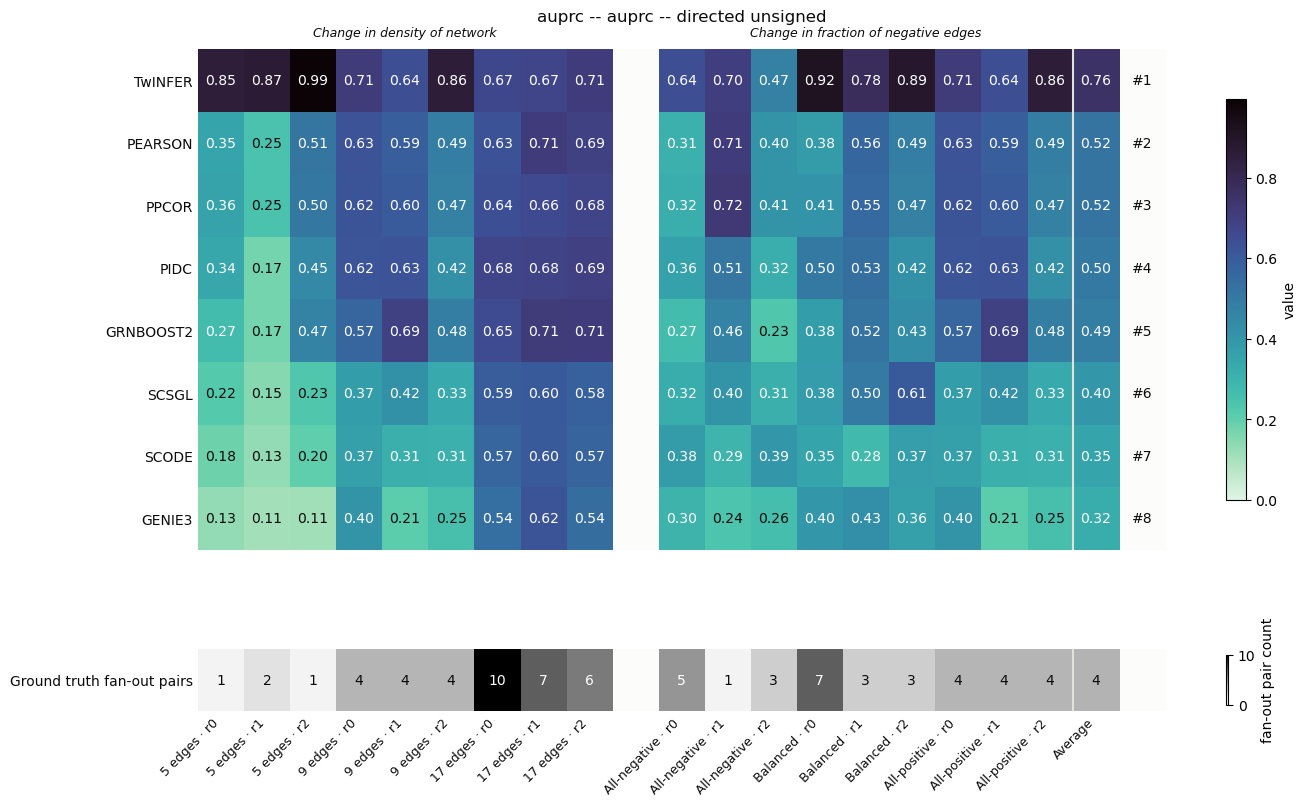

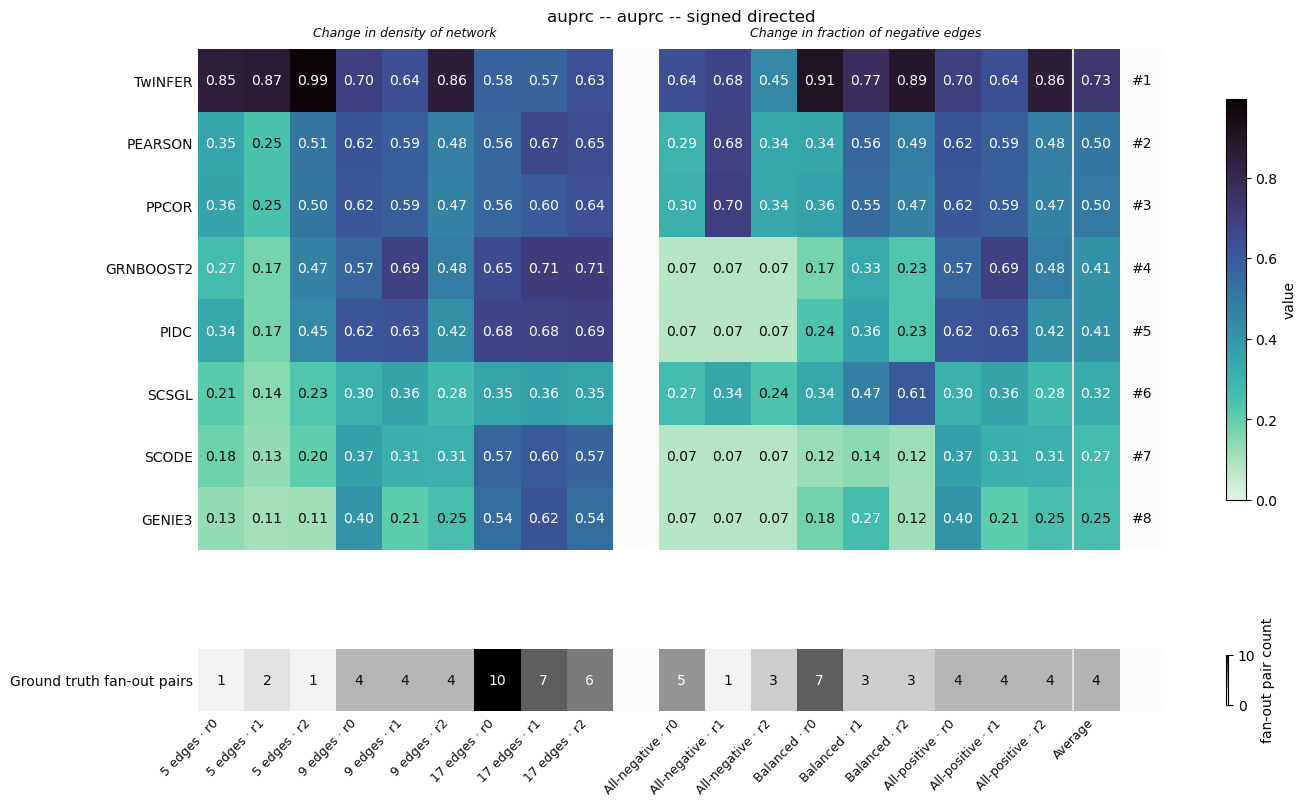

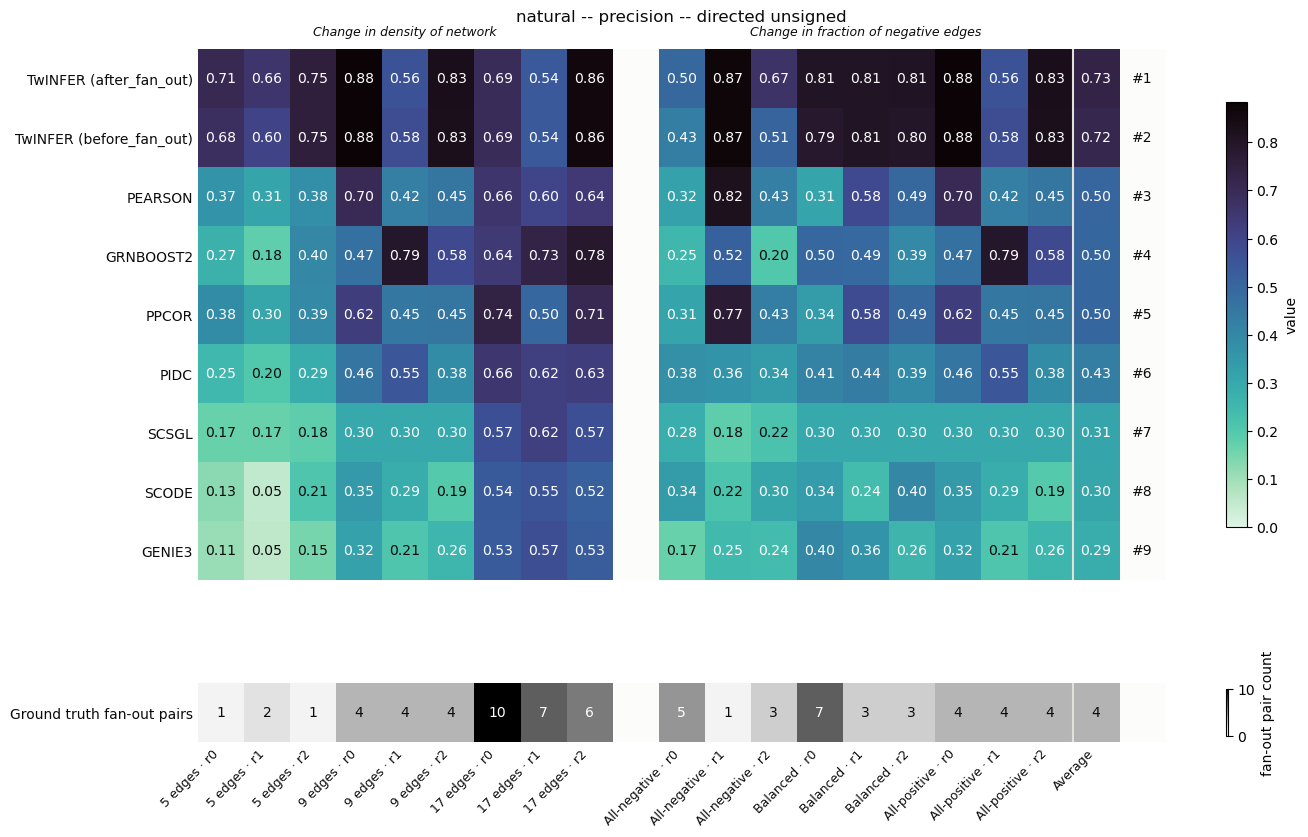

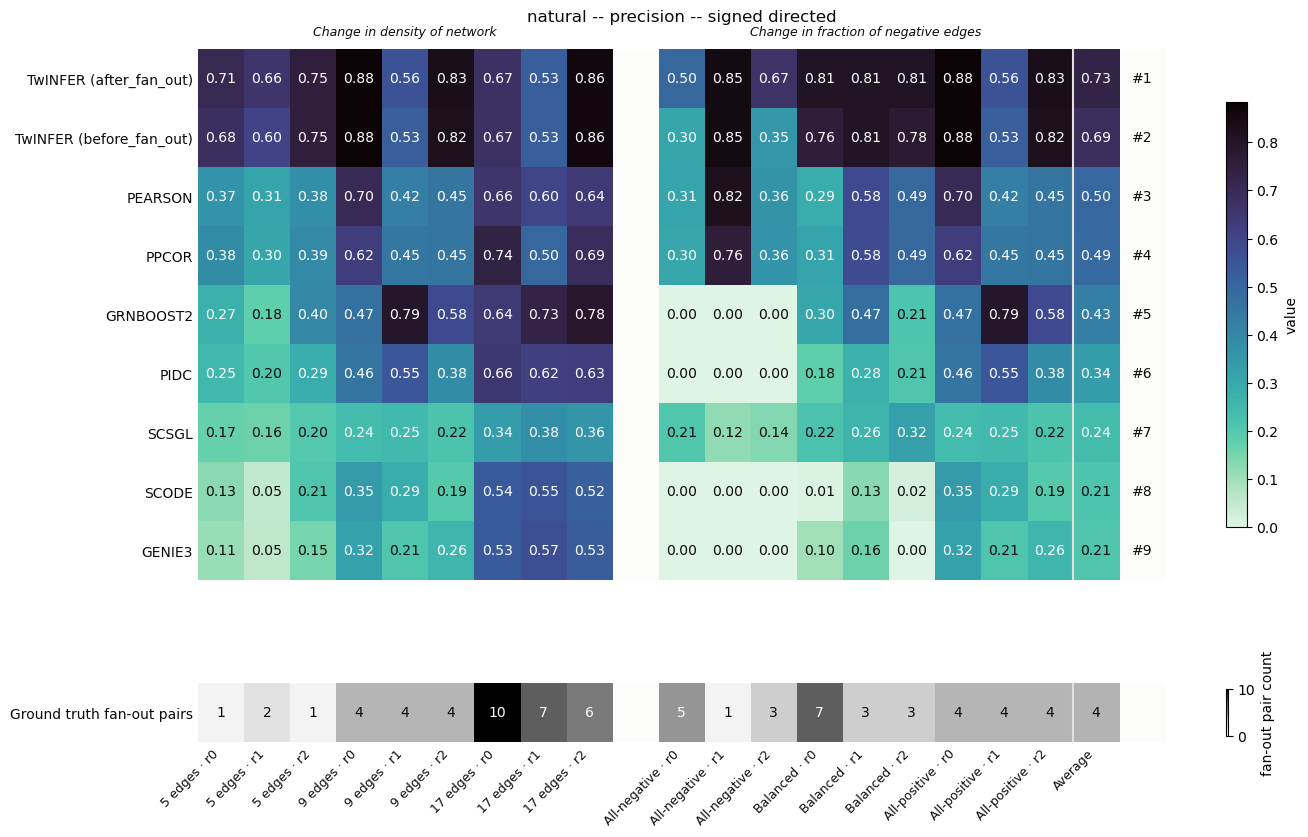

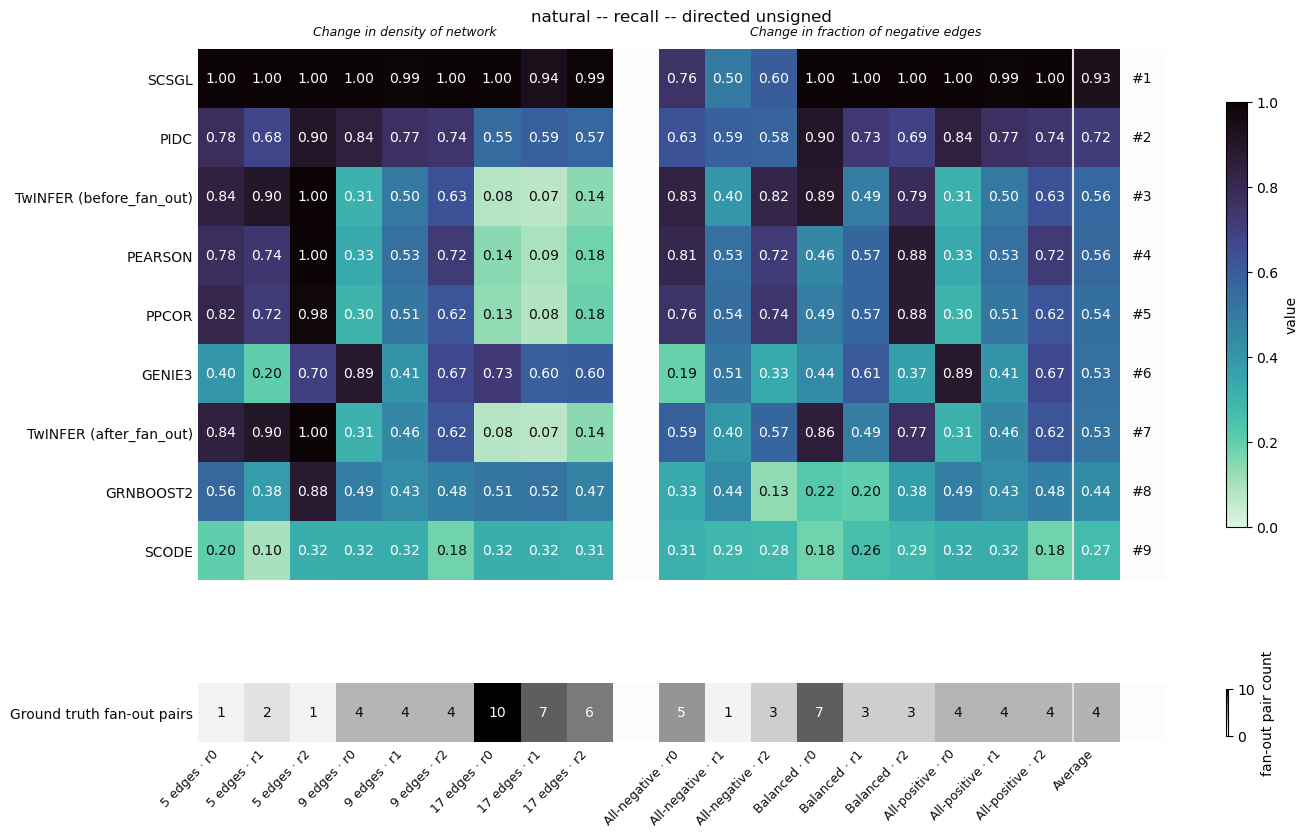

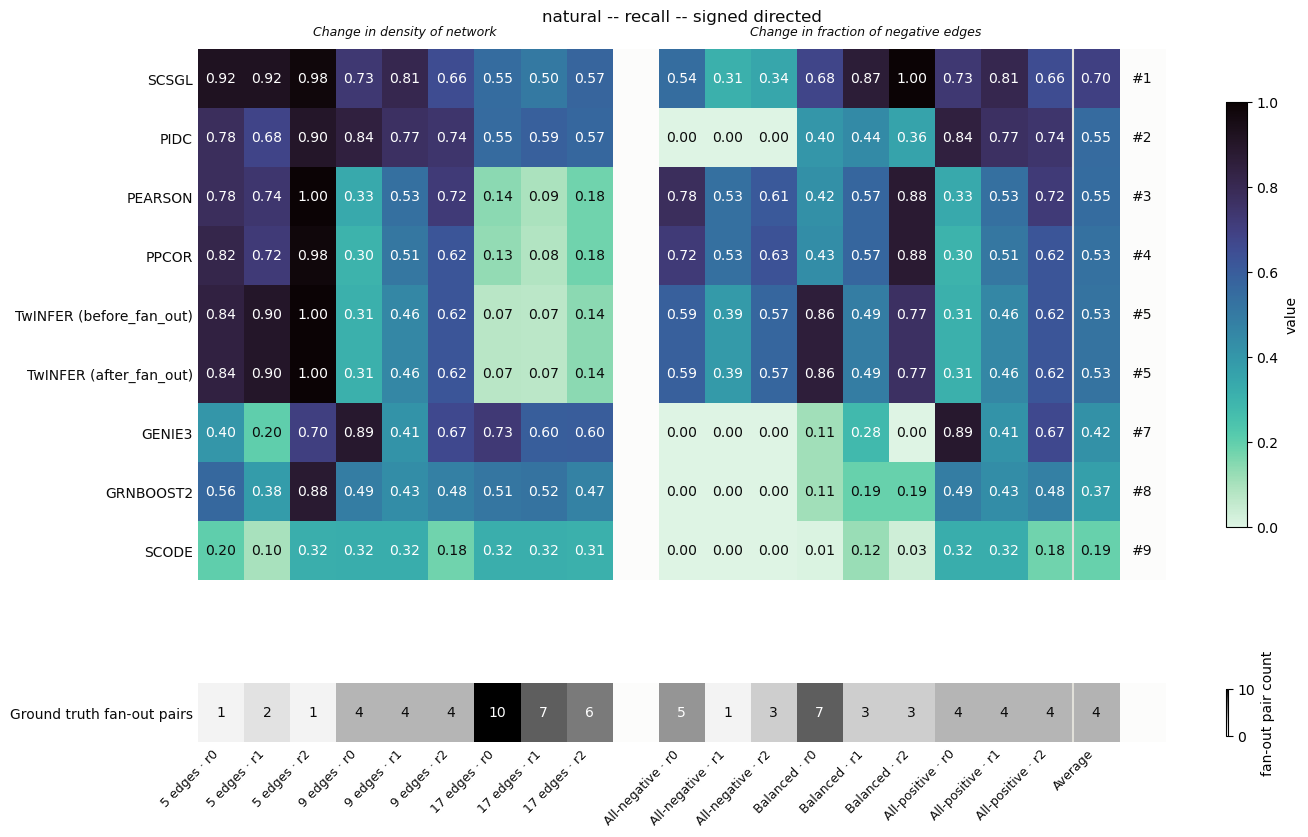

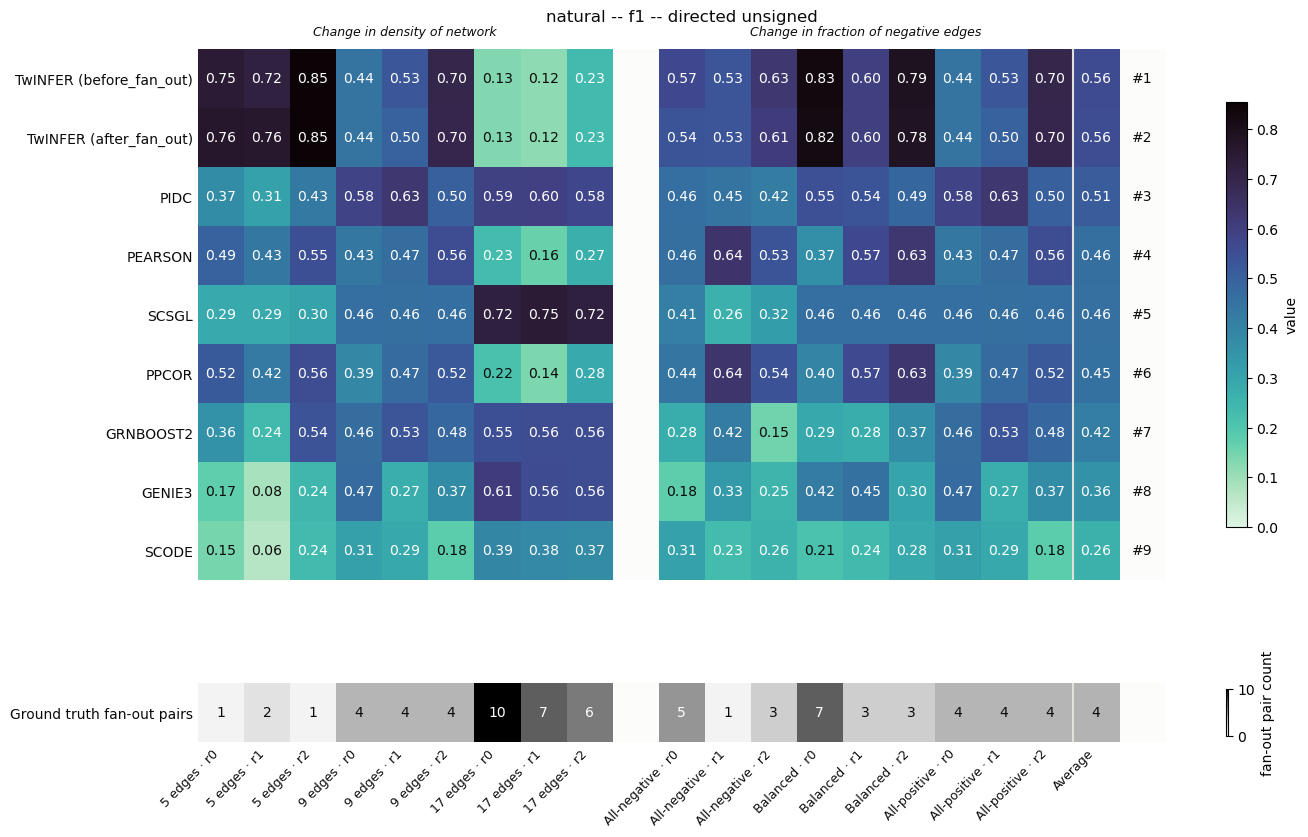

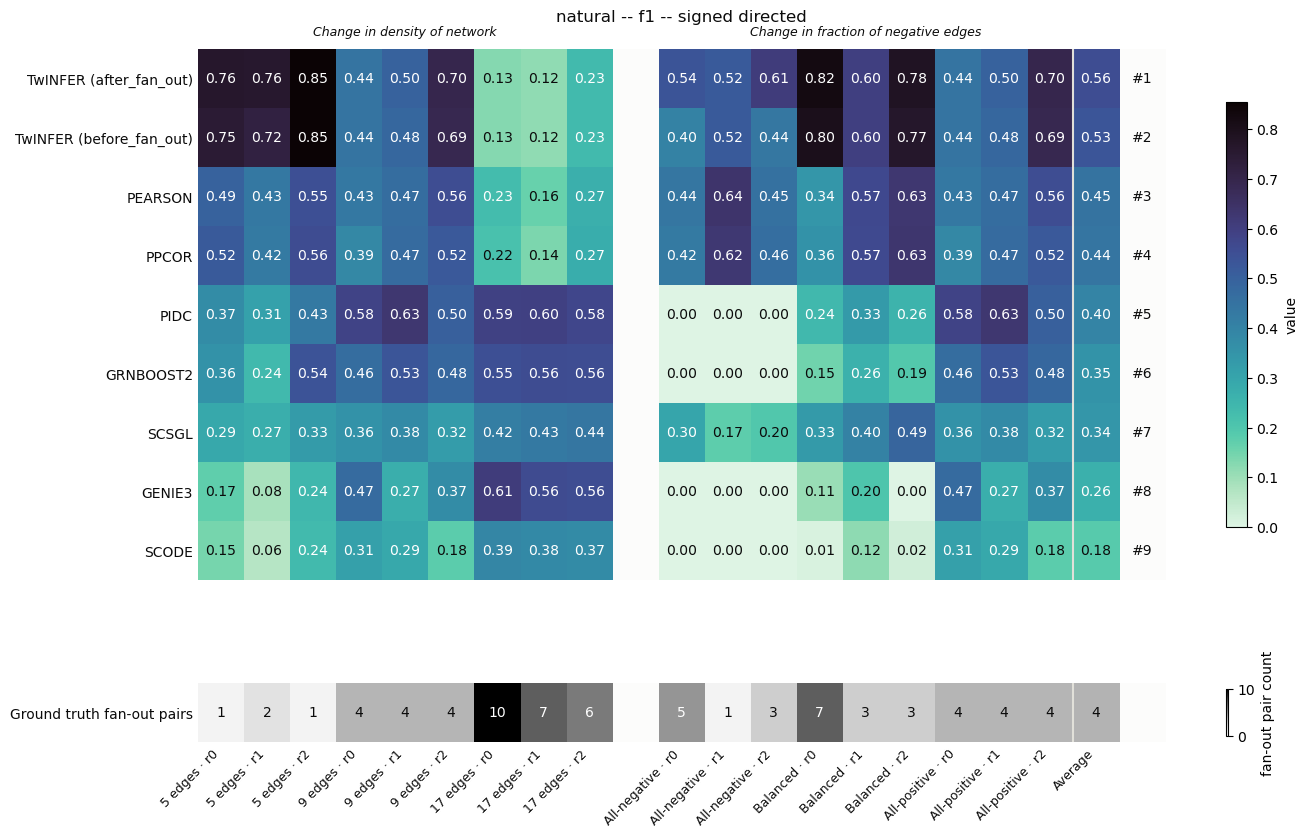

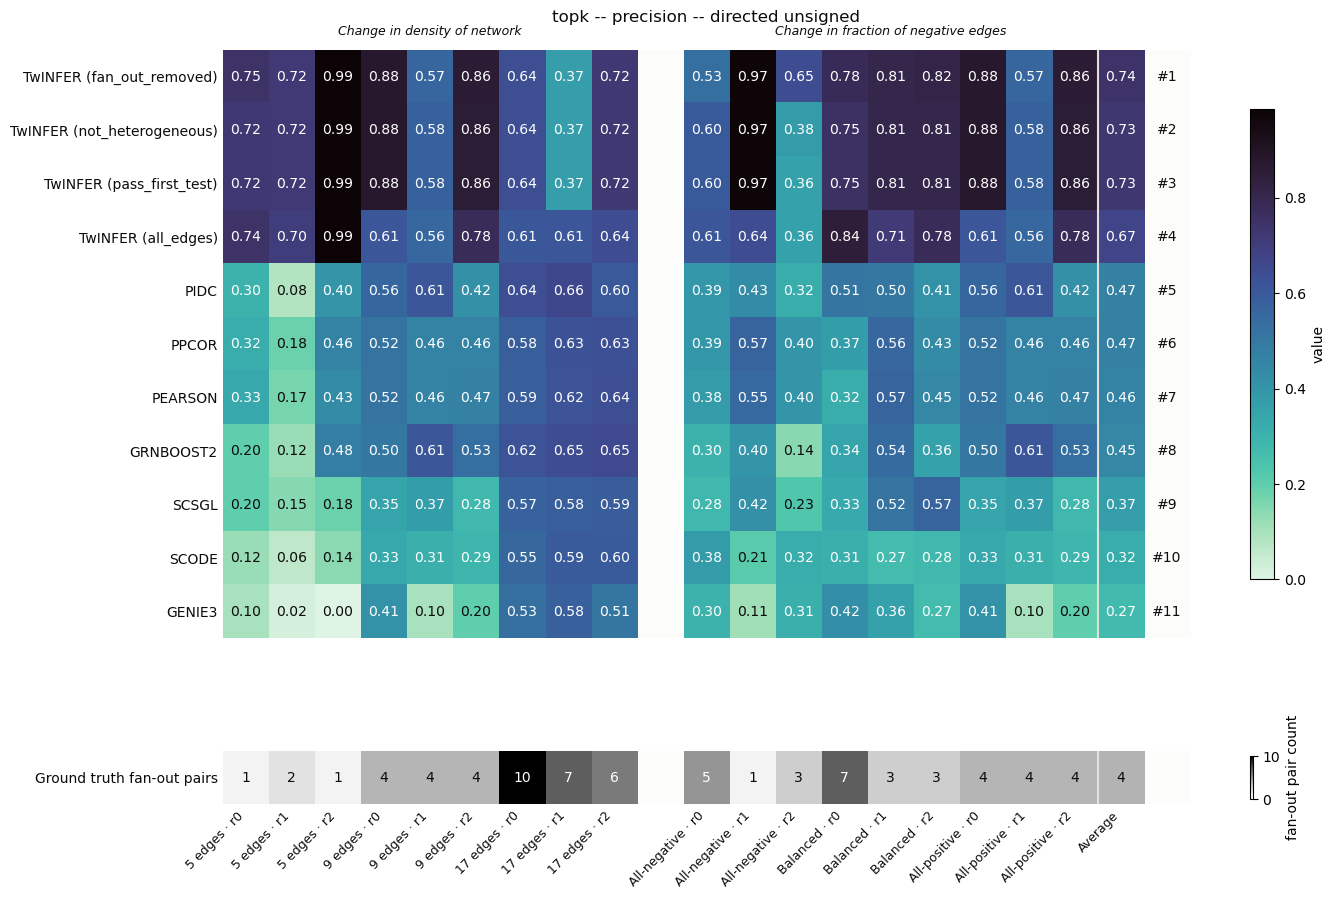

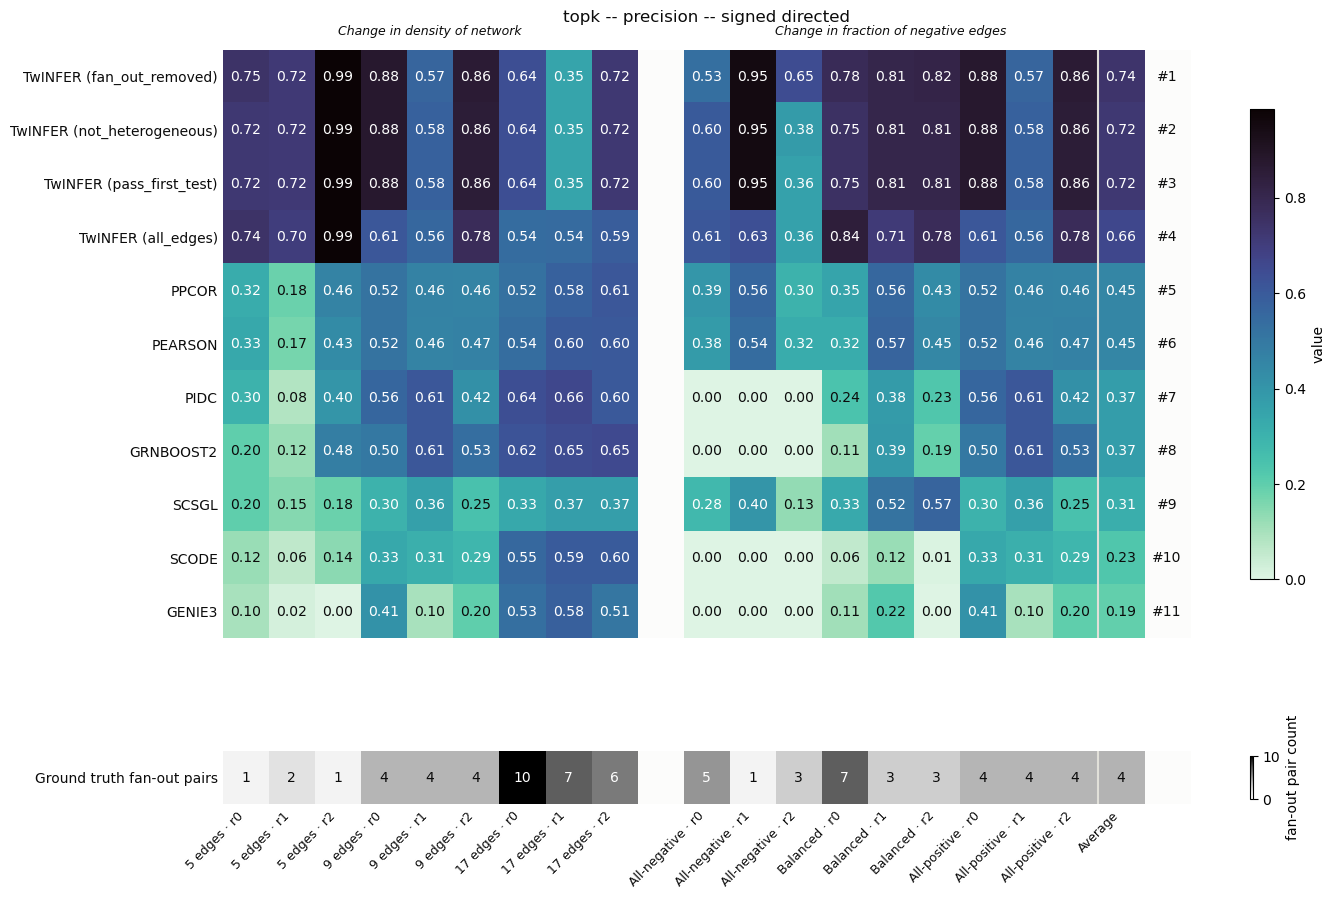

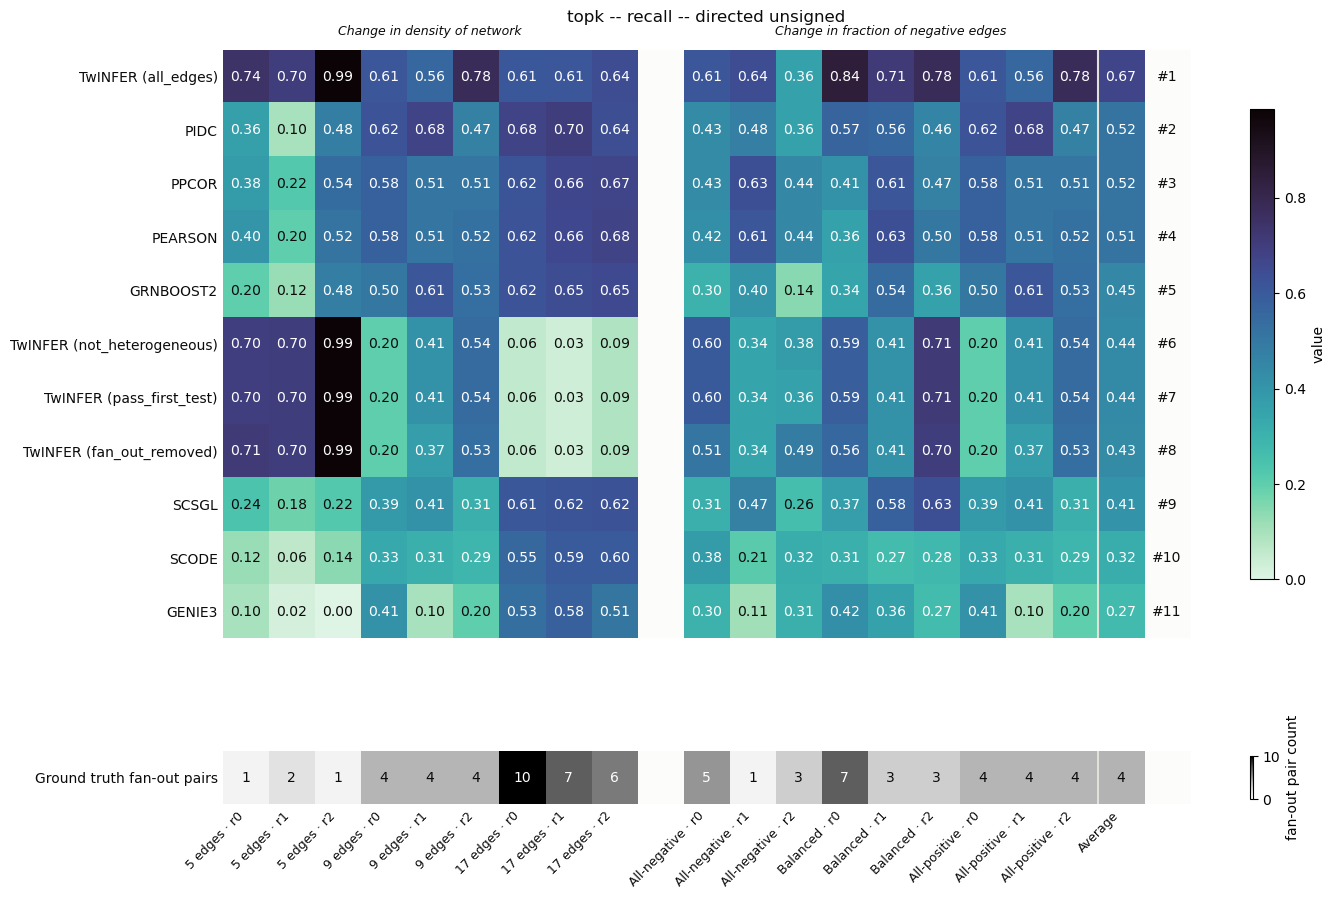

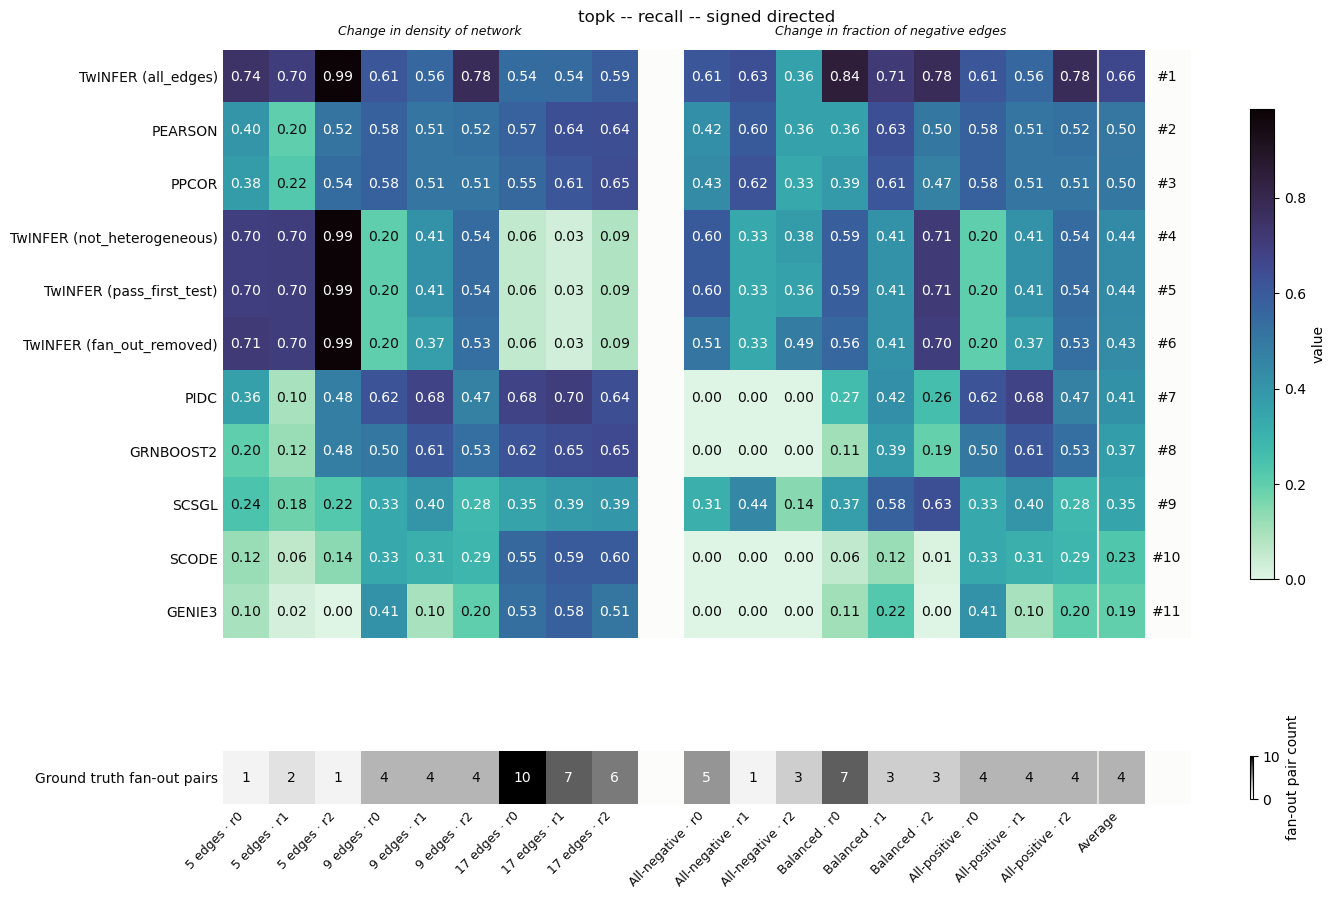

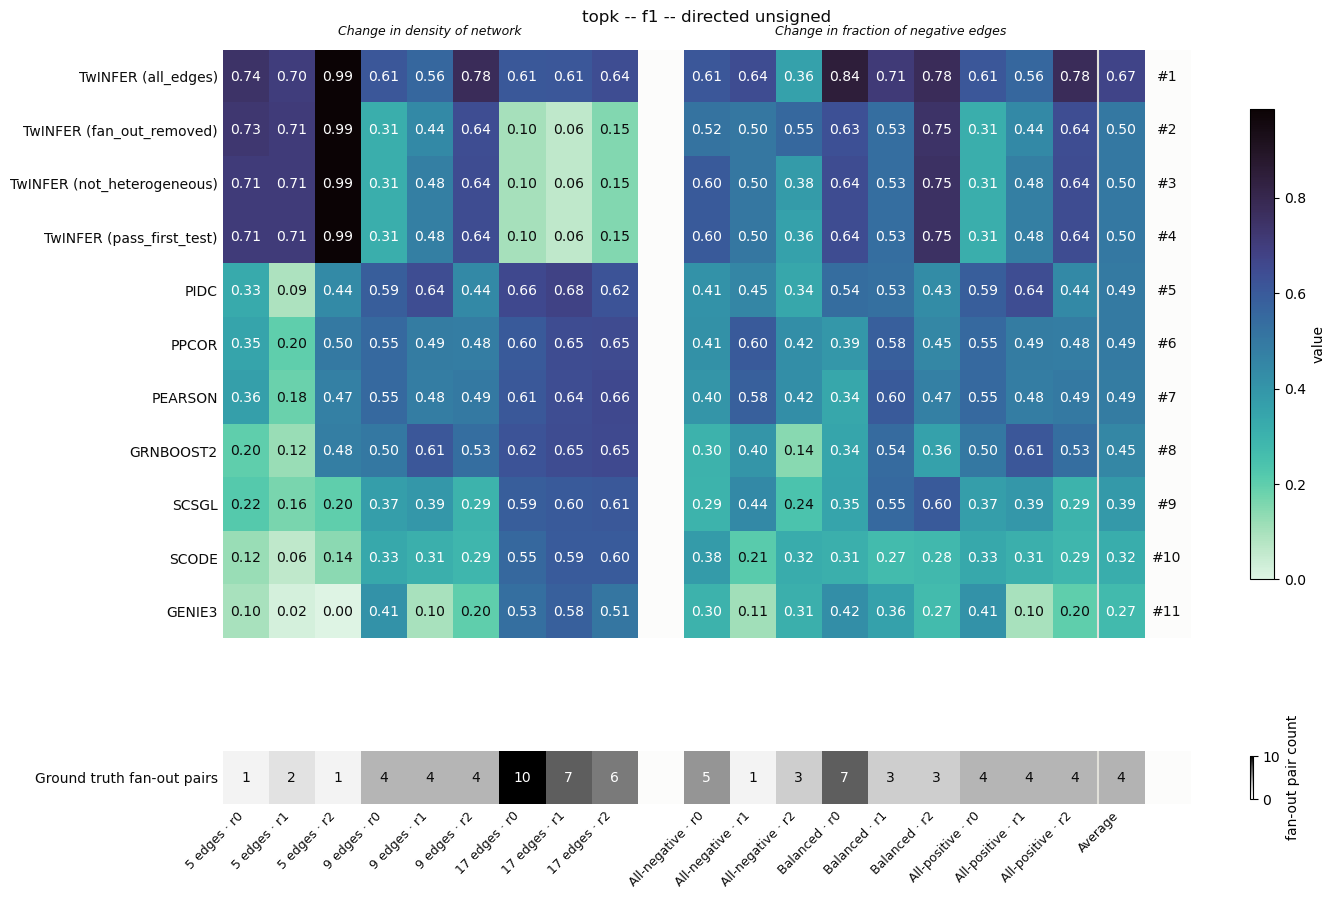

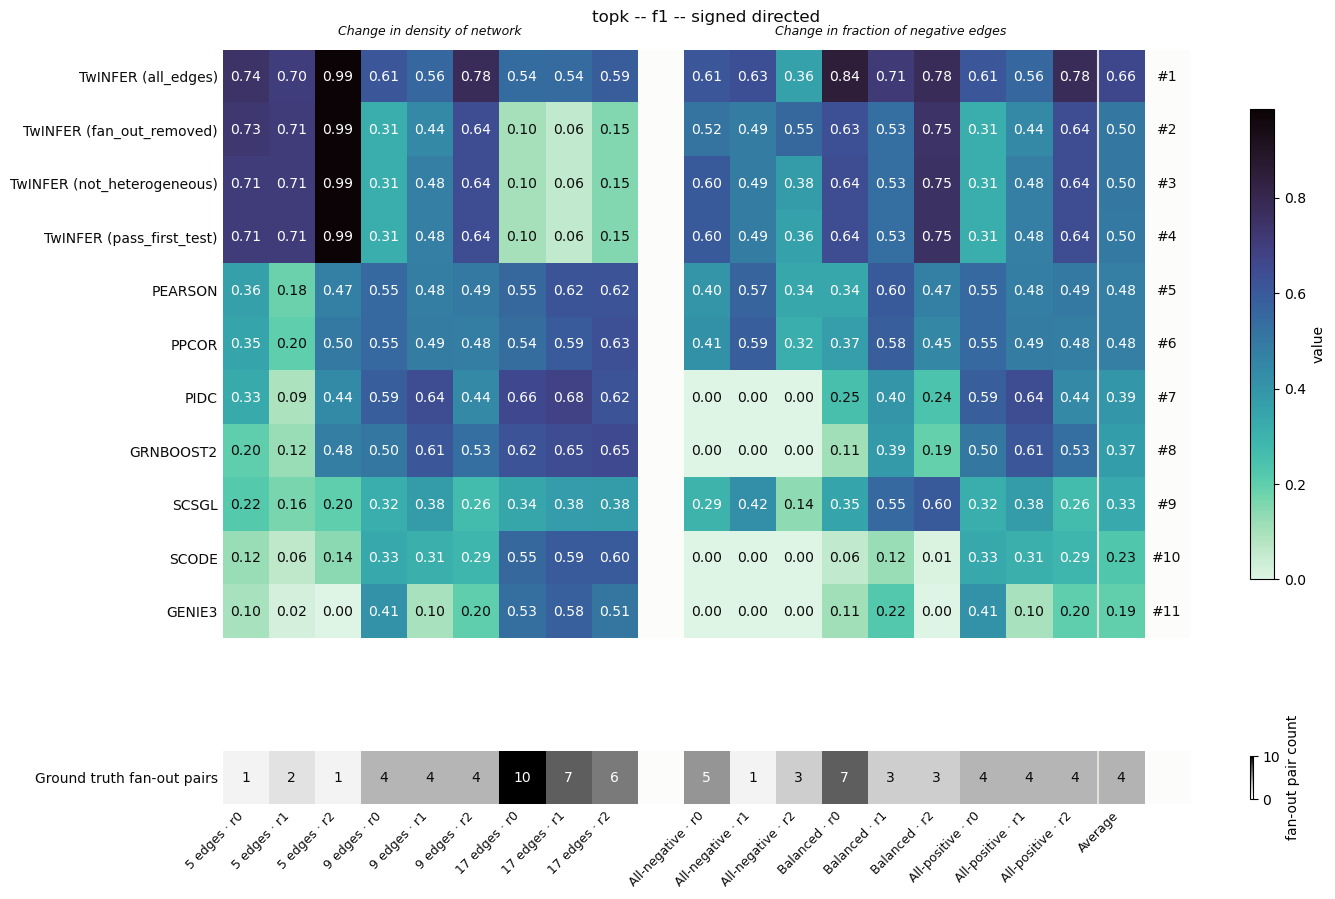

In [30]:
METRIC_FAMILIES = {
    "auprc": ["auprc"],
    "natural": ["precision", "recall", "f1"],
    "topk": ["precision", "recall", "f1"],
}
VARIANTS = ["directed_unsigned", "signed_directed"]
SCHEMES = ["twin_paired"]

for metric_family, score_names in METRIC_FAMILIES.items():
    for score_name in score_names:
        for variant in VARIANTS:
            for scheme in SCHEMES:
                subset = scores_long[
                    (scores_long["metric_family"] == metric_family)
                    & (scores_long["score_name"] == score_name)
                    & (scores_long["variant"] == variant)
                    & ((scores_long["scheme"] == scheme) | (scores_long["method"] == "TwINFER")
                       | (scores_long["method"] == "Ground truth"))
                ]
                if subset.empty:
                    print("empty")
                    continue
                fig = plot_heatmap_with_fanout_row(
                    subset,
                    title=f"{metric_family} -- {score_name} -- {variant.replace('_', ' ')}",
                )
                if fig is not None:
                    plt.show()

## Cyclic network inference

In [31]:
import pandas as pd
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

tw = pd.read_csv('/home/gzu5140/TwINFER_KA/analysis_data/paper_analysis/cyclic_g3456/twinfer_analysis_output.csv')
bl = pd.read_csv('/home/gzu5140/TwINFER_KA/analysis_data/paper_analysis/cyclic_g3456/beeline_analysis_output.csv')

topologies = ['cyclic_g3','cyclic_g4','cyclic_g5','cyclic_g6']

# TwINFER natural (after_fan_out = the actual final decision), directed/unsigned
tw_nat = tw.groupby('dataset_id')[['precision_natural_after_fan_out','recall_natural_after_fan_out','f1_natural_after_fan_out']].mean()
tw_nat.columns = ['precision','recall','f1']
tw_nat.index.name = 'dataset_id'
tw_nat = tw_nat.reset_index()
tw_nat.insert(0, 'method', 'TwINFER')

# BEELINE natural, directed/unsigned
bl_nat = bl.groupby(['algorithm','dataset_id'])[['precision_natural','recall_natural','f1_natural']].mean().reset_index()
bl_nat.columns = ['method','dataset_id','precision','recall','f1']

combined = pd.concat([tw_nat, bl_nat], ignore_index=True)

for metric in ['precision','recall','f1']:
    print(f'=== Natural-threshold {metric} (directed/unsigned) ===')
    piv = combined.pivot(index='method', columns='dataset_id', values=metric)[topologies]
    print(piv.round(3))
    print()

=== Natural-threshold precision (directed/unsigned) ===
dataset_id  cyclic_g3  cyclic_g4  cyclic_g5  cyclic_g6
method                                                
GENIE3          0.503      0.183      0.036      0.038
GRNBOOST2       0.530      0.470      0.484      0.444
PEARSON         0.500      0.479      0.468      0.474
PIDC            0.500      0.470      0.377      0.317
PPCOR           0.500      0.490      0.479      0.492
SCODE           0.458      0.285      0.209      0.209
SCSGL           0.500      0.297      0.279      0.181
TwINFER         0.833      0.844      0.851      0.891

=== Natural-threshold recall (directed/unsigned) ===
dataset_id  cyclic_g3  cyclic_g4  cyclic_g5  cyclic_g6
method                                                
GENIE3          0.517      0.325       0.09      0.142
GRNBOOST2       0.467      0.738       0.86      0.883
PEARSON         0.983      0.962       0.98      0.950
PIDC            0.667      0.725       0.90      0.783
PPCOR     

## Part 7 -- Cyclic benchmark (g3-g6)

Benchmarks TwINFER and the 7 BEELINE methods on simple directed cycles (gene_1 -> gene_2
-> ... -> gene_n -> gene_1, n=3,4,5,6): `cyclic_g3`/`cyclic_g4`/`cyclic_g5` freshly
simulated via `cyclic_g3_g4_g5_sim.py`; `cyclic_g6` reuses the older `cyclic_6_nodes`
simulation run (pre-dating that driver script) through the same modern
conversion/inference/scoring pipeline for a consistent comparison, rather than the older
`cycle_6_node` benchmark that already exists elsewhere. TwINFER inference, BEELINE
conversion (`twinfer_to_boolode_format.py`), the BEELINE runs
(`generate_cyclic_g3456_configs.py` + `run_real_networks_chunk.sh`), and scoring
(`score_cyclic_g3456.py`) were all run ahead of time; this section loads the resulting
CSVs and visualizes them, reusing the melt/heatmap machinery from Parts 5-6 above plus
`plot_grn.py` for the network diagrams.

In [32]:
CYCLIC_TWINFER_SCORES_CSV = "/home/gzu5140/TwINFER_KA/analysis_data/paper_analysis/cyclic_g3456/twinfer_analysis_output.csv"
CYCLIC_BEELINE_SCORES_CSV = "/home/gzu5140/TwINFER_KA/analysis_data/paper_analysis/cyclic_g3456/beeline_analysis_output.csv"

cyclic_twinfer_df = pd.read_csv(CYCLIC_TWINFER_SCORES_CSV)
cyclic_beeline_df = pd.read_csv(CYCLIC_BEELINE_SCORES_CSV)

cyclic_scores_long = pd.concat(
    [melt_twinfer_wide(cyclic_twinfer_df), melt_beeline_wide(cyclic_beeline_df)],
    ignore_index=True,
)
cyclic_scores_long["method_label"] = cyclic_scores_long.apply(_method_row_label, axis=1)
print(f"cyclic_scores_long: {len(cyclic_scores_long)} rows, "
      f"methods = {sorted(cyclic_scores_long['method'].unique())}, "
      f"topologies = {sorted(cyclic_twinfer_df['dataset_id'].unique())}")
cyclic_scores_long.head()

cyclic_scores_long: 14040 rows, methods = ['GENIE3', 'GRNBOOST2', 'PEARSON', 'PIDC', 'PPCOR', 'SCODE', 'SCSGL', 'TwINFER'], topologies = ['cyclic_g3', 'cyclic_g4', 'cyclic_g5', 'cyclic_g6']


,method,dataset_id,scheme,pool,metric_family,variant,score_name,value,method_label
0,TwINFER,cyclic_g3,twinfer,n/a,auprc,directed_unsigned,auprc,1.0,TwINFER
1,TwINFER,cyclic_g3,twinfer,before_fan_out,natural,directed_unsigned,precision,1.0,TwINFER (before_fan_out)
2,TwINFER,cyclic_g3,twinfer,before_fan_out,natural,directed_unsigned,recall,1.0,TwINFER (before_fan_out)
3,TwINFER,cyclic_g3,twinfer,before_fan_out,natural,directed_unsigned,f1,1.0,TwINFER (before_fan_out)
4,TwINFER,cyclic_g3,twinfer,after_fan_out,natural,directed_unsigned,precision,1.0,TwINFER (after_fan_out)


In [33]:
CYCLIC_TOPOLOGY_ORDER = ["cyclic_g3", "cyclic_g4", "cyclic_g5", "cyclic_g6"]
CYCLIC_TOPOLOGY_LABELS = {"cyclic_g3": "g3", "cyclic_g4": "g4", "cyclic_g5": "g5", "cyclic_g6": "g6"}


def plot_heatmap_cyclic(subset, value_col="value", title=None):
    """
    Simpler counterpart to plot_heatmap_by_method_dataset for the cyclic_g3456 family --
    no density/sign_ratio column grouping (dataset_column_slots only understands
    network_sweep_final's grn_n*_e*_pos*_density/sign_ratio_rep* naming), just the 4
    topologies in gene-count order, plus Average and Rank. Same visual style (colormap,
    ink/gridline colors, row sorting by descending average) as the main heatmaps above.
    """
    present = [d for d in CYCLIC_TOPOLOGY_ORDER if d in subset["dataset_id"].unique()]
    if not present:
        return None

    pivot = subset.groupby(["method_label", "dataset_id"])[value_col].mean().unstack("dataset_id")
    pivot = pivot.reindex(columns=present)

    row_avg = pivot.mean(axis=1)
    row_rank = row_avg.rank(ascending=False, method="min").astype(int)
    pivot = pivot.loc[row_avg.sort_values(ascending=False).index]
    row_avg = row_avg.loc[pivot.index]
    row_rank = row_rank.loc[pivot.index]

    n_cols = pivot.shape[1]
    fig, ax = plt.subplots(figsize=(0.9 * (n_cols + 2) + 3, 0.4 * len(pivot.index) + 4))

    finite_vals = pivot.values[~pd.isna(pivot.values)]
    vmax = float(finite_vals.max()) if finite_vals.size else 1.0
    norm = Normalize(vmin=0.0, vmax=max(vmax, 1e-9))

    grid = np.hstack([
        pivot.values,
        row_avg.values.reshape(-1, 1),
        np.full((len(pivot), 1), np.nan),
    ])

    display_cmap = HEATMAP_CMAP.copy()
    display_cmap.set_bad(HEATMAP_SURFACE)
    im = ax.imshow(grid, cmap=display_cmap, aspect="auto", norm=norm)

    for i in range(grid.shape[0]):
        for j in range(n_cols + 1):
            val = grid[i, j]
            if pd.isna(val):
                continue
            label_color = _label_color_for(val, norm, HEATMAP_CMAP)
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=label_color)
        ax.text(n_cols + 1, i, f"#{row_rank.iloc[i]}", ha="center", va="center",
                 fontsize=10, color=INK_PRIMARY)

    ax.axvline(n_cols - 0.5, color=GRIDLINE, linewidth=1.5)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels(
        [CYCLIC_TOPOLOGY_LABELS[d] for d in pivot.columns] + ["Average", "Rank"],
        rotation=45, ha="right", color=INK_PRIMARY, fontsize=9,
    )
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=INK_PRIMARY, fontsize=10)
    ax.set_title(title or "", color=INK_PRIMARY, fontsize=13, pad=20)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    fig.colorbar(im, ax=ax, shrink=0.8, label=value_col)
    fig.tight_layout()
    return fig

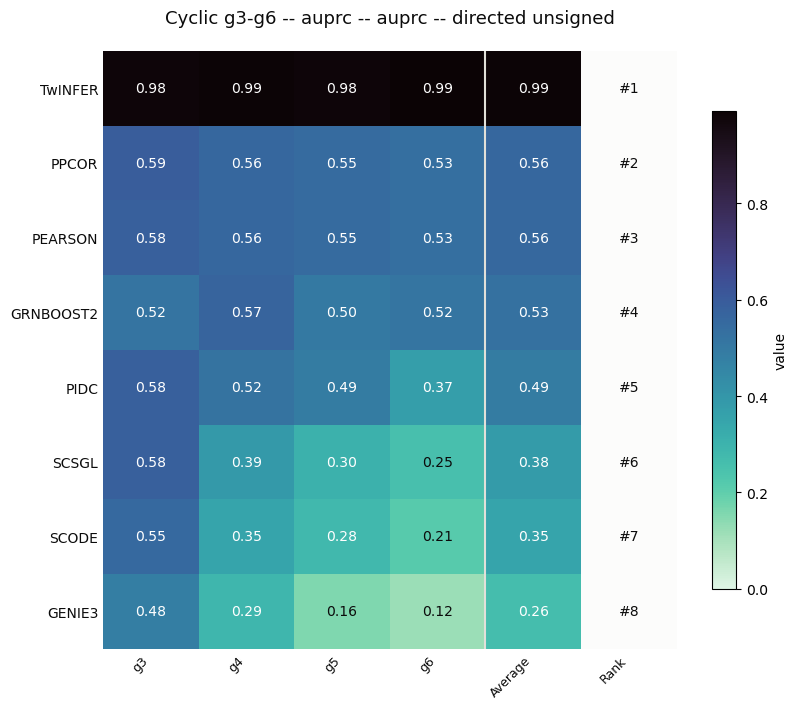

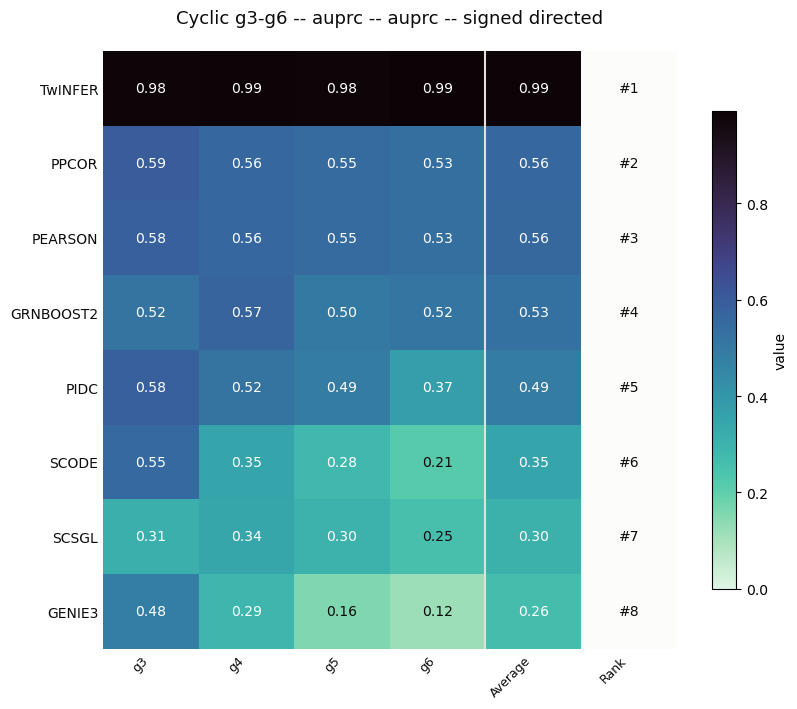

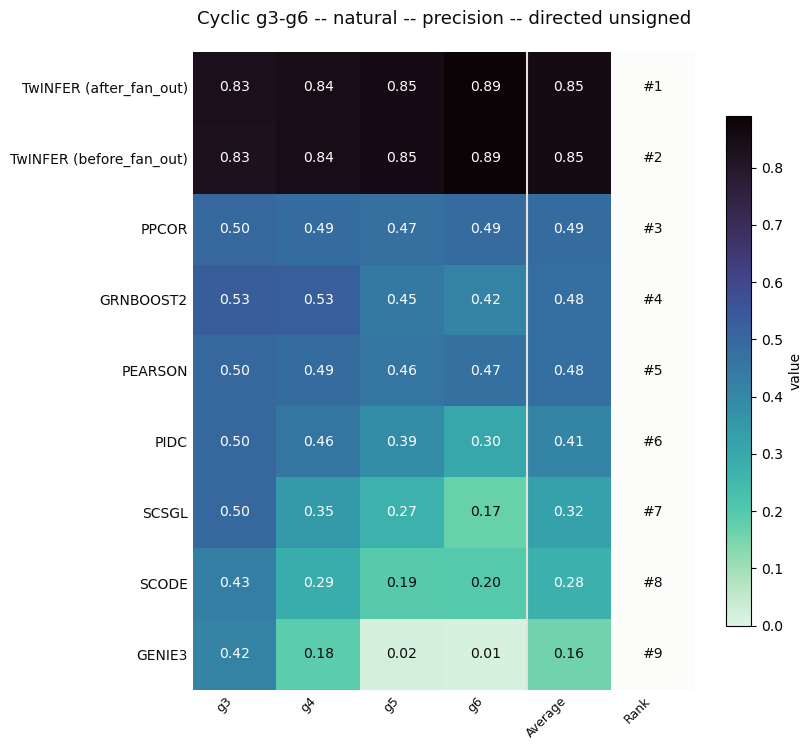

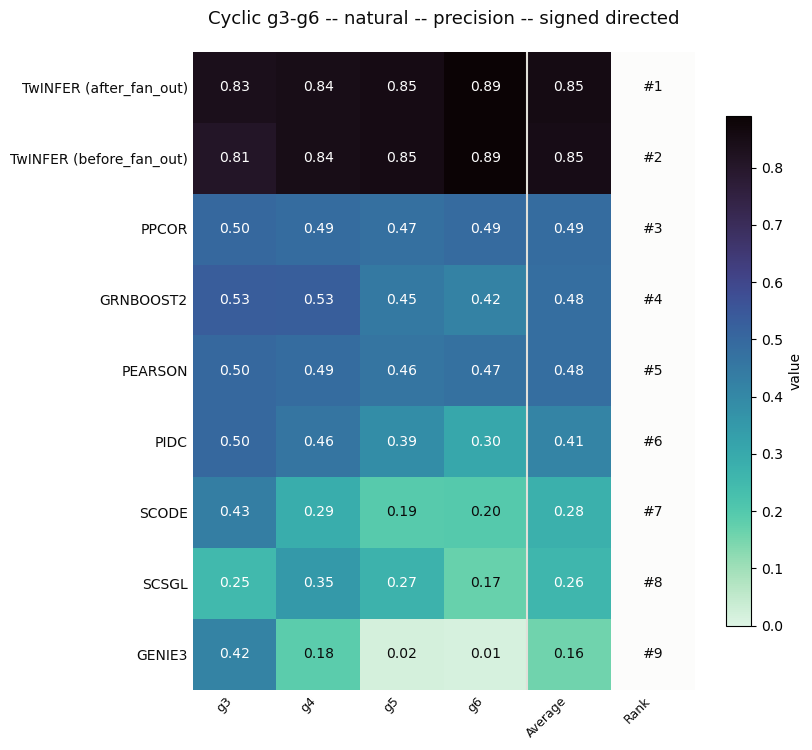

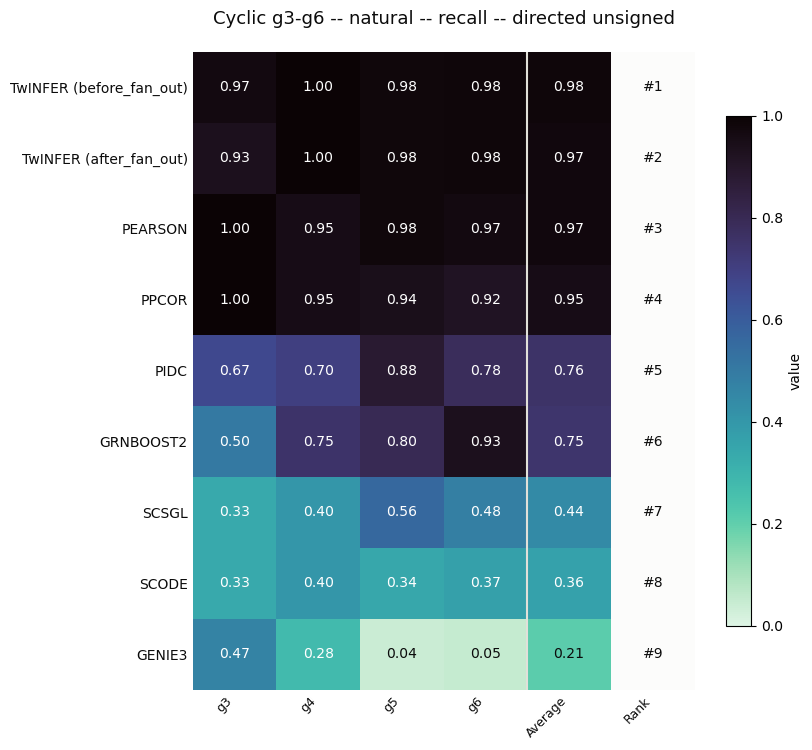

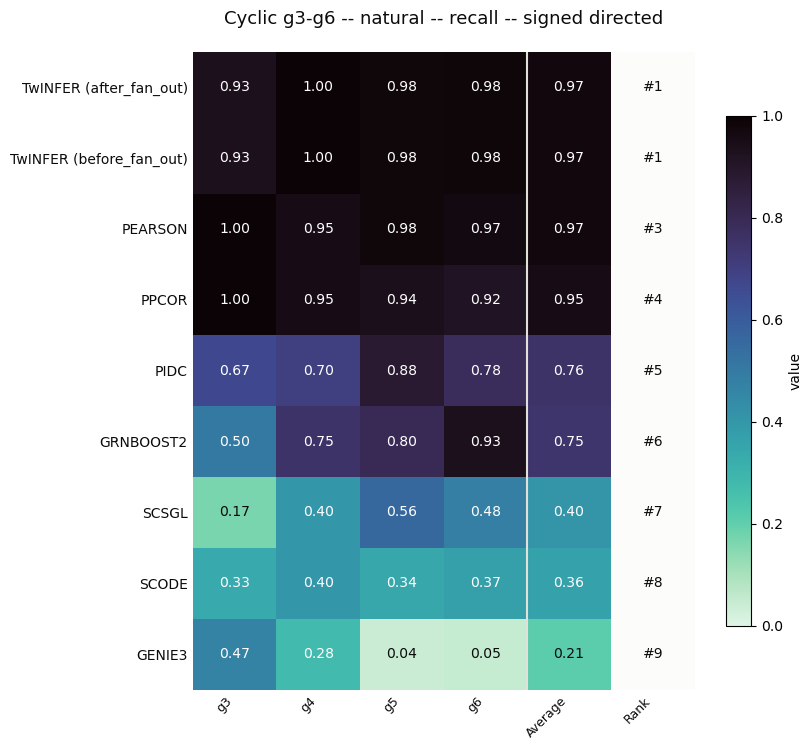

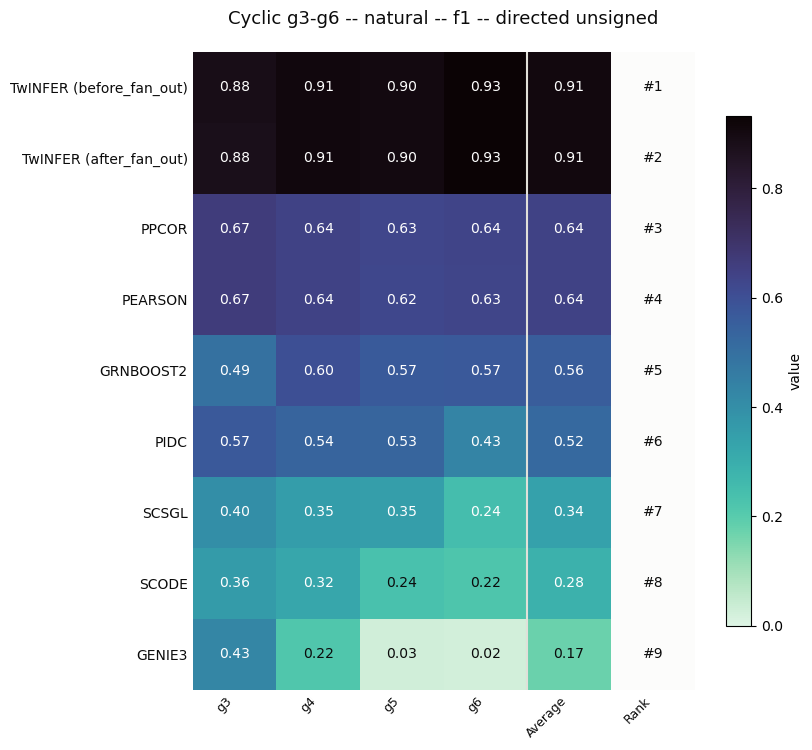

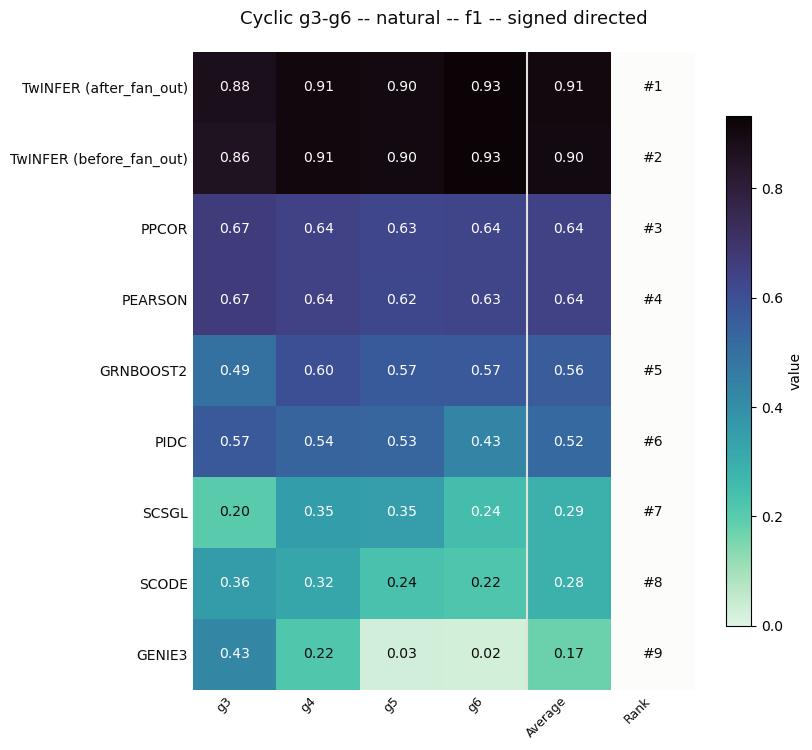

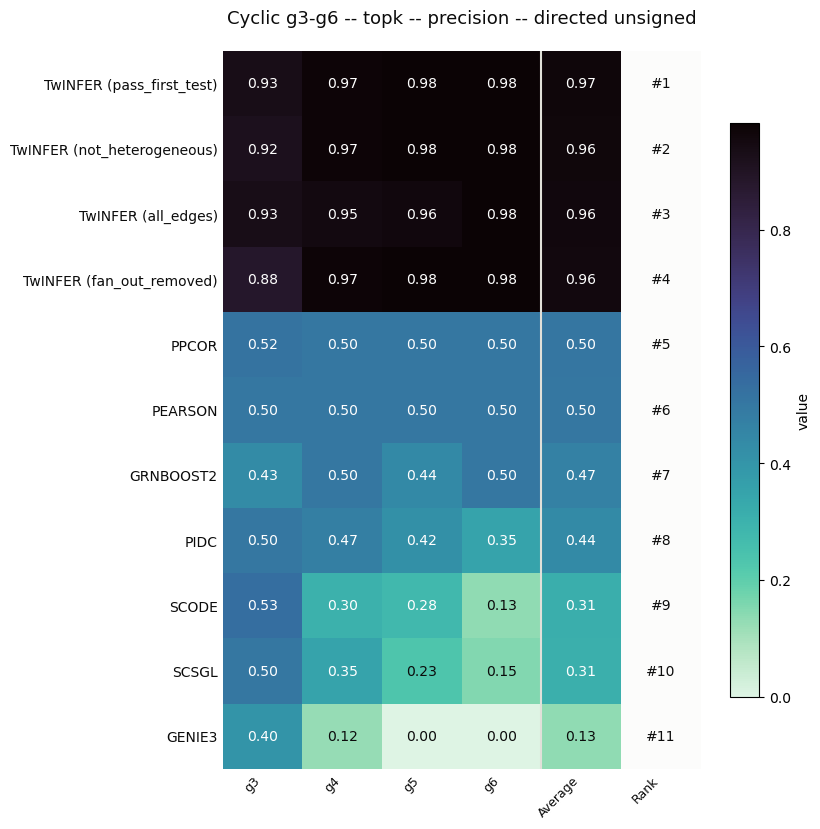

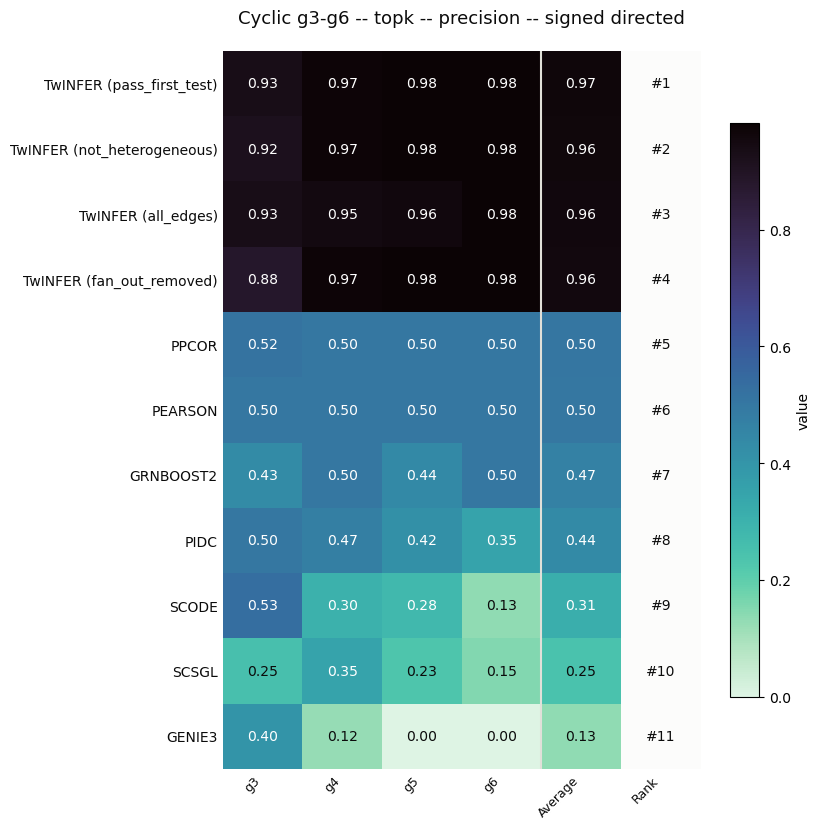

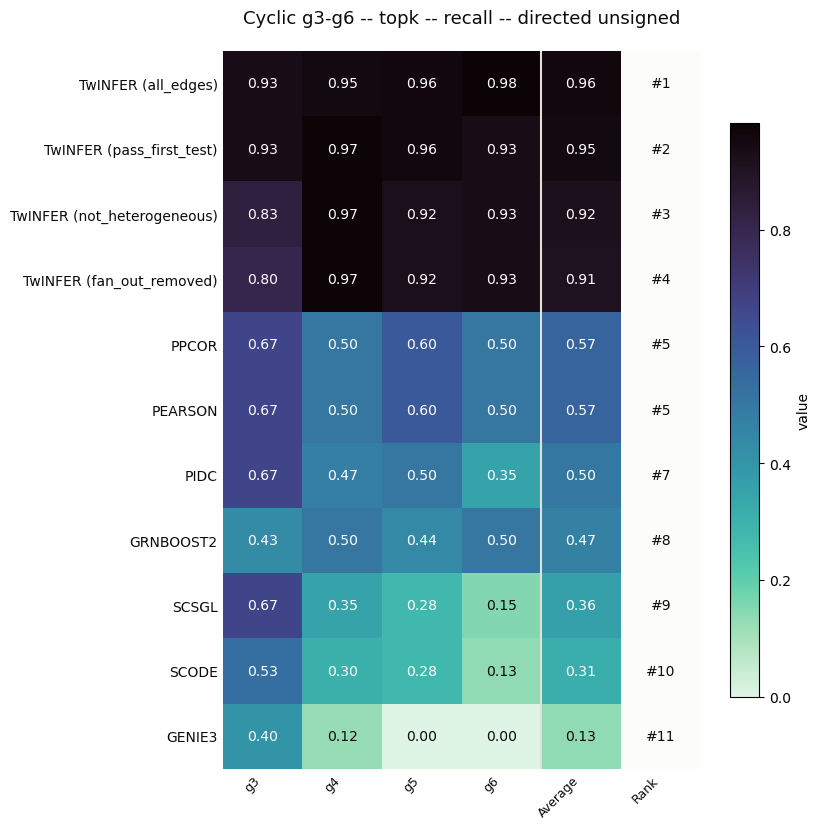

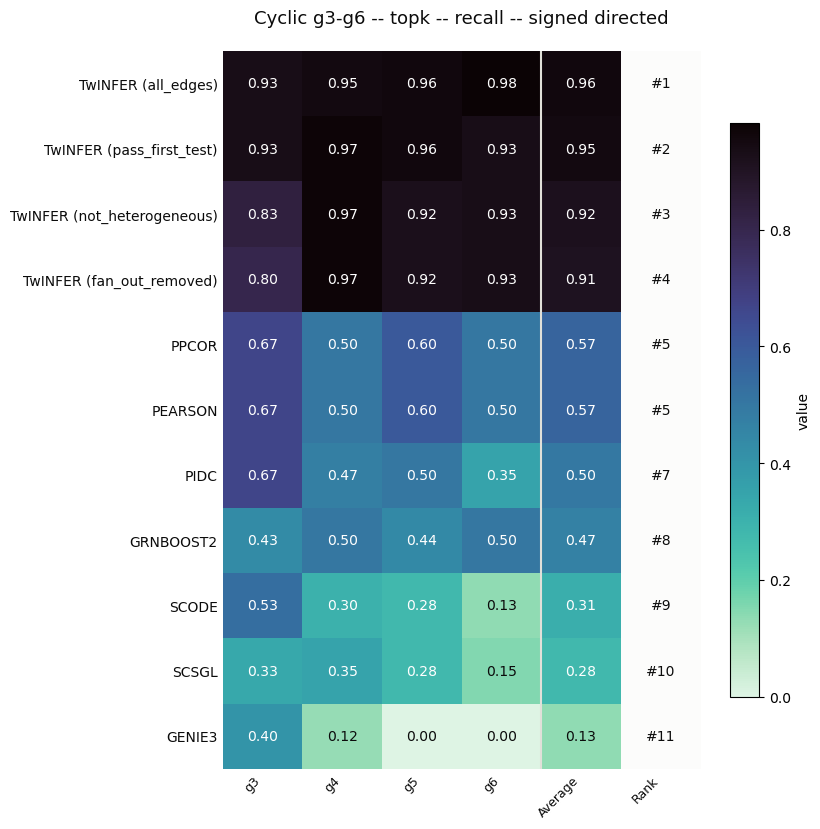

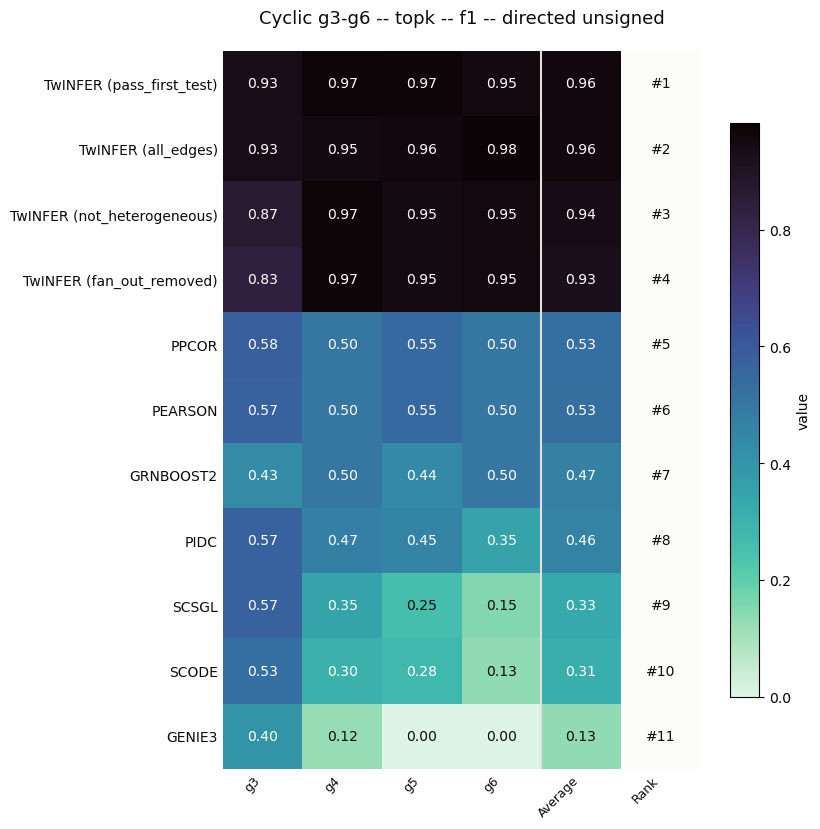

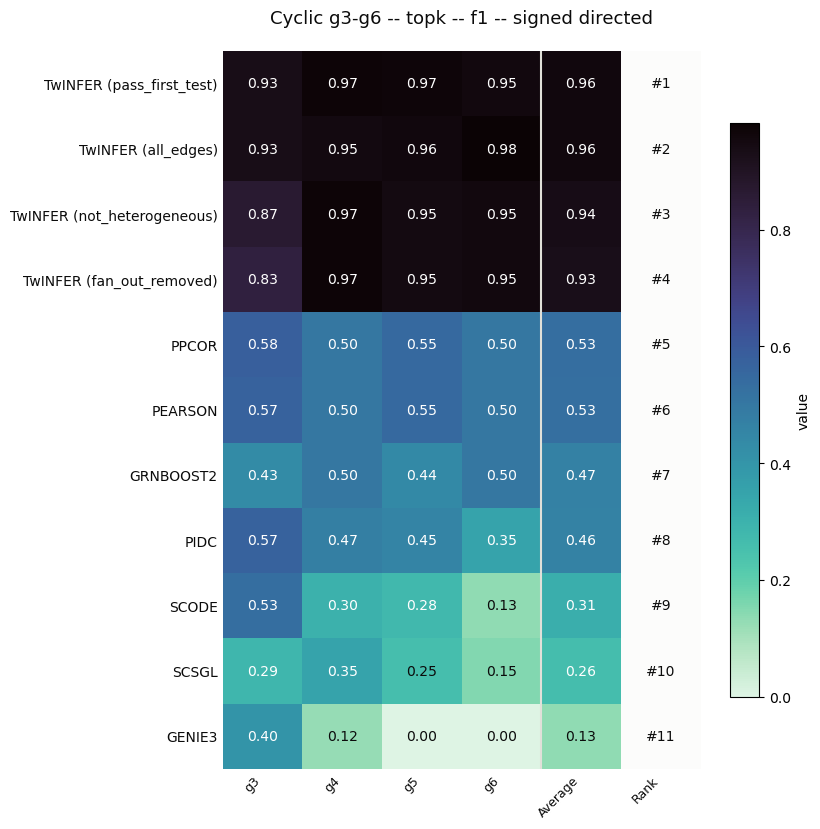

In [34]:
CYCLIC_METRIC_FAMILIES = {
    "auprc": ["auprc"],
    "natural": ["precision", "recall", "f1"],
    "topk": ["precision", "recall", "f1"],
}
CYCLIC_VARIANTS = ["directed_unsigned", "signed_directed"]
CYCLIC_SCHEMES = ["twin_paired"]

for metric_family, score_names in CYCLIC_METRIC_FAMILIES.items():
    for score_name in score_names:
        for variant in CYCLIC_VARIANTS:
            for scheme in CYCLIC_SCHEMES:
                subset = cyclic_scores_long[
                    (cyclic_scores_long["metric_family"] == metric_family)
                    & (cyclic_scores_long["score_name"] == score_name)
                    & (cyclic_scores_long["variant"] == variant)
                    & ((cyclic_scores_long["scheme"] == scheme) | (cyclic_scores_long["method"] == "TwINFER"))
                ]
                if subset.empty:
                    continue
                fig = plot_heatmap_cyclic(
                    subset,
                    title=f"Cyclic g3-g6 -- {metric_family} -- {score_name} -- {variant.replace('_', ' ')}",
                )
                if fig is not None:
                    plt.show()

### Ground truth + best-F2 representative inferred networks (g3-g6)

For each topology, the true cycle plus, for TwINFER and all 7 BEELINE methods, the
single run whose natural-threshold, directed/unsigned F2 score
(`5*precision*recall / (4*precision+recall)` -- weights recall over precision, since the
natural threshold's failure mode here tends to be too conservative rather than too
permissive) is highest among that method's runs for that topology (TwINFER: 10 reps;
BEELINE: 10 reps x 2 schemes = 20 runs) -- the actual predicted edge set for that
specific run is reconstructed and drawn with `plot_grn`, not just its score, so what you
see is a genuine inferred network rather than an idealized one. 9 networks (ground truth
+ 8 methods) x 4 topologies = 36 panels total.

In [35]:
import sys
_SNA_DIR = "/home/gzu5140/TwINFER_KA/code/TwINFER/synthetic_network_analysis"
if _SNA_DIR not in sys.path:
    sys.path.append(_SNA_DIR)
from plot_grn import plot_grn
import score_cyclic_g3456 as cyclic_scoring

CYCLIC_METHOD_ORDER = ["TwINFER", "PIDC", "GENIE3", "GRNBOOST2", "PPCOR", "SCODE", "SCSGL", "PEARSON"]


def f2_score(precision, recall):
    denom = 4 * precision + recall
    if denom == 0:
        return 0.0
    return 5 * precision * recall / denom


def best_twinfer_run(dataset_id):
    """rep_id of the cyclic_twinfer_df row with the highest natural (after_fan_out,
    directed/unsigned) F2 for this topology."""
    sub = cyclic_twinfer_df[cyclic_twinfer_df["dataset_id"] == dataset_id].copy()
    sub["f2"] = sub.apply(lambda r: f2_score(r["precision_natural_after_fan_out"], r["recall_natural_after_fan_out"]), axis=1)
    best = sub.sort_values("f2", ascending=False).iloc[0]
    return best["rep_id"], best["f2"]


def best_beeline_run(dataset_id, algorithm):
    """run_id of the cyclic_beeline_df row with the highest natural (directed/unsigned) F2
    for this (topology, algorithm)."""
    sub = cyclic_beeline_df[
        (cyclic_beeline_df["dataset_id"] == dataset_id) & (cyclic_beeline_df["algorithm"] == algorithm)
    ].copy()
    sub["f2"] = sub.apply(lambda r: f2_score(r["precision_natural"], r["recall_natural"]), axis=1)
    best = sub.sort_values("f2", ascending=False).iloc[0]
    return best["run_id"], best["f2"]

In [36]:
def twinfer_predicted_matrix(dataset_id, rep_id, gene_names):
    """Signed n x n matrix (+-1) from a specific TwINFER rerun's actual final decision
    (after fan-out removal) -- the same edge set precision_natural_after_fan_out /
    recall_natural_after_fan_out were computed from."""
    json_path = cyclic_scoring.TWINFER_JSON_DIR / f"{dataset_id}_rep_{rep_id}_all_results.json"
    with open(json_path) as f:
        results = json.load(f)
    direction_matrix = reconstruct_matrix(results["direction_matrix"])
    n = len(gene_names)
    matrix = np.zeros((n, n))
    for gi, gj in results["final_directed_edges"]:
        if gi == gj:
            continue
        i, j = gene_names.index(gi), gene_names.index(gj)
        sign_val = direction_matrix.loc[gi, gj]
        matrix[i, j] = float(np.sign(sign_val)) if sign_val != 0 else 1.0
    return matrix


def beeline_predicted_matrix(dataset_id, run_id, algorithm, gene_names):
    """Signed n x n matrix (+-1) from a specific BEELINE run's natural-threshold
    selection -- native p-value for PPCOR/PEARSON, GMM crossover for everything else,
    reusing score_cyclic_g3456's own functions directly (not re-derived) so the plotted
    graph always matches the reported F2."""
    algo_dir = cyclic_scoring.BEELINE_OUTPUT_ROOT / dataset_id / run_id / algorithm
    ranked_edges = pd.read_csv(algo_dir / "rankedEdges.csv", sep="\t", header=0)
    predicted = cyclic_scoring.dedupe_predictions(ranked_edges)
    predicted_signed = cyclic_scoring.add_predicted_sign(predicted)

    native = cyclic_scoring.native_threshold_for_algorithm(algorithm, algo_dir, dataset_id, run_id, predicted_signed)
    if native is not None:
        selected_nat_signed = native[1]
    else:
        _, gmm_threshold, _ = cyclic_scoring.fit_gmm_threshold(predicted["_abs"].values)
        selected_nat_signed = cyclic_scoring.gmm_natural_threshold_selection_signed(predicted_signed, gmm_threshold)

    n = len(gene_names)
    matrix = np.zeros((n, n))
    for g1, g2, sign in selected_nat_signed:
        if g1 not in gene_names or g2 not in gene_names:
            continue
        i, j = gene_names.index(g1), gene_names.index(g2)
        matrix[i, j] = 1.0 if sign == "+" else -1.0
    return matrix

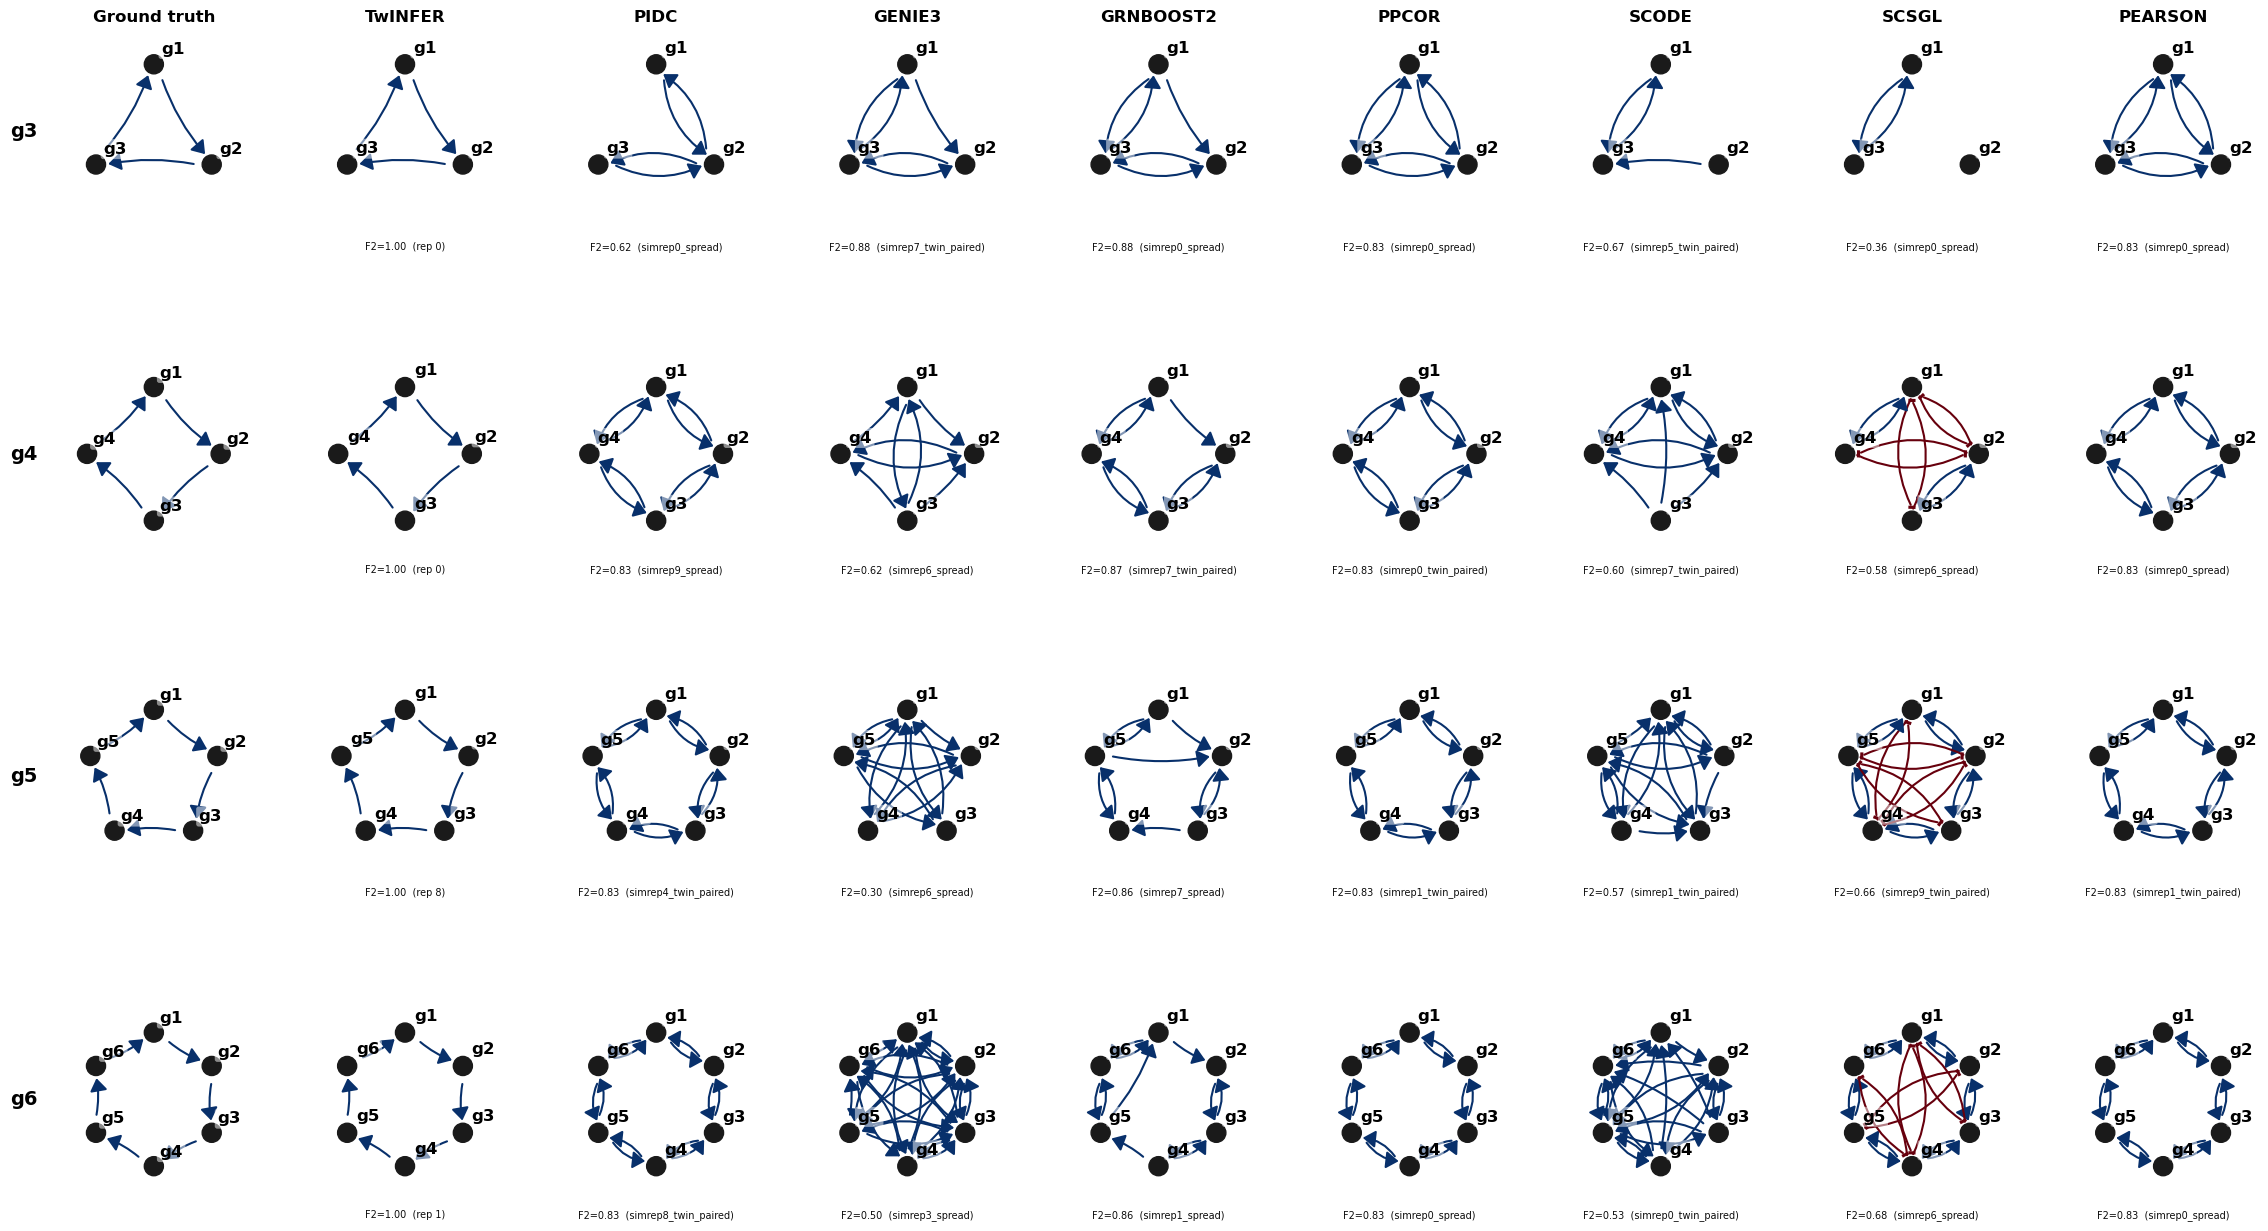

In [37]:
def circular_positions(n, radius=0.35, center=(0.5, 0.5), start_angle=np.pi / 2):
    """Fixed node positions arranged clockwise around a ring in gene_1..gene_n order,
    starting at the top -- used (instead of plot_grn's default community-based
    auto-layout) so every column in a topology's row places gene_i at the exact same
    (x, y), making panels directly comparable node-for-node, and so the true cycle
    itself actually reads as a ring rather than whatever layout Louvain community
    detection happens to produce."""
    angles = start_angle - 2 * np.pi * np.arange(n) / n
    return {i: np.array([center[0] + radius * np.cos(a), center[1] + radius * np.sin(a)]) for i, a in enumerate(angles)}


fig, axes = plt.subplots(
    len(CYCLIC_TOPOLOGY_ORDER), 1 + len(CYCLIC_METHOD_ORDER),
    figsize=(2.6 * (1 + len(CYCLIC_METHOD_ORDER)), 3.0 * len(CYCLIC_TOPOLOGY_ORDER)),
)
CYCLIC_COLUMN_LABELS = ["Ground truth"] + CYCLIC_METHOD_ORDER


def _plot_grn_no_colorbar(matrix, node_labels, ax, pos):
    """plot_grn always adds its own colorbar axis -- strip it back out here (rather than
    editing the shared plot_grn.py utility, which other notebooks also depend on) so 36
    colorbars don't crowd a 4x9 grid down to illegibility."""
    fig_local = ax.get_figure()
    n_axes_before = len(fig_local.axes)
    plot_grn(matrix, node_labels=node_labels, ax=ax, pos=pos)
    for extra_ax in fig_local.axes[n_axes_before:]:
        fig_local.delaxes(extra_ax)


for row, dataset_id in enumerate(CYCLIC_TOPOLOGY_ORDER):
    n_genes = int(dataset_id.replace("cyclic_g", ""))
    gene_names = [f"gene_{i+1}" for i in range(n_genes)]
    gt_matrix = load_ground_truth_matrix(f"/home/gzu5140/TwINFER_KA/input_data/cycle_g{n_genes}.txt", gene_names).to_numpy()
    plot_labels = [g.replace("gene_", "g") for g in gene_names]
    row_pos = circular_positions(n_genes)  # same fixed layout for every column in this row

    ax_gt = axes[row, 0]
    _plot_grn_no_colorbar(gt_matrix, plot_labels, ax_gt, row_pos)
    ax_gt.set_ylabel(CYCLIC_TOPOLOGY_LABELS[dataset_id], fontsize=14, fontweight="bold", rotation=0, labelpad=25, va="center")
    ax_gt.axis("on")
    ax_gt.set_xticks([]); ax_gt.set_yticks([])
    for spine in ax_gt.spines.values():
        spine.set_visible(False)

    for col, method in enumerate(CYCLIC_METHOD_ORDER, start=1):
        ax = axes[row, col]
        try:
            if method == "TwINFER":
                rep_id, f2 = best_twinfer_run(dataset_id)
                matrix = twinfer_predicted_matrix(dataset_id, rep_id, gene_names)
                run_label = f"rep {rep_id}"
            else:
                run_id, f2 = best_beeline_run(dataset_id, method)
                matrix = beeline_predicted_matrix(dataset_id, run_id, method, gene_names)
                run_label = run_id

            if not np.any(matrix != 0):
                ax.axis("off")
                ax.text(0.5, 0.5, "no edges\npredicted", ha="center", va="center", transform=ax.transAxes, fontsize=9, color="gray")
            else:
                _plot_grn_no_colorbar(matrix, plot_labels, ax, row_pos)
            ax.text(0.5, -0.08, f"F2={f2:.2f}  ({run_label})", ha="center", va="top", transform=ax.transAxes, fontsize=7, color=INK_PRIMARY)
        except Exception as e:
            ax.axis("off")
            ax.text(0.5, 0.5, "error", ha="center", va="center", transform=ax.transAxes, fontsize=9, color="red")
            print(f"[{dataset_id}/{method}] {type(e).__name__}: {e}")

for col, label in enumerate(CYCLIC_COLUMN_LABELS):
    axes[0, col].set_title(label, fontsize=12, fontweight="bold", pad=10)

# NOTE: plot_grn() calls fig.tight_layout() internally on every one of the 36 panel
# draws above -- tight_layout only reserves space for standard artists (titles,
# tick/axis labels), not the ax.text() F2 captions added manually below each panel, so
# a final tight_layout() call here would just let those captions collide with the row
# beneath. subplots_adjust with an explicit hspace, called last, overrides that and
# guarantees room for them instead.
fig.subplots_adjust(hspace=0.6, wspace=0.25)
plt.show()
